In [17]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn # To ignore some warnings from sklearn logistic regression
from sklearn.exceptions import ConvergenceWarning # To avoid logistic regression failing in case of perfect separation

import datetime
import numpy as np
from scipy.optimize import minimize # minimizing function for AIOLI
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
import pandas as pd
from sklearn.linear_model import LogisticRegression # for classic logistic regression
from typing import Literal
from sklearn.neighbors import KDTree # For Knn for SMOTE

options={"disp": False} # To not get verbose from minimize function

# Global variables

In [143]:
default_n = 100
default_runs = 10
default_test_ratio = 0.5

# Algorithms

## Helper functions for algorithms

In [19]:
def sig(z):
    """ Sigmoid function that avoids overflow """
    if z < 0:
        return np.exp(z) / (1 + np.exp(z))
    else:
        return 1 / (1 + np.exp(-z))

In [21]:
def calculate_OTB(array, method: Literal["suffix_averaging", "uniform", "last_iterate"] | None = None, p = 0.5):
    """ Weighted average function
    ----
    Parameters:
        p: Proportion of last observations to average over. Ex p = 0.3 means average over last 30% of observations.
    Methods:
        Suffix averaging: Average over last p percentage of observations.
        Uniform: Average over all iterates equally
        Last iterate: Consider only the last iterate.
        """
    n = len(array)
    # Check p is a proportion
    if p is None:
        p = 0.5
    if not (0 <= p <= 1):
        raise ValueError("p must be between 0 and 1")

    match method:
        case "suffix_averaging":
            i = round((1-p)*n)
            result = np.mean(array[i:], axis=0)
        case "last_iterate":
            last_iterate = n - 1
            result = array[last_iterate]
        case _: # Uniform is default
            result = np.mean(array, axis=0)

    return result

In [22]:
def log_loss(betas,data_x,data_y):
    """ Works for a vector of betas and a whole dataset """
    return np.sum(np.logaddexp(0,-data_y*np.inner(data_x,betas)))

In [23]:
def generate_x(n,d, correlated = False, means = None, sds = None, highly_correlated = False, seed = 40, standardized = False):
    seed_used = seed
    rng = np.random.default_rng(seed) # Random number generator
    x = []

    if sds is None:
        sds = rng.uniform(0.1,0.5,d)
    if means is None:
        means = [rng.normal(1,sd,1).item() for sd in sds]
    # Put variances in covariance matrix
    cov = np.diag(sds**2)

    if not correlated:
        x = rng.multivariate_normal(means,cov, size = n)
    if correlated:
        # Create off diagonal, triangular matrix
        off_diag = np.triu(rng.uniform(0,2, size = (d,d)))
        cov = cov + off_diag + off_diag.T
        x = rng.multivariate_normal(means,cov, size = n)
    if highly_correlated and d == 3:
        x1 = generate_x(n,1, seed = seed_used)
        x2 = x1 + rng.normal(2,1)
        x3 = x1 + x2
        x = np.concatenate((x1,x2,x3), axis = 1)

    if standardized:
        standardized_x = (x - np.mean(x, axis=0) ) / np.std(x, axis=0)
        x = standardized_x
    return x


In [25]:
def generate_y(n,x, betas, seed = 40, plot = False, method: Literal["sigmoid", "sinusoidal", "quadratic", "sig(1/x)", "only_x1_x2"] | None = None):
    y = np.zeros(n)
    prob_y1 = np.zeros(n)
    rng = np.random.default_rng(seed) # Random number generator

    match method:
        case "sinusoidal":
            errors = rng.normal(0,0.1,n)
            prob_y1 = [(1/2)*np.sin(5*np.inner(x_t,betas) + e)+1/2 for x_t,e in zip(x,errors)]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case "quadratic":
            prob_y1 = [sig(np.inner((x_t**2),betas)) for x_t in x]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case "sig(1/x)":
            prob_y1 = [sig(np.inner((1/x_t),betas)) for x_t in x]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case "only_x1_x2":
            x1_x2 = x[:,0:2]
            prob_y1 = [sig(np.inner(x1_x2_t,betas[0:2])) for x1_x2_t in x1_x2]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case "alternating":
             y = np.tile([1,-1],round(n/2))

        case _: # Sigmoid function is default
            prob_y1 = [sig(np.inner(x_t,betas)) for x_t in x]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

    # Graphs
    if plot:
        for i in range(x.shape[1]):
            sns.scatterplot(x = x[:,i].flatten(), y = prob_y1)
            plt.title(f"P(Y=1) over x{i+1}")
            plt.show()

    return np.array(y)

In [281]:
sig(np.inner(np.array([1,-2,0.83])**2,[0.9,-1.1,-1.2]))

np.float64(0.013039072819782347)

In [365]:
def generate_data(setting, balanced = True, seed = 30, n = default_n, x_means = None, B = 4, a = 1, b = -1, plot_y = False, X_hazan = 1,d = 3, hyperparameter_analysis = False, betas = None, B_hazan = None):
    # Allocate space for variables
    x = []
    y = []
    betas = [] if betas is None else betas
    # betas = betas
    rng = np.random.default_rng(seed)
    hazan_py1 = 0
    # Define x means based on balanced or unbalanced setting
    x_means_simulation = [1,-2,0.83] if x_means is None else x_means
    test_size = round(default_test_ratio*n)
    full_n = n+test_size

    # Generate data according to setup
    match setting:
        case "well specified":
            # Generate data
            x = generate_x(full_n,d, means = x_means_simulation, seed = seed)
            if None in betas or len(betas) == 0:
                betas = [0.4,-0.3,-1.2] if balanced else [-1,-1.7,2.6] # average sigmoid balanced: 0.5, unbalanced : 0.01

            y = generate_y(full_n,x,betas = betas, seed = seed)

        case "high dimensional":
            # Define betas and x means to fit high dimensionality
            betas = [2,0.8,-4.2,1.4,0.5,0.2,-1,-0.3,1.2,-0.1,0.6,0.9,-2.4,2.7,-1.4,0.5,-1,4.2,1.5,-0.2,0.4,1.2,3.6,-0.8,-1.7] if balanced else [2,1.8,-3.7,1.4,0.5,0.2,-1,-0.3,2.2,0.1,0.6,1.9,-1.4,2.7,-1.4,0.5,-1,3.2,1.5,-1.5,-2.4,1.2,3.6,-0.8,-1.2]
            x_means_simulation = [-1.6, 2.1, 0.4, 4.3, 0.9, -8.9, 6.9, 3.1,0.4, -1.1, 1.9, 0.3, 2.4, 1.0, -6.3, 0.2,3.1, -2.9, 3.1, 4.6, -0.3, 6.9, 2.4, 1.9, 3.1]
            if hyperparameter_analysis:
                x_means_simulation = [2, -4.2, 1, 2.4, -1.6, -3.8, -5, -4.1,0.2, 6, 1, -3, 4.2, -2.1,5.6, -6,6.3, 4.5, -1.3, 6.2, 2.3, 1.4, 4, -2, 2] if balanced else [2, -4.2, 1, 2.4, -1.6, -3.8, -5, -4.1,0.2, 6, 1, -3, 4.2, -2.1,5.6, -6,6.3, 5.8, -1.3, 6.2, 2.3, 1.4, 4, -2, 2.6]
            # Generate x again for the high dimensional setting
            x = generate_x(full_n,25, means = x_means_simulation, seed = seed)
            y = generate_y(full_n,x,betas = betas, seed = seed)
        # case "sinusoidal":
        #     x_means_simulation = [-1.9,1.5,0.4]
        #     betas = [1.8,-0.6,1.4] if balanced else [0.8,-0.9,1.8]
        #     x = generate_x(full_n,3, means = x_means_simulation, seed = seed)
        #     y = generate_y(full_n,x,betas = betas, seed = seed, method = "sinusoidal", plot = plot_y)
        case "quadratic":
            x = generate_x(full_n,d, means = x_means_simulation, seed = seed)
            betas = [-1.44,0.5,-0.8] if balanced else [0.9,-1.1,-1.2]
            y = generate_y(full_n,x,betas = betas, seed = seed, method = "quadratic")
        case "hazan 1-dimensional":
            B = np.log(full_n) if B_hazan is None else B_hazan
            # B = 300
            # epsilon = (B**(2/3))/(n**(2/3))
            epsilon = 0.01
            theta = np.sqrt(epsilon)/B
            hazan_py1 = theta/2 + X_hazan*epsilon/B
            xy = rng.choice([[1- theta/2,a],[theta,b]], size = full_n, p = [theta/2 + X_hazan*epsilon/B, 1- (theta/2 + X_hazan*epsilon/B)])
            x = xy[:,0]
            y = xy[:,1]
            x = x.reshape(full_n,1)
        case "binomial_x":
            d = 1
            p_i = rng.uniform(0.1,0.9, d)
            n_i = rng.uniform(1,10, d).astype(int)
            x = rng.binomial(n = n_i, p = p_i, size = (full_n,d))
            # Just to have the correct d later
            x_means_simulation = np.zeros(d)
            # betas = rng.uniform(size = d,low = -0.5,high = 0.8)
            betas = rng.uniform(-0.8,0.8,d)
            av_sigma = round(np.mean( [sig(xb) for xb in np.inner(x,betas)]),3)
            # Ensure balance levels
            if balanced:
                threshold = 0.4
                while  av_sigma < threshold or av_sigma > threshold +0.2:
                    p_i = rng.uniform(0.1,0.9, d)
                    n_i = rng.uniform(1,10, d).astype(int)
                    x = rng.binomial(n = n_i, p = p_i, size = (full_n,d))
                    betas = rng.uniform(-0.8,0.8,d)
                    av_sigma = round(np.mean( [sig(xb) for xb in np.inner(x,betas)]),3)
            elif not balanced:
                threshold =  1 - 1 / n - 0.002
                # Sample betas again if its not unbalanced enough
                while  av_sigma < threshold :
                    p_i = rng.uniform(0.1,0.9, d)
                    n_i = rng.uniform(1,10, d).astype(int)
                    x = rng.binomial(n = n_i, p = p_i, size = (full_n,d))
                    betas = rng.uniform(-0.8,0.8,d)
                    av_sigma = round(np.mean( [sig(xb) for xb in np.inner(x,betas)]),3)
            prob_y1 = [sig(np.inner(xt,betas)) for xt in x]
            y = np.array([rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1])

            if d==1: x = x.reshape(full_n,1)
        case "highly correlated x":
            # Generate data
            x = generate_x(full_n,d, means = x_means_simulation, seed = seed, highly_correlated = True)
            if None in betas or len(betas) == 0:
                betas = [2.4,0.8,-1.2] if balanced else [2.4,1.5,-1.2] # average sigmoid balanced: 0.5, unbalanced : 0.002

            y = generate_y(full_n,x,betas = betas, seed = seed, plot = plot_y)
        case "alternating":
            # Generate data
            x = generate_x(full_n,d, means = x_means_simulation, seed = seed)
            if None in betas or len(betas) == 0:
                betas = [2.4,0.8,-1.2] if balanced else [2.4,1.5,-1.2] # average sigmoid balanced: 0.5, unbalanced : 0.002
            y = generate_y(full_n,x,betas = betas, seed = seed, plot = plot_y, method = "alternating")

    if setting == "hazan 1-dimensional":
        print(f"{n} (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of {hazan_py1}")
    else:
        d = len(x_means_simulation)
        av_sigma = round(np.mean( [sig(xb) for xb in np.inner(x,betas)]),3)
        av_sin = round(np.mean( [(1/2)*np.sin(5*np.inner(x,b)) +1/2 for xb in np.inner(x,betas)]),3)
        print(f"{n} (training) samples were generated in the {setting} {"balanced" if balanced else "unbalanced"} setting. Using {d} variable(s), with an average P(Y=1) of {av_sin if setting == "sinusoidal" else av_sigma}")

    # Make train/test split

    x_train = x[test_size:]
    y_train = y[test_size:]
    x_test = x[:test_size]
    y_test = y[:test_size]

    return x_train, y_train, x_test, y_test

In [284]:
a,b,c,d = generate_data("binomial_x", n =100, balanced = False)
# [1,2,3,4][:2]

100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.988


In [28]:
len(a)
# sns.scatterplot(x = a[:,0], y = a[:,1])

100

In [29]:
a = [None,]
if None in a:
    print("hi")

hi


In [30]:
a,b,c,d = generate_data("hazan 1-dimensional", n =500)


500 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.009063343882785638


In [31]:
a = generate_x(100,3, means = [2,2,1])
generate_y(100, x = a, betas = [2,1,0.1],method = "sinusoidal" )


array([-1,  1, -1,  1, -1,  1,  1,  1, -1, -1, -1,  1,  1,  1,  1,  1, -1,
        1, -1,  1, -1,  1,  1, -1, -1,  1, -1,  1, -1,  1,  1,  1,  1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1,  1,  1,  1,  1,  1, -1, -1,  1,  1,
        1,  1,  1,  1, -1,  1, -1, -1,  1, -1, -1, -1,  1, -1,  1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1,  1,  1, -1,  1,  1,
       -1, -1, -1, -1,  1, -1, -1, -1, -1,  1, -1, -1, -1, -1,  1])

### Test functions

In [32]:
hola = generate_x(200,2, means = [0.5,1.2])

In [33]:
adios = generate_y(200,generate_x(200,2, means = [0.5,1.2]),[0.1,0.3], method = "sinusoidal", plot = False)
# adios2 = generate_y(200,generate_x(200,3, means = xs_balanced),bs_balanced, method = "sinusoidal", plot = True)
print(sum(adios == 1))
print(sum(adios == -1))

173
27


## Online Gradient Descent

In [34]:
def online_gd(data_y, data_x, OTB_method = None, OTB_average_proportion = None):
    """Online gradient descent
    Parameters
    ---------
    n : float
        Size of the dataset
    d : float
        Dimension of the context vector, i.e. number of independent variables
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    eta: float
        Learning rate.

    OTB_method: string
        Averaging method, default none which implies the averaging function default which is uniform.
    OTB_average_proportion:
    """

    # Start time
    start_time = datetime.datetime.now()

    # Get dimensions
    n = data_x.shape[0]
    d = data_x.shape[1]

    # Initialize vectors
    betas = np.zeros((n,d)) # Parameter vector of all n rounds.

    loss = np.zeros(n)
    G = 1 # Max gradient
    eta = 1
    gradient = np.zeros(d)
    y_hat = np.zeros(n)

    for t in range(n):
        # Observe context vector for this round
        xt = data_x[t]

        # Update parameter (beta)
        if t == 0:
            beta_tilde = np.zeros(d)
        else:
            beta_tilde = betas[t-1] - eta*gradient

        # Euclidean projection of beta onto the L2 ball
        #betas[t] = project_onto_l2_ball(beta_tilde,B)
        betas[t] = beta_tilde

        # Issue prediction
        y_hat[t] = sig(np.inner(betas[t],xt))

        # Observe true y from the data
        yt = data_y[t]

        # Calculate gradient and sum of gradients
        gradient = -yt*xt*sig(-yt*np.inner(xt,betas[t]))
        # update maximum gradient
        G = np.max([G,np.linalg.norm(gradient)**2])

        # Suffer loss
        loss[t] = np.logaddexp(0,-yt*np.inner(xt,betas[t]))

        # Recalculate eta
        eta = 1 / np.sqrt((t+1) * G) # Here t+1 simply because python initializes t to 0

    # Store endtime
    end_time =  datetime.datetime.now()

    # Get Batch estimate
    betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

    # Get Batch estimate loss
    loss_OTB =  log_loss(betas_OTB,data_x, data_y)

    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : loss_OTB,
        "Online_Loss" : sum(loss),
        "Batch_estimate": betas_OTB,
        "All_Betas": betas,
        "predictions": y_hat
    }


### Testing ODG

In [35]:
#ogd = online_gd(n = 40,d = 3,data_y = y,data_x = x,B = 40)

## AIOLI

In [311]:
class AIOLI:
    def __init__(self):
        self.first_sum  = []
        self.etas_gradients = []
        self.x0 = [] # Initializer for minimizing algorithm
        self.reg_lambda = 0
        self.train_size = 0
        self.d = 0
        self.n = 0

    # Define function to minimize for AIOLI
    @staticmethod # Because I dont use the self
    def parameter_function_AIOLI(b, xt, reg_lambda, first_sum, etas_gradients):
        l_hat = np.inner(b,first_sum) + b @ etas_gradients @ b #  @ to do matrix-vector multiplication
        # Use function np.logaddexp = log(exp(x1) + exp(x2)) to ensure numerical stability, not sure how it works
        result = l_hat + np.logaddexp(0,np.inner(b,xt)) + np.logaddexp(0,np.inner(-b,xt)) + reg_lambda*np.linalg.norm(b)**2
        return result

    def new_point_loss(self,X,Y, OTB_method):
        convergence_new = 0
        beta_hat = np.zeros((self.train_size,self.d))
        first_sum  = np.zeros(self.d)
        etas_gradients = np.zeros((self.d,self.d))
        for t in range(self.train_size):
            # Minimize using data up until t-1
            result = minimize(self.parameter_function_AIOLI, self.x0, method = "l-bfgs-b", args=(X, self.reg_lambda,first_sum, etas_gradients))
            beta_hat[t] = result.x
            convergence_new += result.success
            # Update minimization elements for next round
            first_sum += self.first_sum[t]
            etas_gradients += self.etas_gradients[t]

        # Get OTB
        big_beta = calculate_OTB(beta_hat, OTB_method)

        # Suffer loss
        loss_point = np.logaddexp(0,-Y*np.inner(X,big_beta))

        return loss_point

    def new_data_loss(self,new_data_x,new_data_y, OTB_method: Literal["suffix_averaging", "uniform", "last_iterate"] | None = None):
        start_time = datetime.datetime.now()
        new_losses = [ self.new_point_loss(X,Y, OTB_method) for (X,Y) in zip(new_data_x,new_data_y) ] # Zip pairs the rows of x and y
        end_time = datetime.datetime.now()
        return{
                "runtime" : (end_time - start_time).total_seconds(),
                "loss" : sum(new_losses)
            }


    def fit(self, data_y, data_x, B, X, OTB_method = None, OTB_average_proportion = None, minimize_method = "l-bfgs-b", dynamic_B = False):
        """AIOLI
        This is the function to run AIOLI.

        Parameters
        ---------
        data_y : ndarray
            Vector with outcome(y) values. Dimensions: n x 1
        data_x: ndarray
            Array with independent variables. Dimensions: n x d
        B: float
            Radius of the L2 ball constraint for the parameter vector beta
        X: float
            Radius of the L2 ball constraint for the feature vector x"""
        # Record start time
        start_time = datetime.datetime.now()

        # Get data dimensions
        self.n = data_x.shape[0]
        n = self.n
        self.d = data_x.shape[1]
        d = self.d
        self.x0 = np.zeros(d) # Initializer for minimizing algorithm
        self.train_size = n
        # Initialize vectors for storage
        betas = np.zeros((n, d))
        ys = np.zeros(n)
        y_hats = np.zeros(n)
        loss = np.zeros(n)
        etas = np.zeros(n)
        gradients = np.zeros((n, d))
        self.reg_lambda = 1 / (B**2)

        # Keep sums for loss functions
        self.first_sum  = np.zeros((n, d))
        self.etas_gradients = np.zeros((n,d,d))
        first_sum  = np.zeros(d)
        etas_gradients = np.zeros((d,d))

        # Track convergence
        convergence = 0
        minimizer_gradient = 0

        # Run Algorithm
        for t in range(n):
            # Get context vector
            xt = data_x[t]

            # Update beta parameter
            # noinspection PyTypeChecker # This is to avoid the underlining which
            if t == 0: # Initialize to 0 for first round
                betas[t] = np.zeros(d)
            else:
                result = minimize(self.parameter_function_AIOLI,
                                  np.zeros(d),
                                  method = minimize_method,
                                  args=(xt, self.reg_lambda,first_sum, etas_gradients),
                                  options = {"maxiter":100000}
                                  )
                betas[t] = result.x
                convergence += result.success
                minimizer_gradient += np.linalg.norm(result.jac)

            # # Project beta onto set
            # betas[t] = project_onto_l2_ball(beta_tilde,B)
            # betas[t] = self.x0

            # Generate prediction
            y_hats[t] = np.inner(xt,betas[t])

            # Observe true y from data
            ys[t] = data_y[t]

             # Compute gradient
            gradients[t] = -ys[t]*xt*sig(-ys[t]*np.inner(xt,betas[t]))

            # Estimate eta
            etas[t] = np.exp(ys[t]*y_hats[t])/(1+B*X)

            # Suffer loss
            loss[t] = np.logaddexp(0,-ys[t]*np.inner(xt,betas[t]))

            # Compute elements for AIOLI loss function

            fs = gradients[t]*(1 - etas[t]*np.inner(betas[t],gradients[t]))
            eg = (etas[t] / 2) * np.outer(gradients[t], gradients[t])
            self.first_sum[t] = fs
            self.etas_gradients[t] = eg
            first_sum += fs
            etas_gradients += eg
            # Here this is separated and a bit reiterative because else the way the vector is stored messes up with the function. I tried multiple ways and this seemed the best one.

            # Dynamic Hyperparameter tuning
            if dynamic_B:
                B = max(B, np.linalg.norm(betas[t]))

        # for loop ends

        # Get Batch estimate
        betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

        # Get Batch estimate loss
        loss_OTB = log_loss(betas_OTB,data_x, data_y)

        end_time = datetime.datetime.now()

        return{
            "runtime" : (end_time - start_time).total_seconds(),
            "Total_Loss" : loss_OTB,
            "Online_Loss" : sum(loss),
            "Batch_estimate": betas_OTB,
            "All_Betas": betas,
            "convergence" : convergence,
            "minimizer_gradient" : minimizer_gradient
        }



### Testing AIOLI

AIOLI convergence check

In [37]:
# aioli_model = AIOLI()
# aioli_results_nondynamic = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = 1, minimize_method = "l-bfgs-b", dynamic_B = False)
# aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]

In [38]:
# aioli_model = AIOLI()
# aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = 40, minimize_method = "l-bfgs-b", dynamic_B = True)
# aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]

In [39]:
# minimization_methods = ["l-bfgs-b",'bfgs',"CG"]
#
# for method in minimization_methods:
#     aioli_model = AIOLI()
#     aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = 5, minimize_method = method)
#     print(f"Method: {method}")
#     print(f"convergence: {aioli_results["convergence"]}")
#     print(f"minimizer_gradient: {aioli_results["minimizer_gradient"]}")
#     print(f"Online loss: {aioli_results["Online_Loss"]}")


In [40]:
# aioli_model.new_data_loss(new_data_x = x_test, new_data_y = y_test, OTB_method = "uniform")

## Ada Grad

In [41]:
def online_AdaGrad(data_y, data_x, B_vector, OTB_method = None, OTB_average_proportion = None):
    """Online Adaptive Gradient
    Parameters
    ---------
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    B_vector: array
        Hyperparemeter, originally represents
    OTB_method: string
        Averaging method, default none which implies the averaging function default which is uniform.
    OTB_average_proportion:
    """

    # Start time
    start_time = datetime.datetime.now()

    # Get dimensions
    n = data_x.shape[0]
    d = data_x.shape[1]

    # Initialize vectors
    betas = np.zeros((n,d)) # Parameter vector of all n rounds.
    loss = np.zeros(n)
    sum_gradient_square = np.zeros(d)

    for t in range(n):
        # Receive x and y
        xt = data_x[t]
        yt = data_y[t]

        # Suffer loss
        loss[t] = np.logaddexp(0,-yt*np.inner(xt,betas[t]))

        # Calculate gradient and sum of gradients
        gradient = -yt*xt*sig(-yt*np.inner(xt,betas[t]))
        sum_gradient_square += gradient**2

        # Output betas
        if t == (n-1):
            pass
        else:
            for i in range(d):
                if gradient[i] != 0:
                    eta_ti = (np.sqrt(2)*B_vector[i])/(2*np.sqrt(sum_gradient_square[i]))
                    betas[t+1,i] = betas[t,i] - eta_ti*gradient[i]
                else:
                    betas[t+1,i] = betas[t,i]

    # Store endtime
    end_time = datetime.datetime.now()

    # Get Batch estimate
    betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

    # Get Batch estimate loss
    loss_OTB =  log_loss(betas_OTB,data_x, data_y)

    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : loss_OTB,
        "Online_Loss" : sum(loss),
        "Batch_estimate": betas_OTB,
        "All_Betas": betas
    }


In [42]:
def projected_online_AdaGrad(data_y, data_x, B_vector, OTB_method = None, OTB_average_proportion = None):
    """Online Adaptive Gradient
    Parameters
    ---------
    n : float
        Size of the dataset
    d : float
        Dimension of the context vector, i.e. number of independent variables
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    eta: float
        Learning rate.
    B_vector: array
        Hyperparemeter, originally represents
    OTB_method: string
        Averaging method, default none which implies the averaging function default which is uniform.
    OTB_average_proportion:
    """

    # Start time
    start_time = datetime.datetime.now()

    # Get dimensions
    n = data_x.shape[0]
    d = data_x.shape[1]

    # Initialize vectors
    betas = np.zeros((n,d)) # Parameter vector of all n rounds.
    loss = np.zeros(n)
    sum_gradient_square = np.zeros(d)
    b_min = - B_vector / 2
    b_max = B_vector / 2

    for t in range(n):
        # Receive x and y
        xt = data_x[t]
        yt = data_y[t]

        # Suffer loss
        loss[t] = np.logaddexp(0,-yt*np.inner(xt,betas[t]))

        # Calculate gradient and sum of gradients
        gradient = -yt*xt*sig(-yt*np.inner(xt,betas[t]))
        sum_gradient_square += gradient**2

        # Output betas
        if t == (n-1):
            pass
        else:
            for i in range(d):
                if gradient[i] != 0:
                    eta_ti = (np.sqrt(2)*B_vector[i])/(2*np.sqrt(sum_gradient_square[i]))
                    betas[t+1,i] = max(min(betas[t,i] - eta_ti*gradient[i],b_min[i]),b_max[i])
                else:
                    betas[t+1,i] = betas[t,i]

    # Store endtime
    end_time = datetime.datetime.now()

    # Get Batch estimate
    betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

    # Get Batch estimate loss
    loss_OTB =  log_loss(betas_OTB,data_x, data_y)

    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : loss_OTB,
        "Online_Loss" : sum(loss),
        "Batch_estimate": betas_OTB,
        "All_Betas": betas
    }


In [43]:
# x = generate_x(150,3, means= [2,2,1])
# betas = [2,20,-4.2]
# y = generate_y(150,x,betas = betas)
#
# x_train = x[:100]
# y_train = y[:100]
# x_test = x[100:]
# y_test = y[100:]
#
# standardized_x_train = (x_train - np.mean(x_train, axis=0) ) / np.std(x_train, axis=0)
#x_train = standardized_x_train

In [44]:
# ag_trial = online_AdaGrad(y_train, x_train, np.repeat(40/13,3))
# ag_trial
# print(log_loss(ag_trial["Batch_estimate"],x_test,y_test))
# ag_u = calculate_OTB(ag_trial["All_Betas"], "uniform")
# ag_s  = calculate_OTB(ag_trial["All_Betas"], "suffix_averaging")
# ag_li  = calculate_OTB(ag_trial["All_Betas"], "last_iterate")
# print(f"{log_loss(ag_u,x_test,y_test)}, {log_loss(ag_s,x_test,y_test)},  {log_loss(ag_li,x_test,y_test)}" )


In [45]:
# og_trial = online_gd(y_train, x_train, 40)
# og_trial
# log_loss(og_trial["Batch_estimate"],x_test,y_test)

Hyperparemeter tuning Ada Grad

In [46]:
# B_values_adagrad = [x for x in range(1, 60, 4)]
# loss_B_adagrad = np.zeros(len(B_values_adagrad))
#
# for i in range(len(B_values_adagrad)):
#     adagrad = online_AdaGrad(data_y=y_train, data_x=x_train, B_vector = np.repeat(B_values_adagrad[i],3))
#     ag_u = calculate_OTB(adagrad["All_Betas"], "uniform")
#     ag_s  = calculate_OTB(adagrad["All_Betas"], "suffix_averaging")
#     ag_li  = calculate_OTB(adagrad["All_Betas"], "last_iterate")
#     print(f"{log_loss(ag_u,x_test,y_test)}, {log_loss(ag_s,x_test,y_test)},  {log_loss(ag_li,x_test,y_test)}" )
#
#     loss_B_adagrad[i] = log_loss(ag_u, x_test, y_test)


In [47]:
# Create DataFrame for seaborn
# df = pd.DataFrame({
#     'B_value': B_values_adagrad,
#     'Loss': loss_B_adagrad
# })
#
# # Line plot with markers
# sns.lineplot(data=df, x='B_value', y='Loss', marker='o', markersize=10,
#              linewidth=2, color='steelblue')

## Logistic Regression

In [48]:
def classic_logistic_regression(data_x, data_y):
    # Using safe implementation where if data is perfectly separable, then it's just fit minimizing the logistic loss.
    start_time = datetime.datetime.now()

    try:
        logreg = LogisticRegression(penalty=None, fit_intercept=False, max_iter=10000)
        logreg.fit(data_x, data_y)
        betas = logreg.coef_.flatten()

    except ValueError:
        # Single class case: fit manually using scipy minimize on the logistic loss
        def logistic_loss(b):
            scores = data_x @ b
            return np.sum(np.logaddexp(0, -data_y * scores))

        result = minimize(logistic_loss, x0=np.zeros(data_x.shape[1]),
                         options={"maxiter": 10000})
        betas = result.x
        print("Logistic regression was fit manually")


    loss = log_loss(betas, data_x, data_y)
    end_time = datetime.datetime.now()
    return {
        "runtime": (end_time - start_time).total_seconds(),
        "Total_Loss": loss,
        "Batch_estimate": betas
    }

In [49]:
x_train, y_train, x_test, y_test = generate_data(setting = "well specified", balanced = False, seed = 42, n =50)

50 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.996


In [50]:
y_train

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1])

In [51]:
b = classic_logistic_regression(x_train,y_train)["Batch_estimate"]
log_loss(b,x_test,y_test)

Logistic regression was fit manually


np.float64(1.6750741559055265e-06)

In [52]:
# def classic_logistic_regression(data_x,data_y): #Using scikit learn
#     start_time = datetime.datetime.now()
#     # Initialize the model
#     logreg = LogisticRegression(penalty=None, fit_intercept=False)
#
#     # fit the model with data
#     logreg.fit(data_x,data_y)
#     betas = logreg.coef_.flatten() # flatten is To ensure it's a one dimensional array of d elements
#
#     loss = log_loss(betas, data_x, data_y)
#     end_time = datetime.datetime.now()
#     return{
#         "runtime" : (end_time - start_time).total_seconds(),
#         "Total_Loss" : loss,
#         "Batch_estimate": betas
#     }

## Ridge Logistic Regression

In [53]:
def ridge_logistic_regression(data_x, data_y, reg_lambda=1.0):
    start_time = datetime.datetime.now()

    logreg = LogisticRegression(penalty='l2', C=1/reg_lambda, fit_intercept=False, max_iter=10000)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            logreg.fit(data_x, data_y)
        betas = logreg.coef_.flatten()

    except ValueError:
        def ridge_logistic_loss(b):
            scores = data_x @ b
            return np.sum(np.logaddexp(0, -data_y * scores)) + reg_lambda * np.linalg.norm(b)**2

        result = minimize(ridge_logistic_loss, x0=np.zeros(data_x.shape[1]),
                         options={"maxiter": 10000})
        betas = result.x
        print("Ridge LR was fit manually")

    loss = log_loss(betas, data_x, data_y)
    end_time = datetime.datetime.now()
    return {
        "runtime": (end_time - start_time).total_seconds(),
        "Total_Loss": loss,
        "Batch_estimate": betas
    }

In [54]:
# def ridge_logistic_regression(data_x,data_y): #Using scikit learn
#     start_time = datetime.datetime.now()
#     # Initialize the model
#     logreg = LogisticRegression(penalty="l2", random_state=1, fit_intercept=False)
#
#     # fit the model with data
#     logreg.fit(data_x,data_y)
#     betas = logreg.coef_.flatten() # flatten is To ensure it's a one dimensional array of d elements
#
#     loss = log_loss(betas, data_x, data_y)
#     end_time = datetime.datetime.now()
#     return{
#         "runtime" : (end_time - start_time).total_seconds(),
#         "Total_Loss" : loss,
#         "Batch_estimate": betas
#     }

## Lasso Logistic Regression

In [55]:
def lasso_logistic_regression(data_x, data_y, reg_lambda=1.3):
    start_time = datetime.datetime.now()

    logreg = LogisticRegression(penalty='l1', C=1/reg_lambda, fit_intercept=False, max_iter=10000)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            logreg.fit(data_x, data_y)
        betas = logreg.coef_.flatten()

    except ValueError:
        def lasso_logistic_loss(b):
            scores = data_x @ b
            return np.sum(np.logaddexp(0, -data_y * scores)) + reg_lambda * np.abs(np.linalg.norm(b, ord = 1))

        result = minimize(lasso_logistic_loss, x0=np.zeros(data_x.shape[1]),
                         options={"maxiter": 10000})
        betas = result.x
        print("Lasso LR was fit manually")

    loss = log_loss(betas, data_x, data_y)
    end_time = datetime.datetime.now()
    return {
        "runtime": (end_time - start_time).total_seconds(),
        "Total_Loss": loss,
        "Batch_estimate": betas
    }

## Sample Minmax Predictor (SMP)

In [56]:
class sample_minmax_predictor():
    def __init__(self,data_x, data_y):
        self.data_x = data_x
        self.data_y = data_y
        self.d = 0

    def parameter_function(self,b,x,y = 1):
        # Use y = 1 to get the conditional density for P(Y=1)
        #result = log_loss(b,self.data_x,self.data_y) + log_loss(b,x,y)
        result = np.sum(np.logaddexp(0,-self.data_y*np.inner(self.data_x,b))) + np.logaddexp(0,-y*np.inner(x,b))
        return result

    def get_point_loss(self, new_x,new_y):
        self.d = self.data_x.shape[1]
        x0 = np.zeros(self.d)
        # Get parameter estimate
        beta_hat_y1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=(new_x,  1)).x
        beta_hat_y_1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=( new_x, -1)).x

        # Get conditional density for P(Y=1)
        f_tilde = sig(1*np.inner(beta_hat_y1,new_x)) / ( sig(np.inner(beta_hat_y1,new_x)*1) + sig(np.inner(beta_hat_y_1,new_x)*(-1)) )

        # Get loss (binary cross entropy)
        loss_point = (new_y == 1)*(-np.log(f_tilde)) + (new_y == -1)*(-np.log(1 - f_tilde))
        # loss_point = np.logaddexp(0,-new_y*np.inner(new_x,beta_hat_y1))

        return loss_point

    def get_new_loss(self, new_data_x, new_data_y):
        start_time = datetime.datetime.now()
        new_losses = [self.get_point_loss(X,Y) for (X,Y) in zip(new_data_x,new_data_y)]
        end_time = datetime.datetime.now()
        return{
            "runtime" : (end_time - start_time).total_seconds(),
            "loss" : sum(new_losses),
            "loss_t" : new_losses
        }


### Testing SMP

In [57]:
# smp = sample_minmax_predictor(x_train, y_train)
# smp.get_new_loss(x_test, y_test)

## Ridge-regularized SMP

In [58]:
class ridge_sample_minmax_predictor():
    def __init__(self,data_x, data_y, reg_lambda = 0.1):
        self.data_x = data_x
        self.data_y = data_y
        self.d = 0
        self.n = 0
        self.reg_lambda = reg_lambda

    def parameter_function(self,b,x,y = 1):
        # Use y = 1 to get the conditional density for P(Y=1)
        #result = log_loss(b,self.data_x,self.data_y) + log_loss(b,x,y)
        result = (np.sum(np.logaddexp(0,-self.data_y*np.inner(self.data_x,b))) + np.logaddexp(0,-y*np.inner(x,b))) / (self.n + 1) + (self.reg_lambda/2) * np.linalg.norm(b)**2
        return result

    def get_point_loss(self, new_x,new_y):
        self.d = self.data_x.shape[1]
        x0 = np.zeros(self.d)
        # Get parameter estimate
        beta_hat_y1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=(new_x,  1)).x
        beta_hat_y_1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=( new_x, -1)).x

        # Get conditional density for P(Y=1)
        f_tilde = (sig(1*np.inner(beta_hat_y1,new_x)) * np.exp(1/2 * -self.reg_lambda * np.linalg.norm(beta_hat_y1)**2)) / ( ( sig(np.inner(beta_hat_y1,new_x)*1) * np.exp(1/2 * -self.reg_lambda * np.linalg.norm(beta_hat_y1)**2) )  + ( sig(np.inner(beta_hat_y_1,new_x)*(-1)) * np.exp(1/2 * -self.reg_lambda * np.linalg.norm(beta_hat_y_1)**2) ) )

        # Get loss (binary cross entropy)
        loss_point = (new_y == 1)*(-np.log(f_tilde)) + (new_y == -1)*(-np.log(1 - f_tilde))

        return loss_point

    def get_new_loss(self, new_data_x, new_data_y):
        start_time = datetime.datetime.now()
        self.n = self.data_x.shape[0]
        new_losses = [self.get_point_loss(X,Y) for (X,Y) in zip(new_data_x,new_data_y)]
        end_time = datetime.datetime.now()
        return{
            "runtime" : (end_time - start_time).total_seconds(),
            "loss" : sum(new_losses),
            "loss_t" : new_losses
        }


## SMOTE

In [59]:
class SMOTE():
    def __init__(self,data_x, data_y ,seed = 40, k = 1, S = 100):
        """ This class performs SMOTE on a dataset. The apply_smote method returns the new data with synthetic samples """
        self.seed = seed
        self.rng = np.random.default_rng(self.seed)
        self.d = 0
        self.k = k
        self.Xmin = []
        self.new_data_y = []
        self.synthetic = [] # array to store synthetic samples
        self.new_i = 0 # variable to keep indices of new synthetic samples. Initialize to 0
        self.data_x = data_x
        self.data_y = data_y
        self.M = 0
        self.S = S
        self.oneclass = False

    def get_min_class_x(self):
        # Get proportion of y = 1
        prop_y1 = np.sum(self.data_y == 1) / len(self.data_y)
        # Get the value of y that is minority
        y_minority = 1 if prop_y1 < 0.5 else -1
        self.oneclass = True if prop_y1 == 1 or prop_y1 == 0 else False
        self.M = np.sum(self.data_y == y_minority)
        # Get only x values for which the outcome is part of the minority
        self.Xmin = self.data_x[self.data_y == y_minority]
        n_new_samples = int((self.S/100)*self.M)
        new_minority_ys = np.full(n_new_samples,y_minority)
        self.new_data_y = np.append(self.data_y,new_minority_ys)
        return True if prop_y1 == 0.5 else False

    def populate(self, s_j, i, nn_indices):
        while s_j != 0:
            # Chose one of the k nearest neighbours of i
            ss = self.rng.integers(0,self.k)
            # Now for every attribute
            for j in range(self.d):
                diff = self.Xmin[nn_indices[ss]][j] - self.Xmin[i][j]
                gap = self.rng.uniform(0,1)
                self.synthetic[self.new_i][j] = self.Xmin[i][j] + gap*diff
            # end for
            self.new_i += 1
            s_j -= 1

    def apply_smote(self):
        """Synthetic Minority Oversampling Technique (SMOTE)
        Parameters
        ---------
        Xmin : array
            Array of minority class samples
        M: int
            Number of minority class samples
        S: int
            Percentual amount of SMOTE
        """

        # Get the Xmin (x values with outcome from minority class)
        no_minority = self.get_min_class_x()

        if no_minority:
            print("Dataset is balanced")
            return self.data_x,self.data_y
        if self.oneclass:
            print("Dataset only has one class")
            return self.data_x,self.data_y

        # If S is less than 100%, randomize the minority class samples as only a random percent of them will be SMOTEd
        if self.S < 100:
            self.M = (self.S/100)*self.M
            self.S = 100
        # Get number of synthetic samples
        s = int(self.S/100)
        # Get number of attributes
        self.d = self.Xmin.shape[1]
        # Assign correct dimensions to synthetic samples array
        self.synthetic = np.zeros((s*self.M,self.d))

        # Make k nearest neighbors tree
        tree = KDTree(self.Xmin)

        # Get synthetic samples for each datapoint
        for i in range(self.M):
            nn_indices = tree.query(self.Xmin[i:i+1], k = self.k)[1][0]  # First index [1] is to get only the item with the indices, that gives a dataframe of 1 row. Second index [0] is to get that row and simply get an array of the indices
            self.populate(s,i,nn_indices)
        new_data_x = np.concatenate((self.data_x, self.synthetic))
        return new_data_x,self.new_data_y



In [60]:
# sm = SMOTE(data_x = a, data_y = b,S = 100)
# smote_result_x, smote_result_y = sm.apply_smote()

In [61]:
# smote_result_x.shape

In [62]:
# len(smote_result_y)

In [63]:
# classic_logistic_regression(data_x=smote_result_x, data_y=smote_result_y)

In [90]:
np.concatenate((np.arange(1, 5, 0.5),np.arange(6,60,10)))

array([ 1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  6. , 16. , 26. ,
       36. , 46. , 56. ])

 # Hyperparameter selection

In [201]:
def hyperparameter_analysis(setting, algorithm, evaluated_parameter, balanced = True, seed = 30, n = 200, x_means = None, X_hazan = 1, d =3, betas = None):
    # Generate data
    x_train, y_train, x_test, y_test = generate_data(setting, balanced, seed, n, x_means, hyperparameter_analysis = True,
                                                     X_hazan = X_hazan,
                                                     d = d,
                                                     betas = betas)
    d = x_train.shape[1]
    # Allocate variables
    values = []
    loss = []
    # Run model

    match evaluated_parameter:
        case "B":
            match algorithm:
                case "AIOLI":
                    values = np.concatenate((np.arange(1, 5, 0.5),np.arange(6,60,10)))
                    loss = np.zeros(len(values))
                    for i in range(len(values)):
                        aioli_model = AIOLI()
                        aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = values[i], minimize_method = "l-bfgs-b", dynamic_B = False)
                        loss[i] = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]
                case "ADAGRAD":
                    values = np.concatenate((np.arange(1, 5, 0.5),np.arange(6,60,10)))
                    loss = np.zeros((len(values),3))

                    for i in range(len(values)):
                        adagrad = online_AdaGrad(data_y=y_train, data_x=x_train, B_vector = np.repeat(values[i],d))
                        ag_u = calculate_OTB(adagrad["All_Betas"], "uniform")
                        ag_s  = calculate_OTB(adagrad["All_Betas"], "suffix_averaging")
                        ag_li  = calculate_OTB(adagrad["All_Betas"], "last_iterate")
                        loss[i] = [log_loss(ag_u,x_test,y_test),log_loss(ag_s,x_test,y_test),log_loss(ag_li,x_test,y_test)]

        case "X":
            values = [x for x in range(1,60,10)]
            loss = np.zeros(len(values))

            for i in range(len(values)):
                aioli_model = AIOLI()
                aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = values[i], B = 5, minimize_method = "l-bfgs-b")
                loss[i] = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]
        case "S":
            values = np.arange(100, 500, 100)
            loss = np.zeros(len(values))
            for i in range(len(values)):

                # Get SMOTE dataset for unbalanced cases
                sm = SMOTE(data_x = x_train, data_y = y_train, S = values[i])
                smote_x, smote_y = sm.apply_smote()
                classic_LR_smote = classic_logistic_regression(data_x=smote_x, data_y=smote_y)
                loss[i] = log_loss(classic_LR_smote["Batch_estimate"], x_test, y_test)
        case "k":
            values = np.arange(1,20,1)
            loss = np.zeros(len(values))
            for i in range(len(values)):

                # Get SMOTE dataset for unbalanced cases
                sm = SMOTE(data_x = x_train, data_y = y_train, k = values[i],S = 200)
                smote_x, smote_y = sm.apply_smote()
                classic_LR_smote = classic_logistic_regression(data_x=smote_x, data_y=smote_y)
                loss[i] = log_loss(classic_LR_smote["Batch_estimate"], x_test, y_test)

    # Graph
    match algorithm:
        case "AIOLI":
            df = pd.DataFrame({
                evaluated_parameter: values,
                'Loss': loss
            })

            # Line plot with markers
            sns.lineplot(data=df, x= evaluated_parameter, y='Loss', marker='o', markersize=10,
                         linewidth=2, color='steelblue').set_title(f"AIOLI: {setting} setting")
            plt.show()
            plt.close()
        case "SMOTE":
            df = pd.DataFrame({
                evaluated_parameter: values,
                'Loss': loss
            })

            # Line plot with markers
            sns.lineplot(data=df, x= evaluated_parameter, y='Loss', marker='o', markersize=10,
                         linewidth=2, color='steelblue').set_title(f"SMOTE: {setting} setting")
            plt.show()
            plt.close()
        case "ADAGRAD":
            df = pd.DataFrame(loss)
            df["B"] = values
            df = df.rename(columns={0: "uniform", 1: "suffix", 2: "last_iterate"})

            fig, axs = plt.subplots(ncols=3, sharey=True)
            # Plot each one
            sns.lineplot(data=df, x="B", y='uniform', marker='o', markersize=10,
                         linewidth=2, color='steelblue', ax=axs[0])
            axs[0].set_title("uniform")
            axs[0].set_ylabel("Loss")  # only leftmost gets ylabel

            sns.lineplot(data=df, x="B", y='suffix', marker='o', markersize=10,
                         linewidth=2, color='steelblue', ax=axs[1])
            axs[1].set_title("suffix")
            axs[1].set_ylabel("")  # remove ylabel

            sns.lineplot(data=df, x="B", y='last_iterate', marker='o', markersize=10,
                         linewidth=2, color='steelblue', ax=axs[2])
            axs[2].set_title("last_iterate")
            axs[2].set_ylabel("")  # remove ylabel

            # Empty the axis labels
            for ax in axs:
                ax.set_xlabel('')
                ax.set_ylabel('')
            # Make general axis labels
            fig.supxlabel("B", size=12)
            fig.supylabel("Loss", size=12)
            fig.suptitle(f"Ada Grad: {setting} setting", size=16)
            plt.show()
            plt.close()
    return


In [2]:
settings = ["well specified", "hazan 1-dimensional", "quadratic", "binomial_x"]

## Hyperparameter analysis

In [64]:
alt_xmeans_balanced_1 = [-2,-0.7,-0.5]
alt_xmeans_balanced_2 = [33,-12,14]
alt_xmeans_unbalanced_1 = [-3,2.7,1.8]
alt_xmeans_unbalanced_2 = [34,20,10]
sig(np.inner([-2],[-0.1]))

np.float64(0.549833997312478)

### AIOLI "B"

In [158]:
# for setting in settings:
#     hyperparameter_analysis(setting, "AIOLI", "B", n = 100, x_means = [-2], d = 1, betas = [-0.1])

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.501


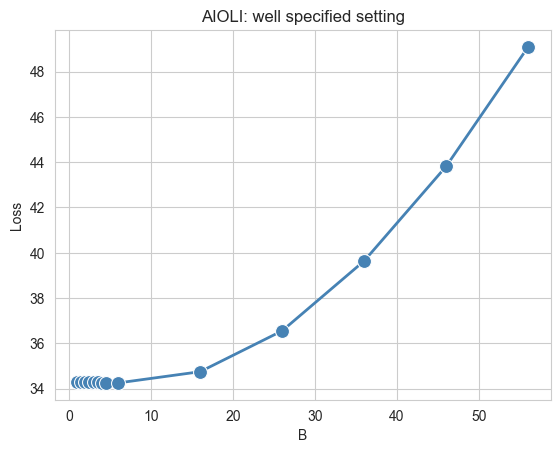

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011974529471481305


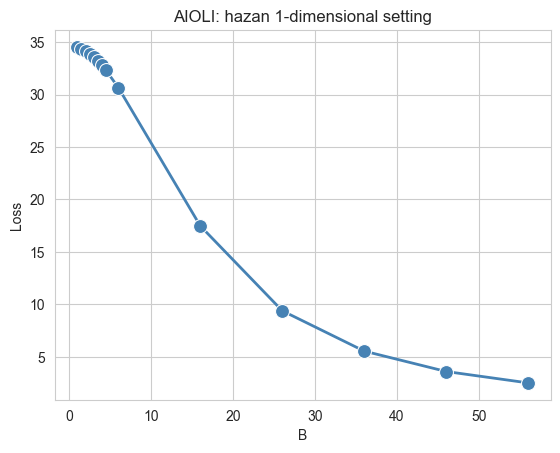

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.946


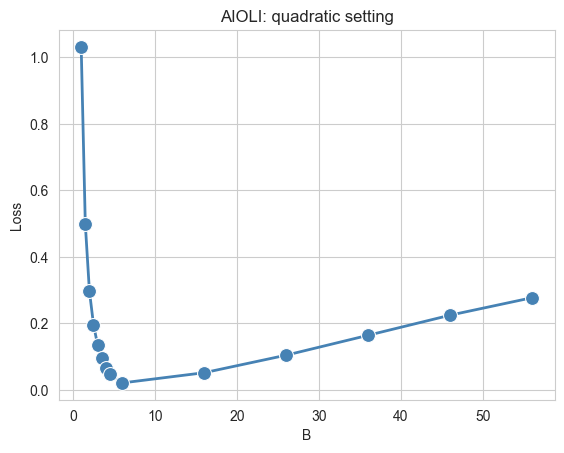

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.503


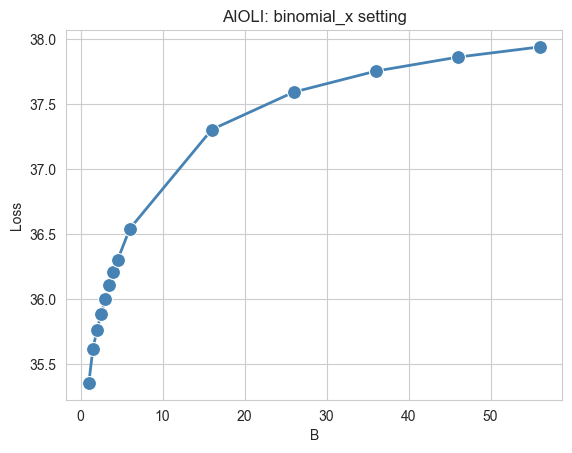

In [308]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "B", n = 100, x_means = alt_xmeans_balanced_1)

10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.489


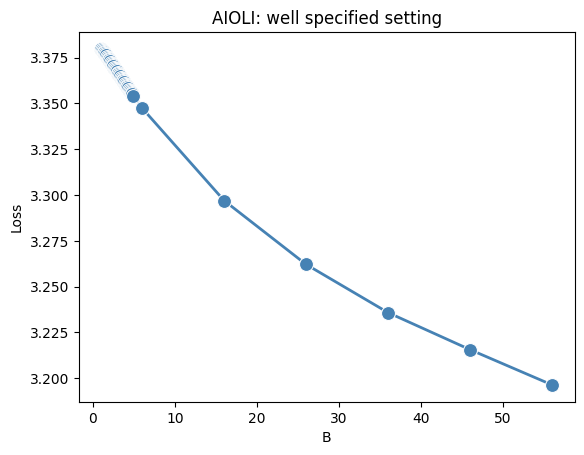

10 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.022156162384131307


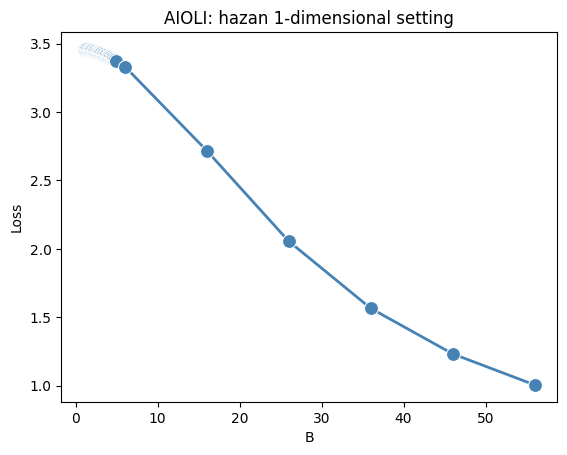

10 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


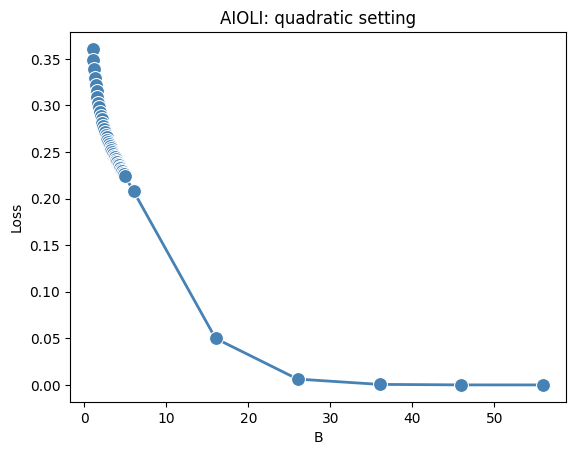

10 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.486


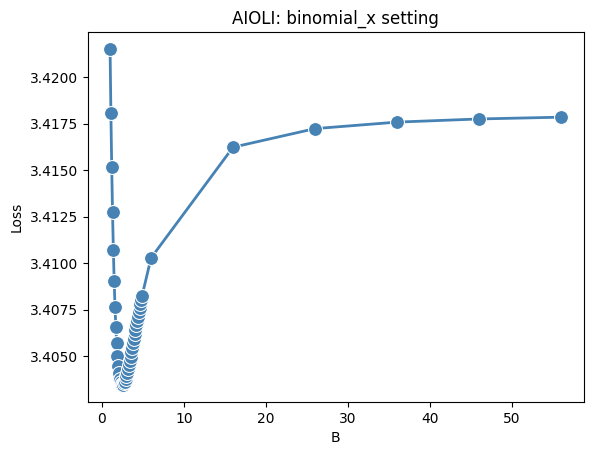

In [87]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "B", n = 100, x_means = alt_xmeans_balanced_2)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.701


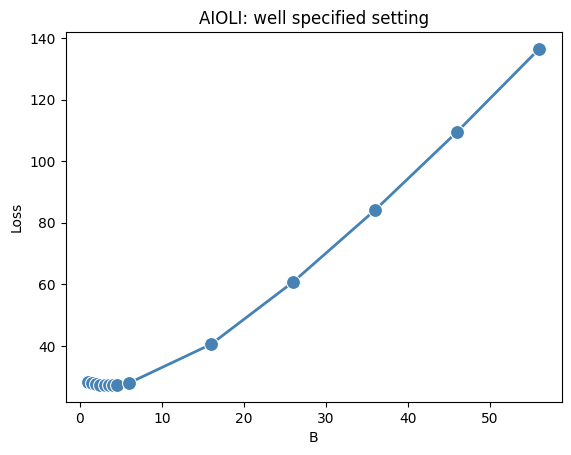

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.007983019647654204


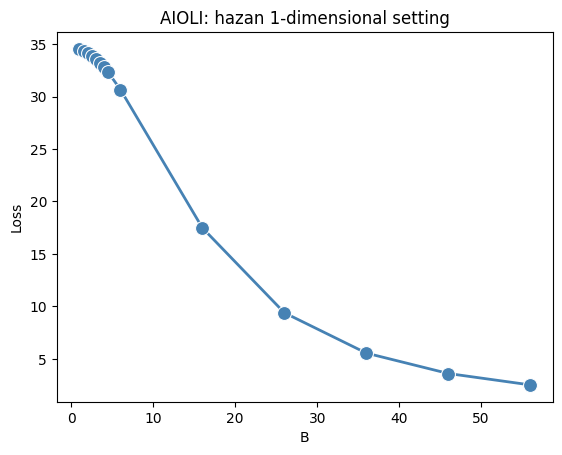

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.212


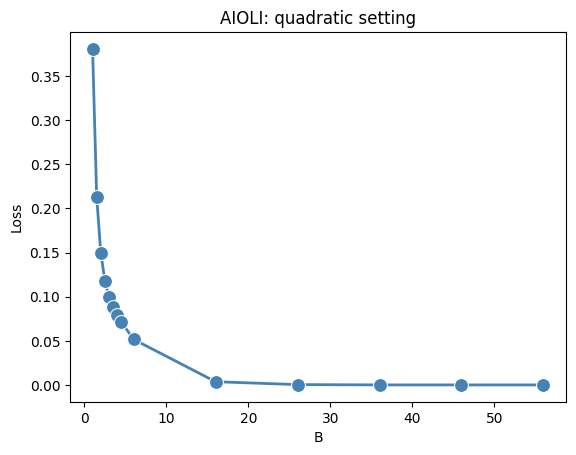

100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.996


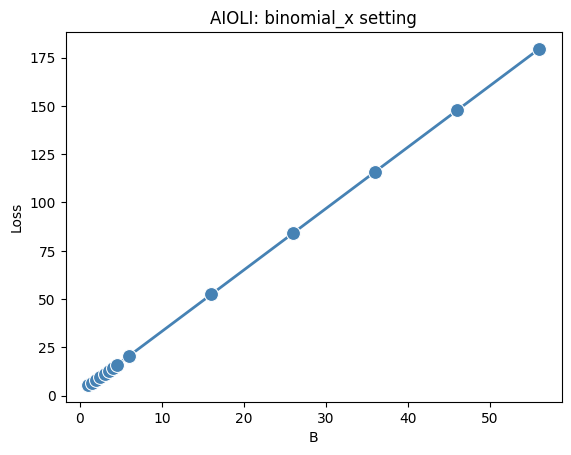

In [93]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "B", n = 100, x_means = alt_xmeans_unbalanced_1, balanced = False, X_hazan = -1)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


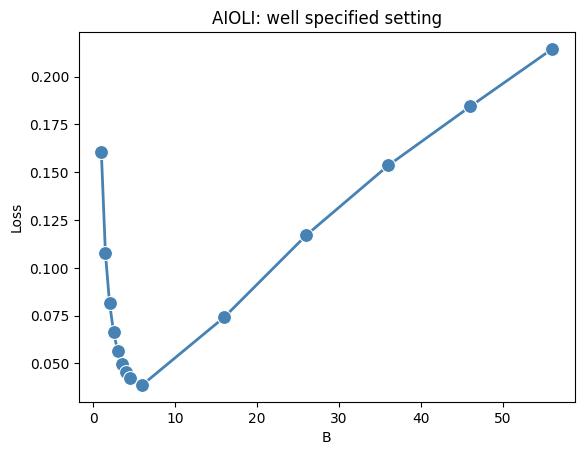

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.007983019647654204


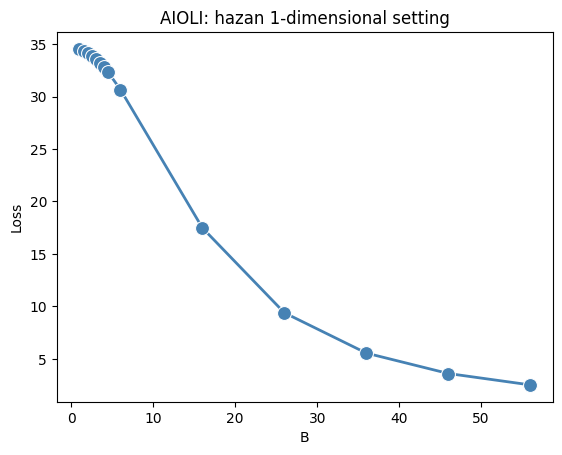

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 1.0


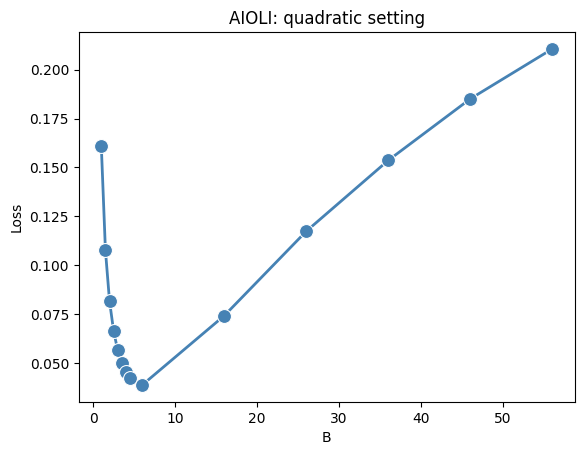

100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.996


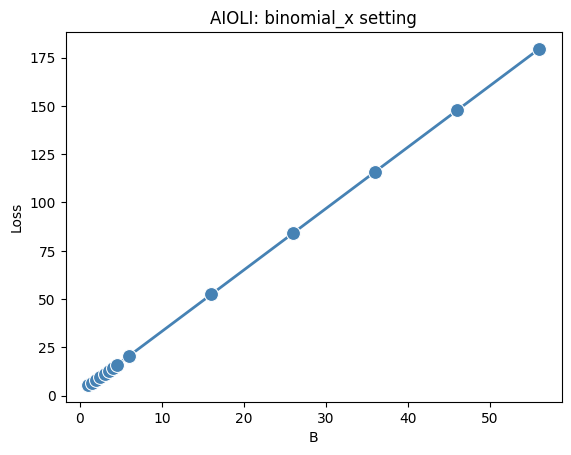

In [94]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "B", n = 100, x_means = alt_xmeans_unbalanced_2, balanced = False, X_hazan = -1)

### AIOLI "X"

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.501


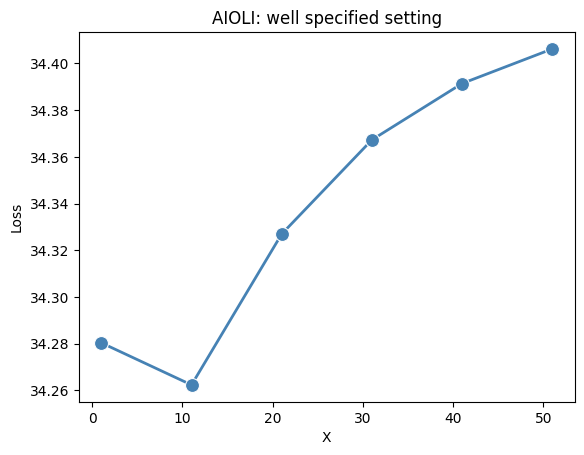

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011974529471481305


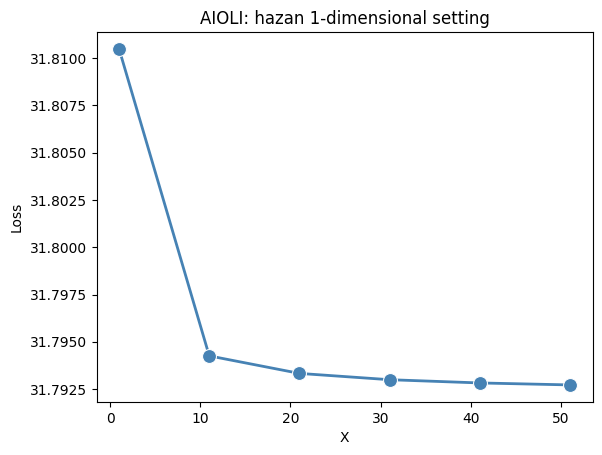

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.946


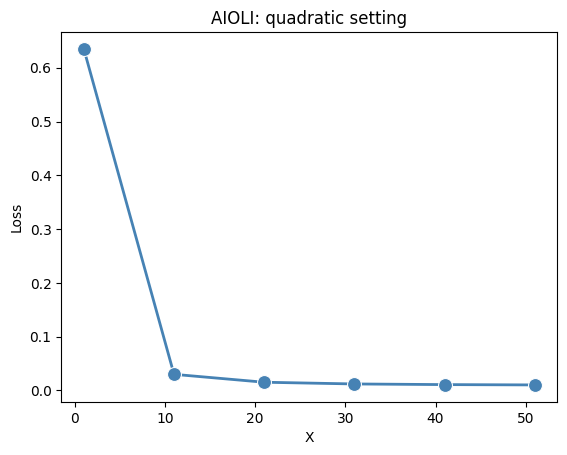

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.503


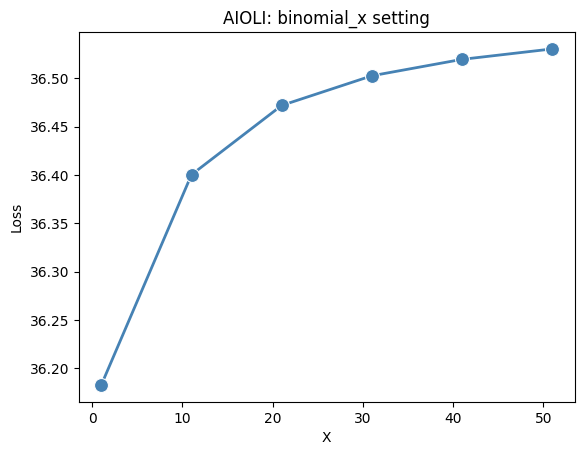

In [97]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "X", n = 100, x_means = alt_xmeans_balanced_1)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.498


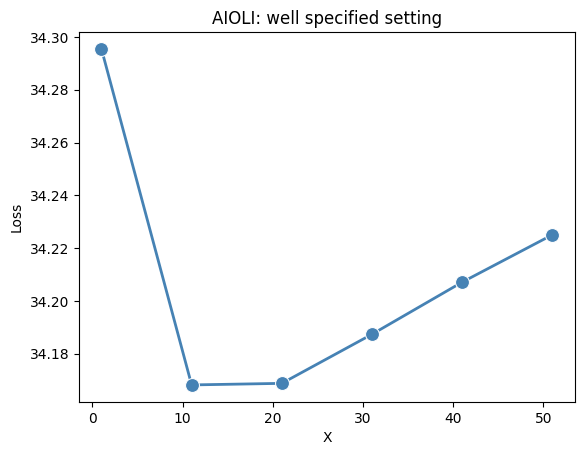

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011974529471481305


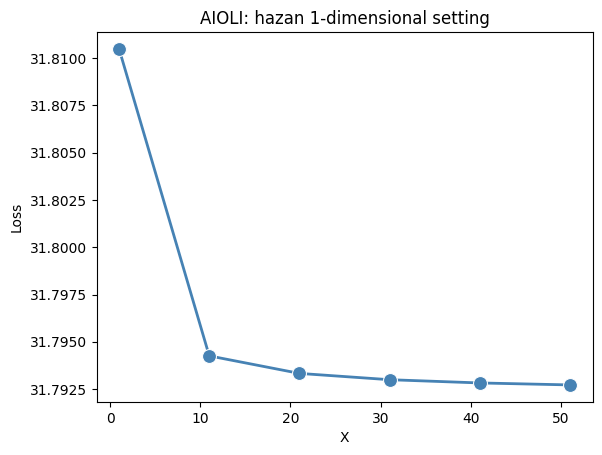

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


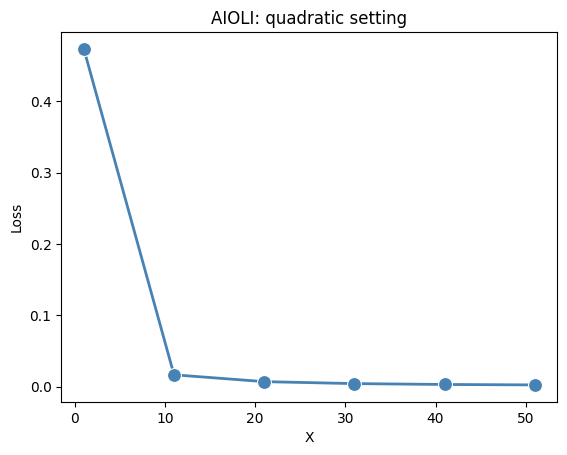

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.503


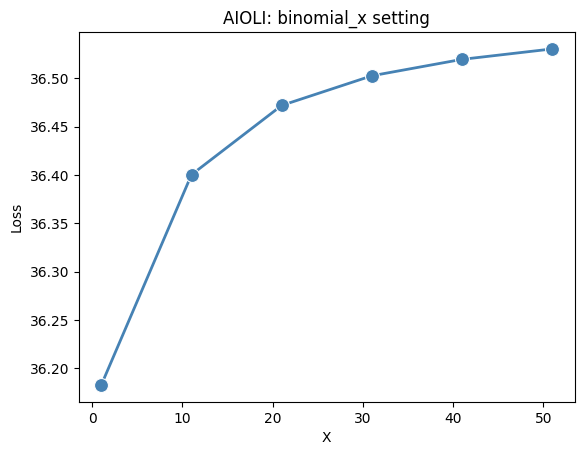

In [98]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "X", n = 100, x_means = alt_xmeans_balanced_2)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.701


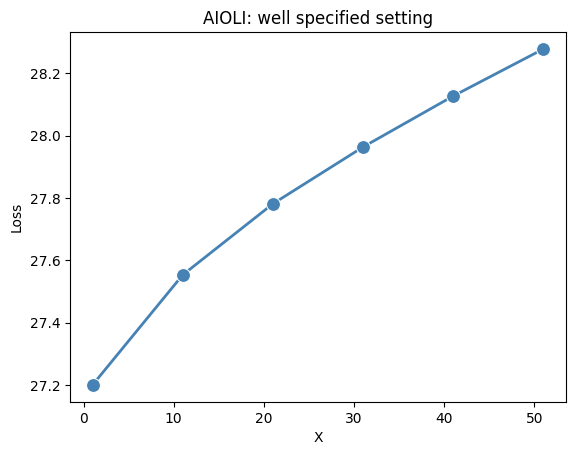

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.007983019647654204


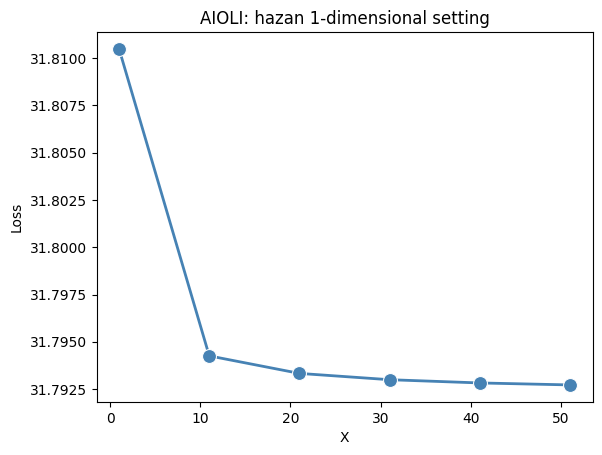

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.212


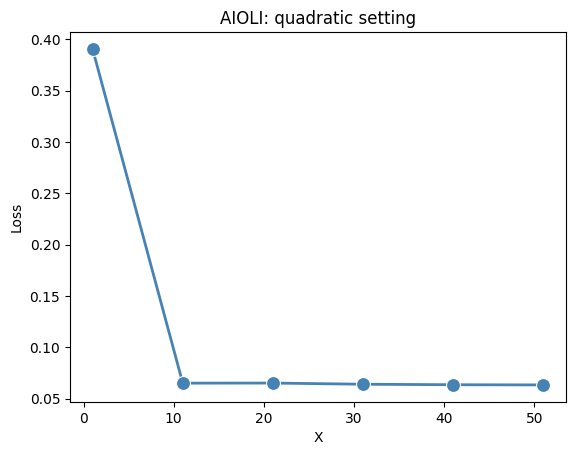

100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.996


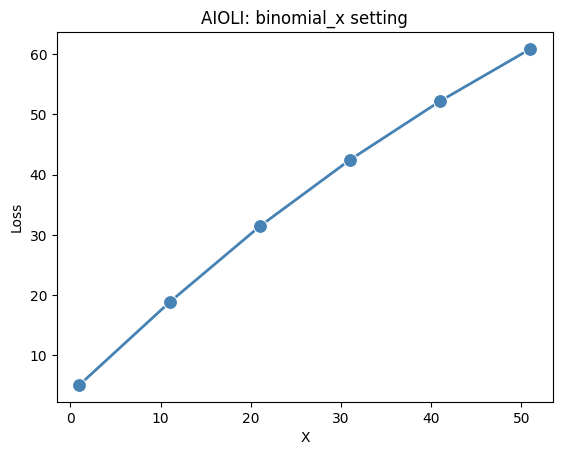

In [99]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "X", n = 100, x_means = alt_xmeans_unbalanced_1, balanced = False, X_hazan = -1)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


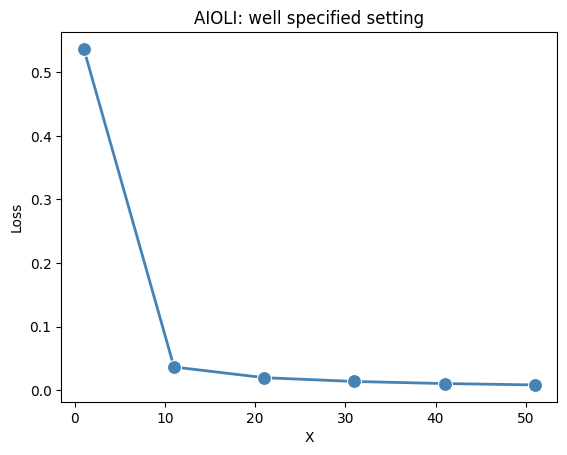

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.007983019647654204


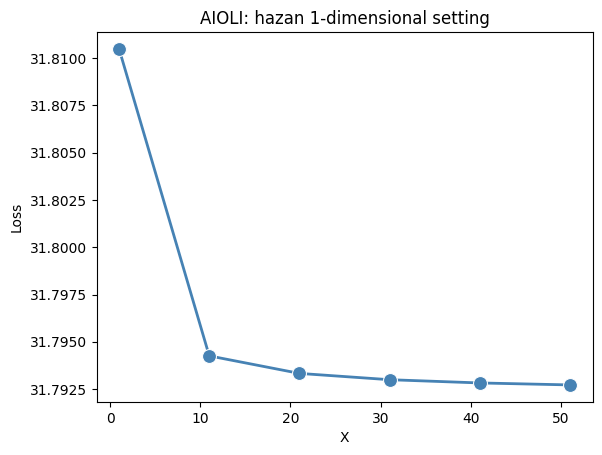

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 1.0


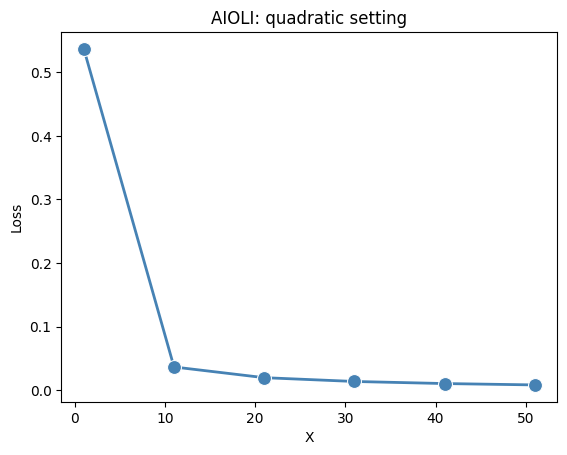

100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.996


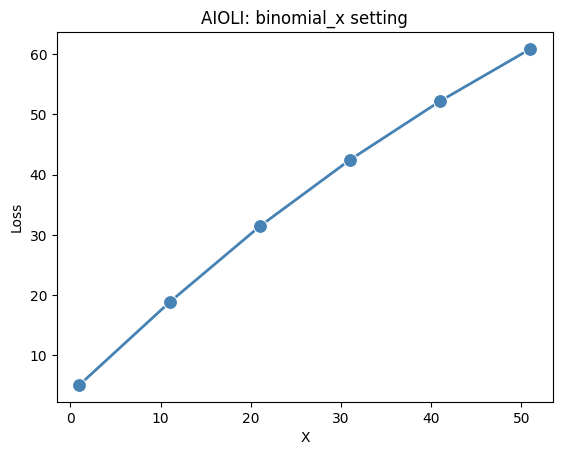

In [100]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "X", n = 100, x_means = alt_xmeans_unbalanced_2, balanced = False, X_hazan = -1)

### Ada Grad "B"

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.501


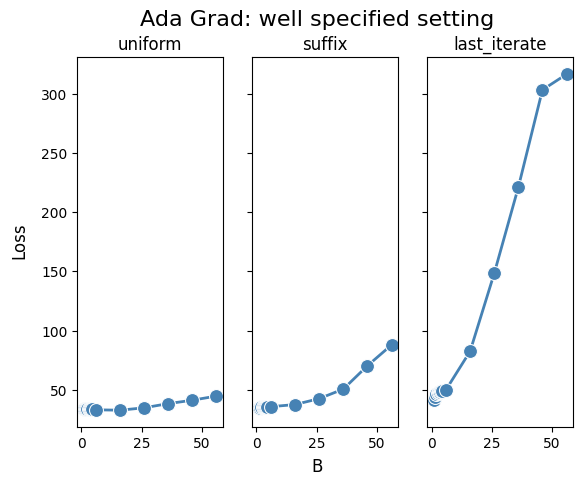

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011974529471481305


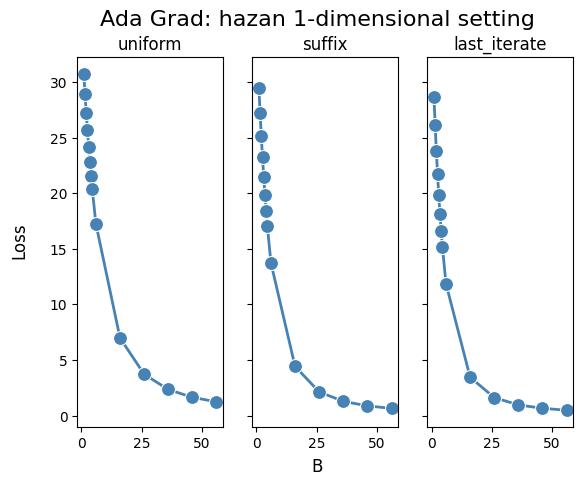

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.946


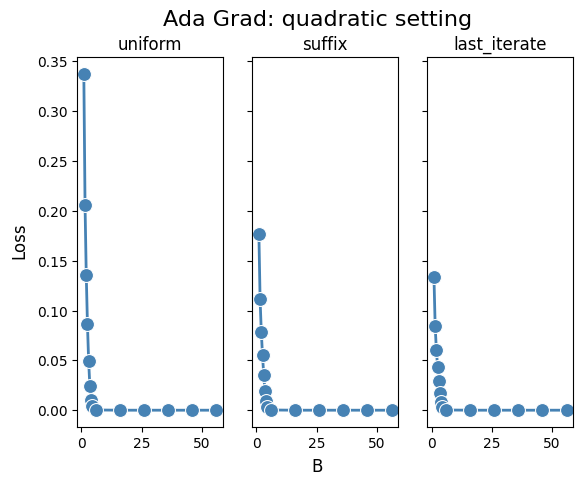

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.503


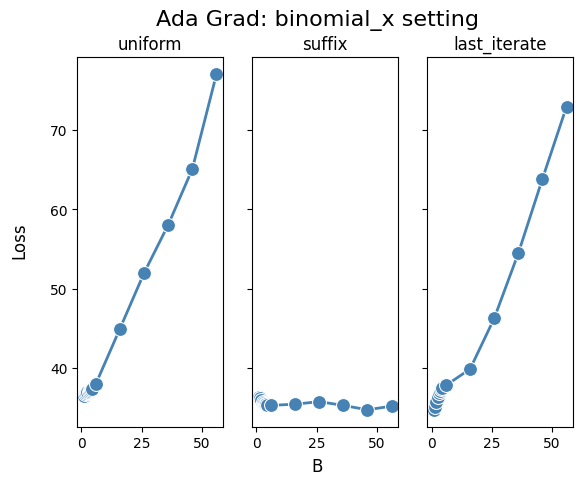

In [389]:
for setting in settings:
    hyperparameter_analysis(setting, "ADAGRAD", "B", n = 100,x_means = alt_xmeans_balanced_1)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.498


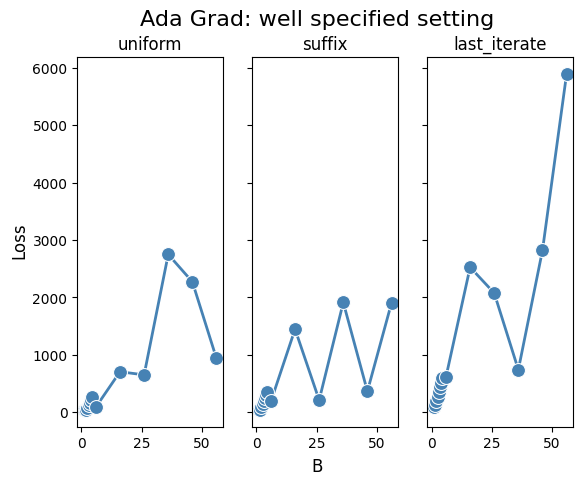

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011974529471481305


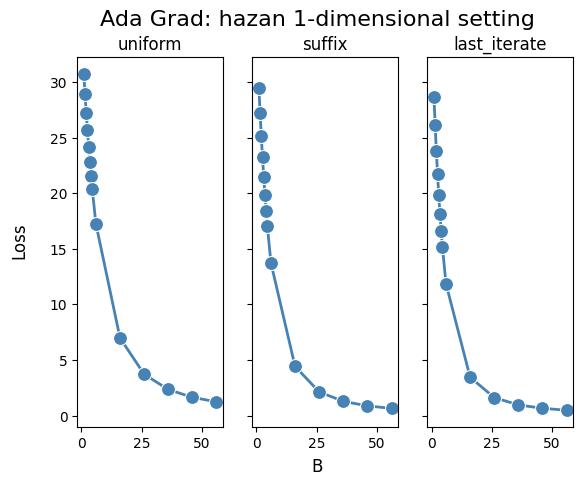

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


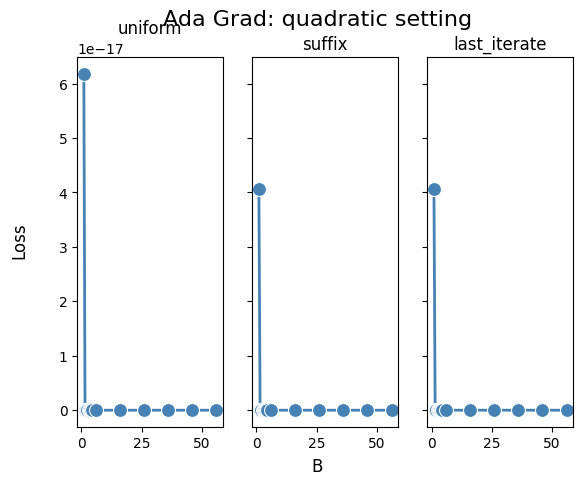

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.503


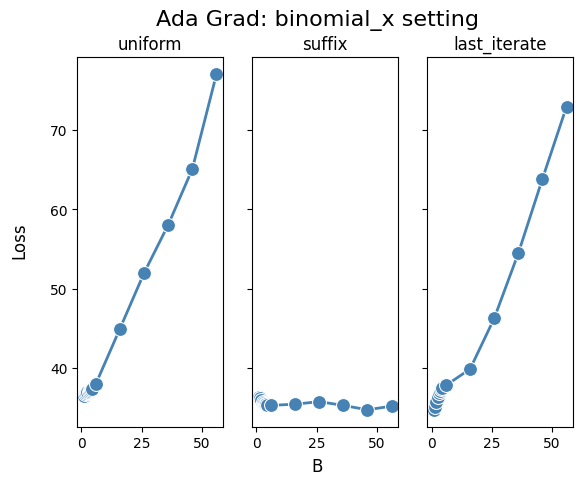

In [390]:
for setting in settings:
    hyperparameter_analysis(setting, "ADAGRAD", "B", n = 100,x_means = alt_xmeans_balanced_2)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.951


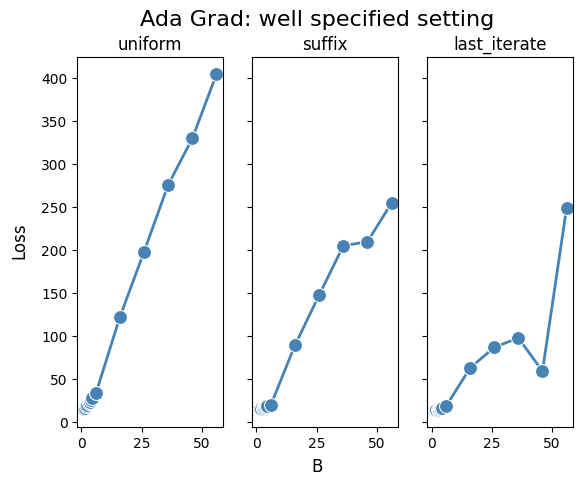

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.007983019647654204


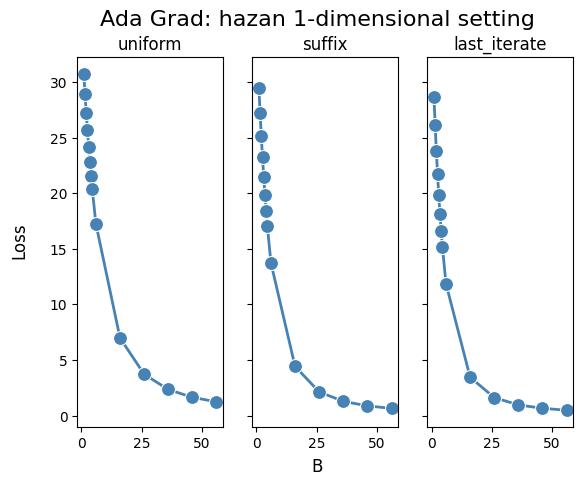

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


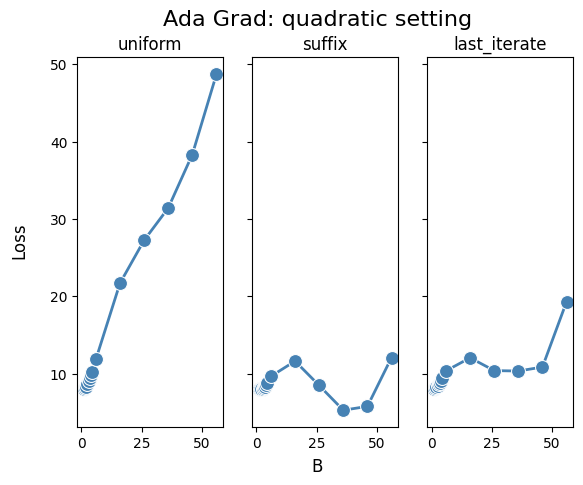

100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.996


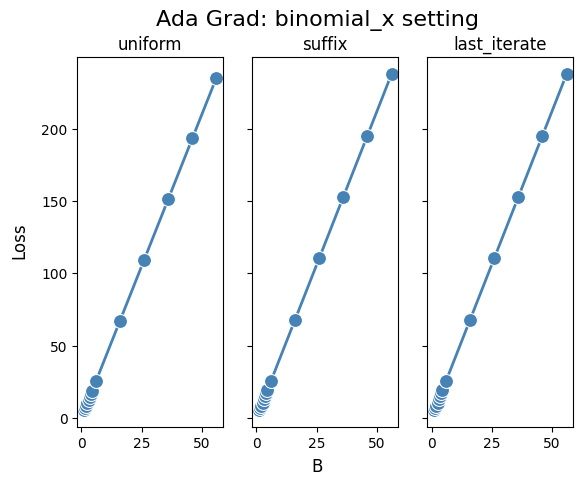

In [391]:
for setting in settings:
    hyperparameter_analysis(setting, "ADAGRAD", "B", n = 100,x_means = alt_xmeans_unbalanced_1, balanced = False, X_hazan = -1)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


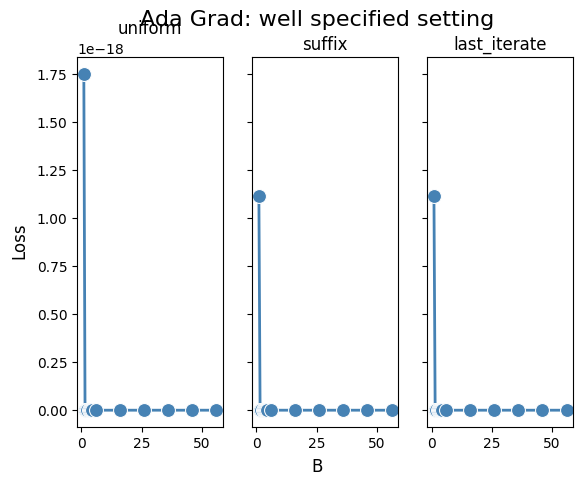

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.007983019647654204


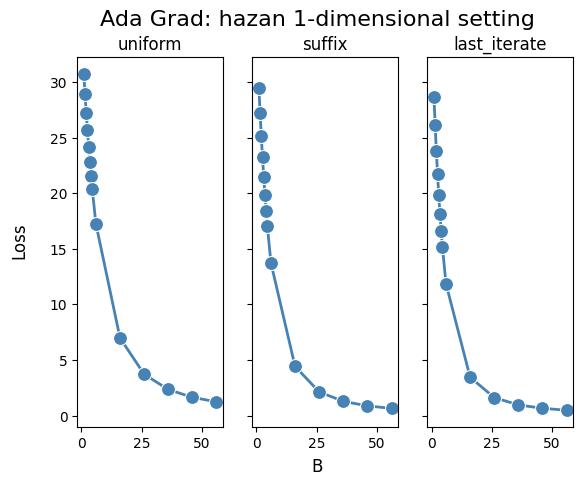

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.034


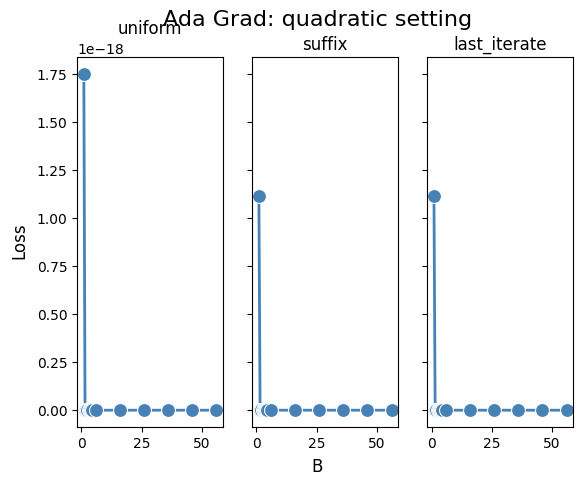

100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.996


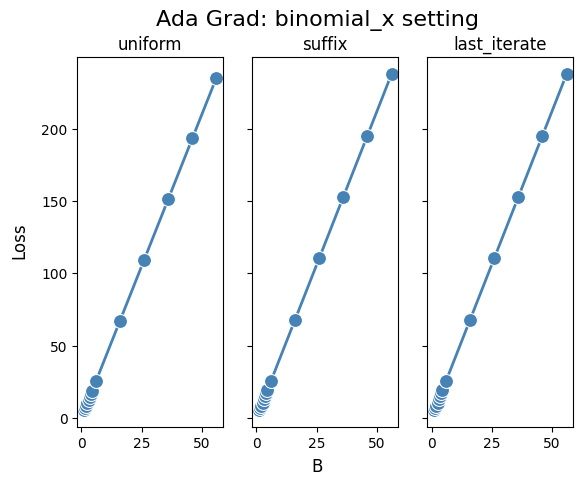

In [392]:
for setting in settings:
    hyperparameter_analysis(setting, "ADAGRAD", "B", n = 100,x_means = alt_xmeans_unbalanced_2, balanced = False, X_hazan = -1)

### SMOTE "S"

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.501


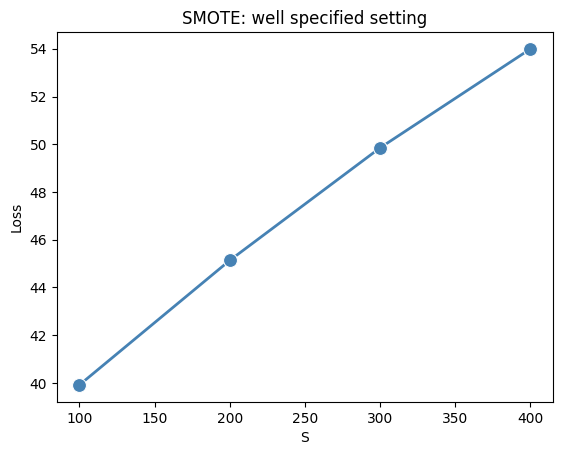

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011974529471481305
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually


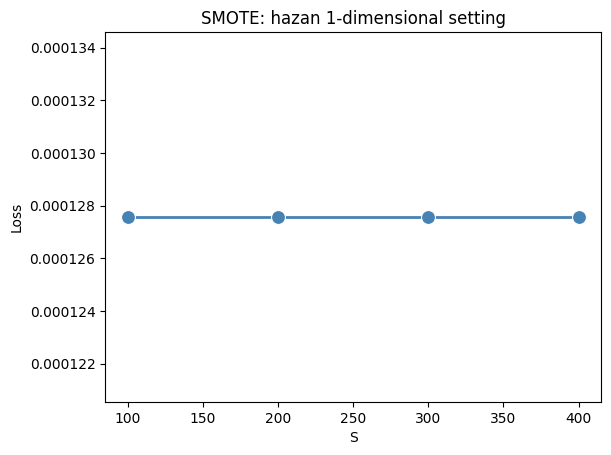

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.946
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually


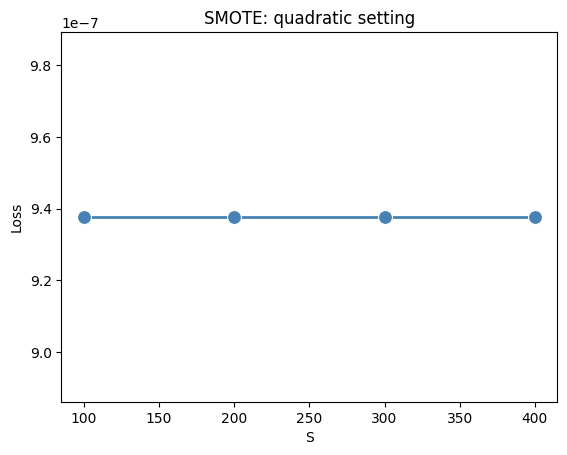

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.503


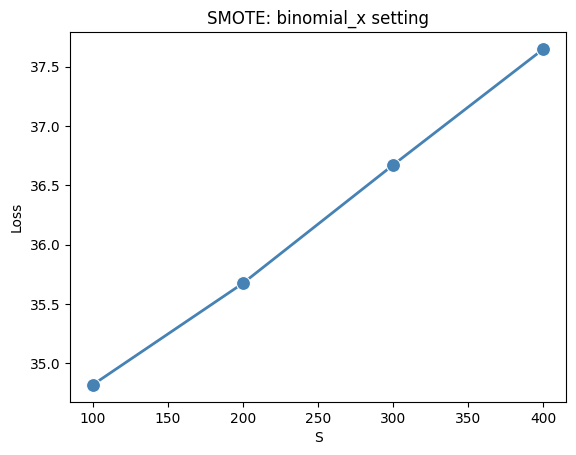

In [206]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "S", n = 100, x_means = alt_xmeans_balanced_1)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.498


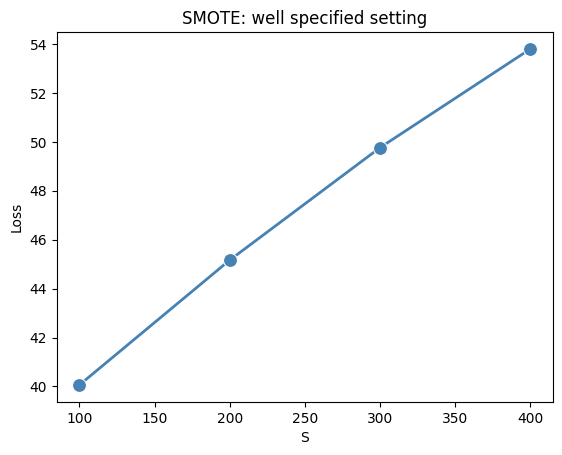

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011974529471481305
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually


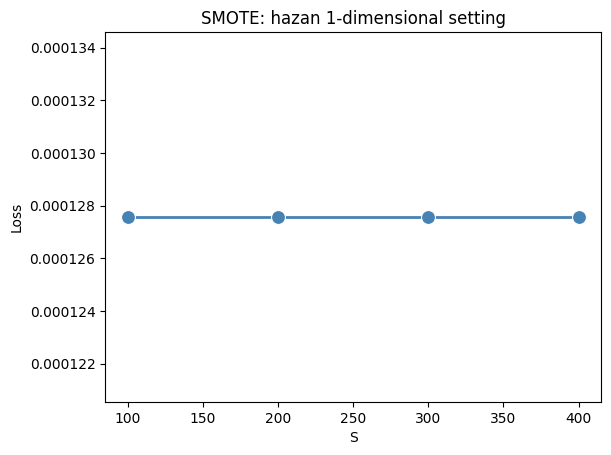

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually


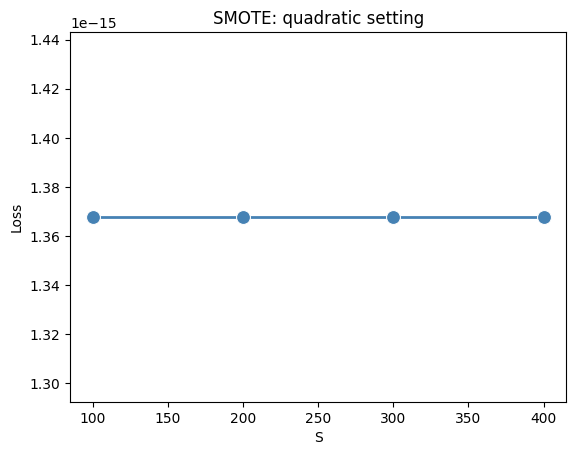

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.503


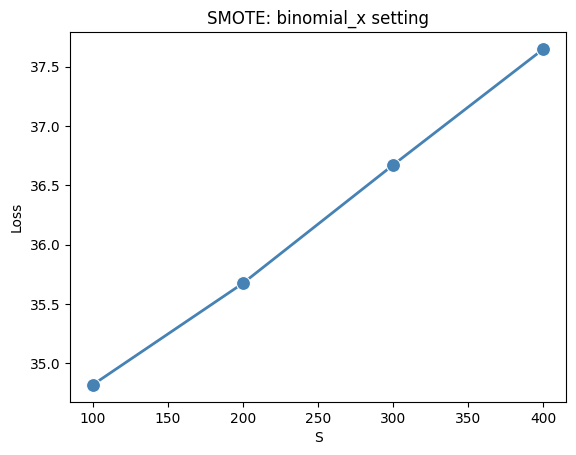

In [207]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "S", n = 100, x_means = alt_xmeans_balanced_2)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.015
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually


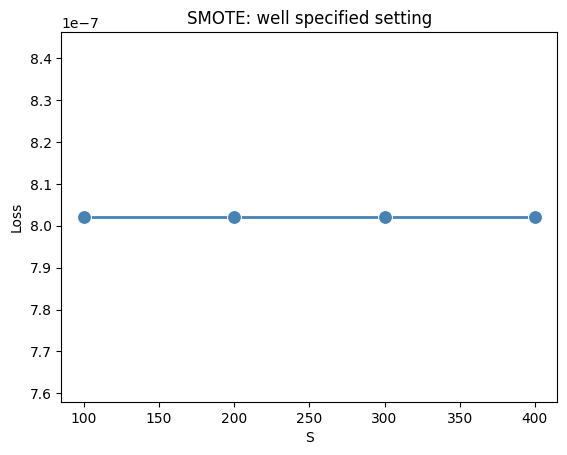

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011974529471481305
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually


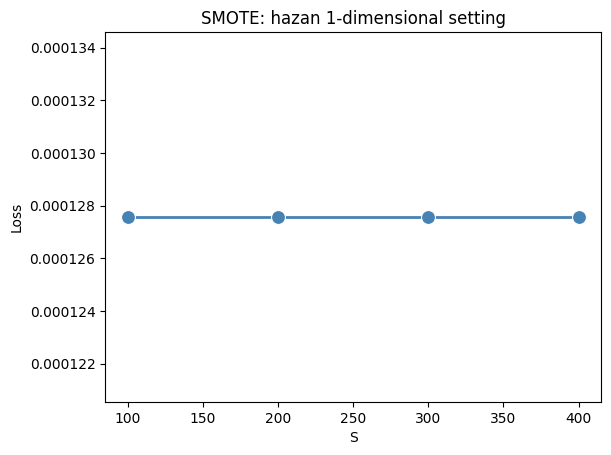

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.985
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually


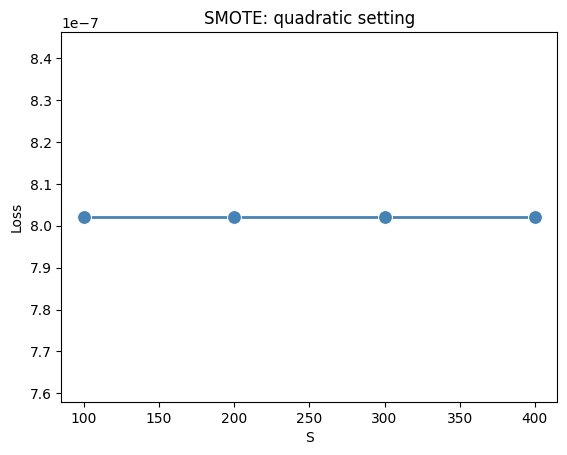

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.503


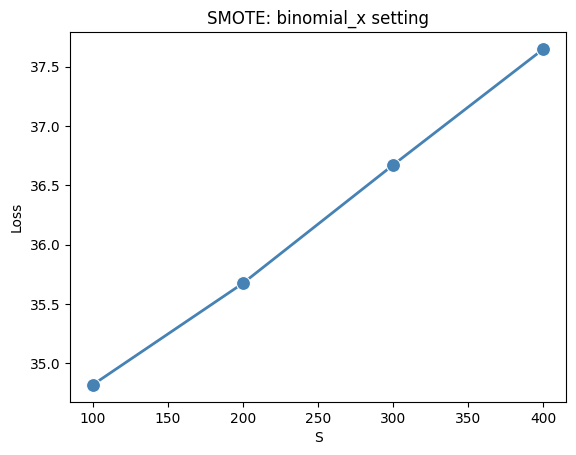

In [208]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "S", n = 100, x_means = alt_xmeans_unbalanced_1)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.012
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually


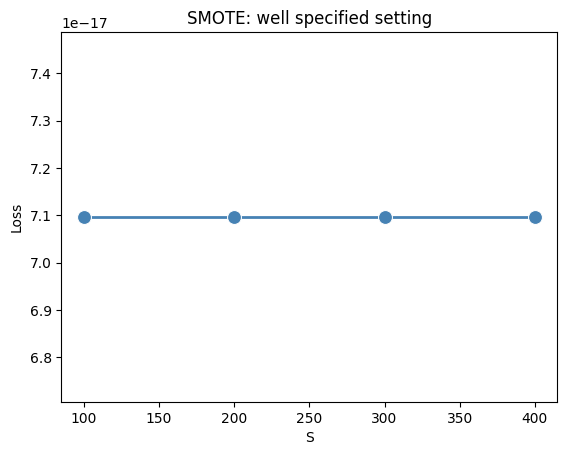

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011974529471481305
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually


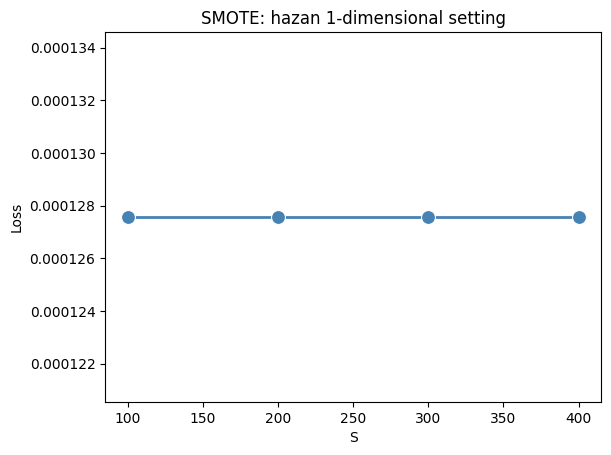

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually


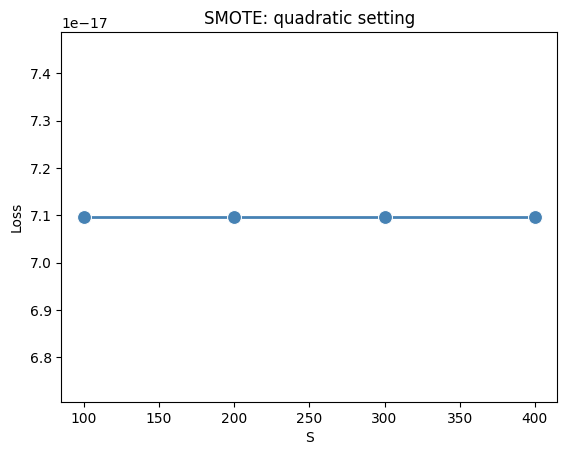

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.503


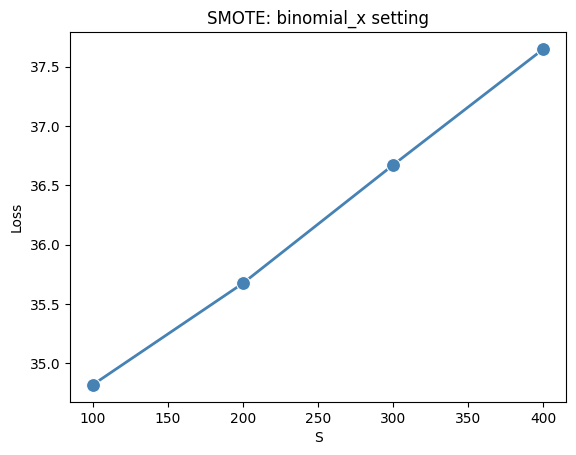

In [209]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "S", n = 100, x_means = alt_xmeans_unbalanced_2)

### SMOTE "k"

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.501


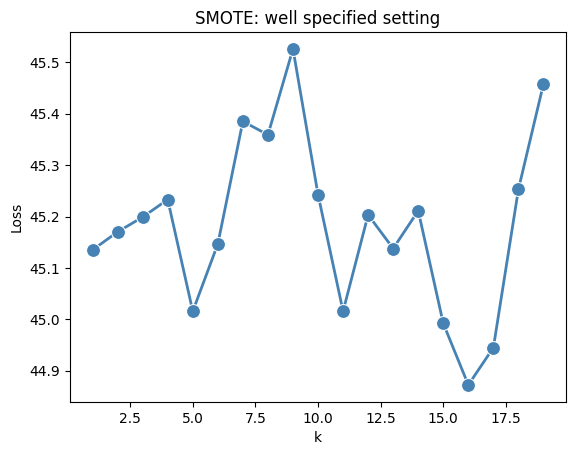

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011974529471481305
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has 

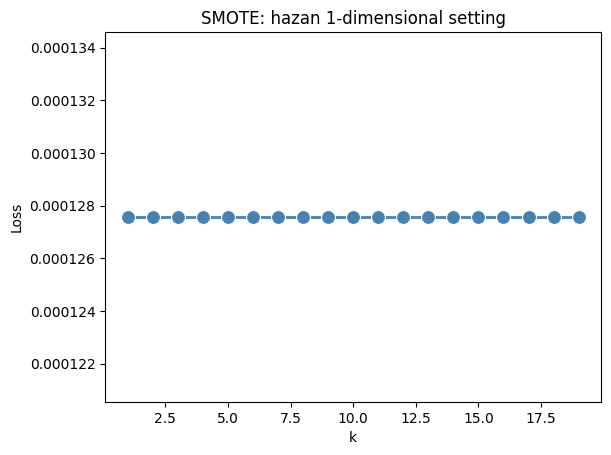

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.946
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regres

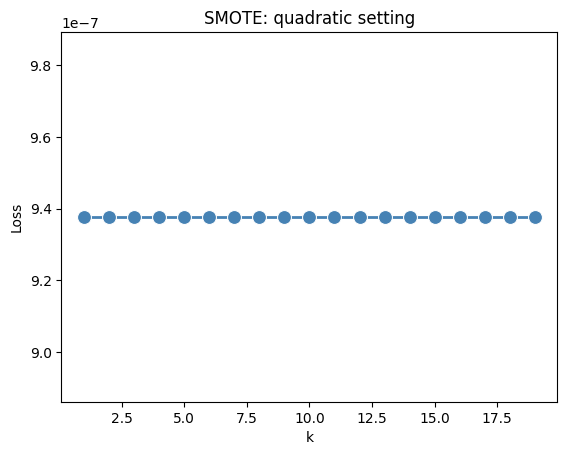

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.503


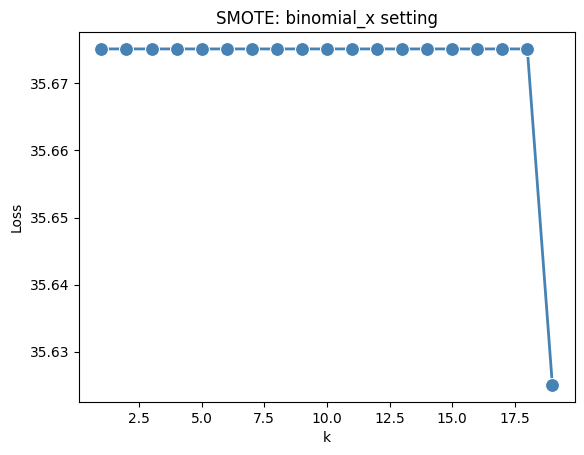

In [210]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "k", n = 100, x_means = alt_xmeans_balanced_1)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.498


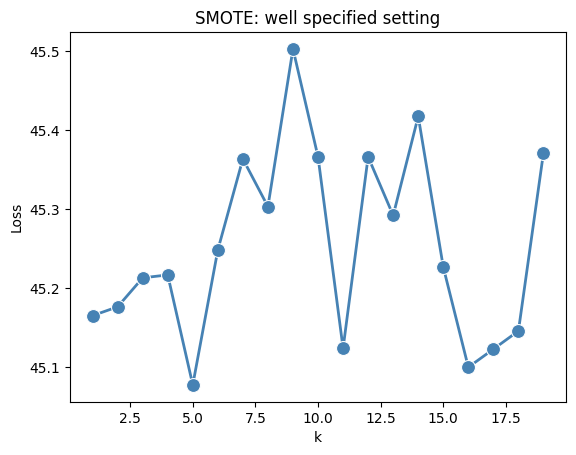

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011974529471481305
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has 

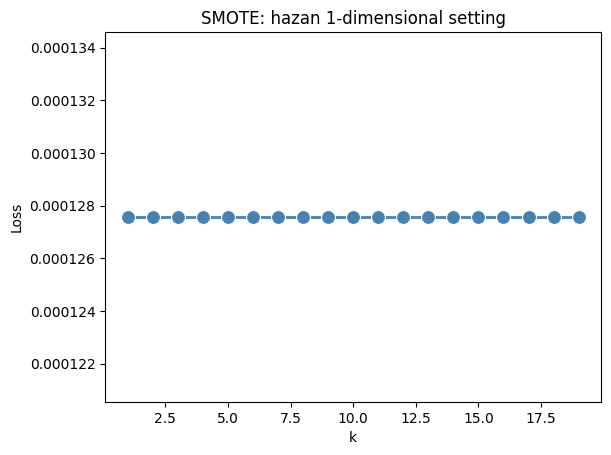

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regressi

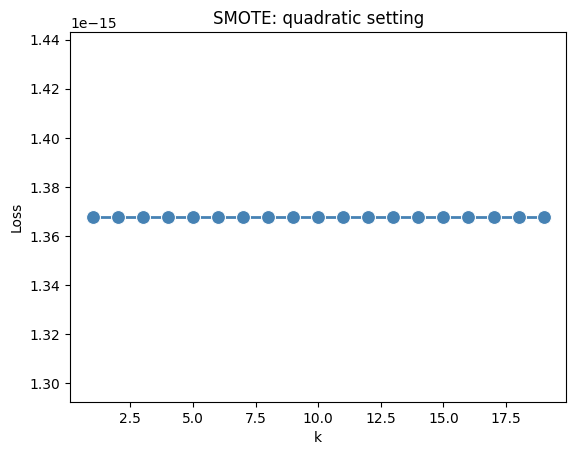

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.503


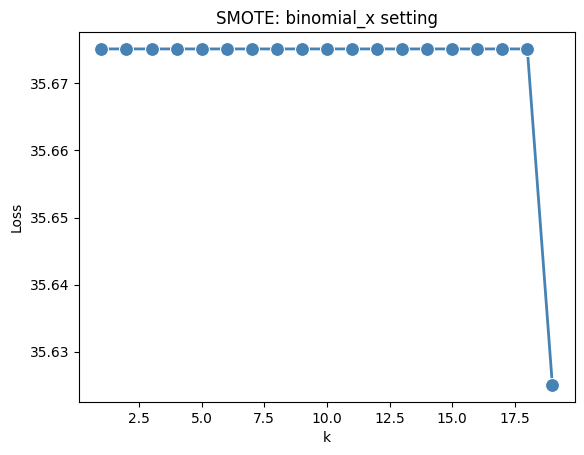

In [211]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "k", n = 100, x_means = alt_xmeans_balanced_2)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.015
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic r

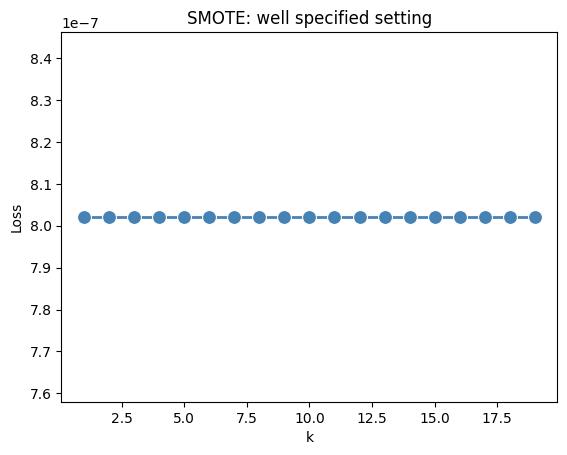

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011974529471481305
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has 

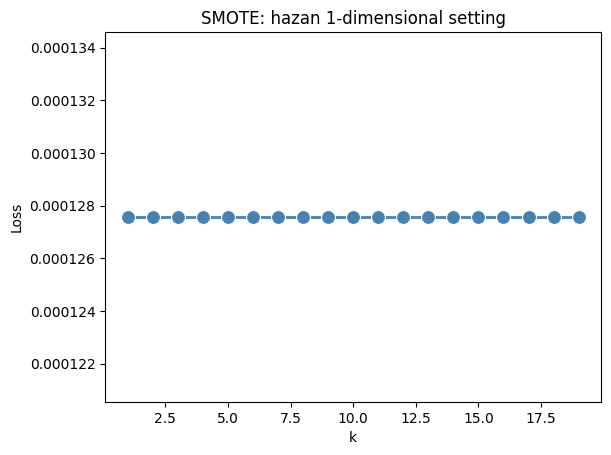

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.985
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regres

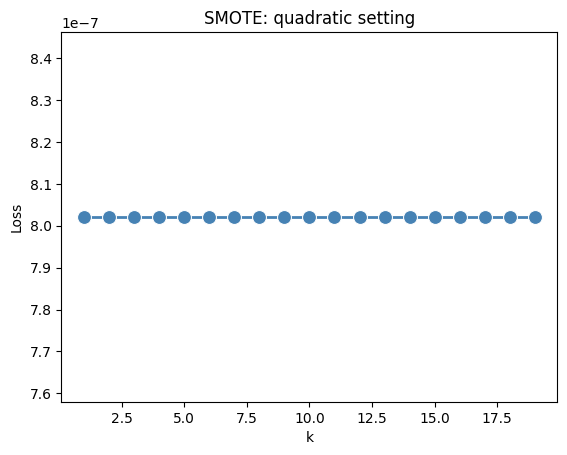

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.503


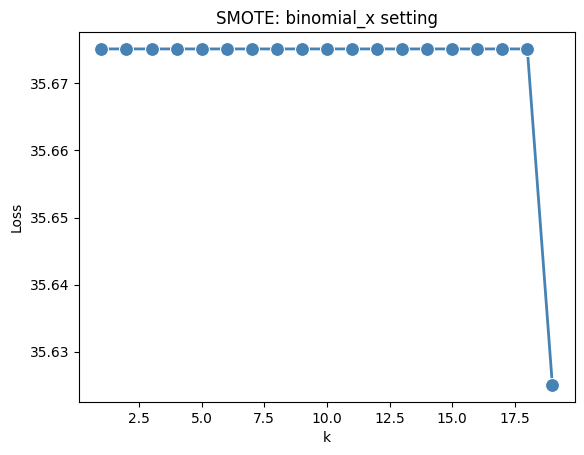

In [212]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "k", n = 100, x_means = alt_xmeans_unbalanced_1)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.012
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic r

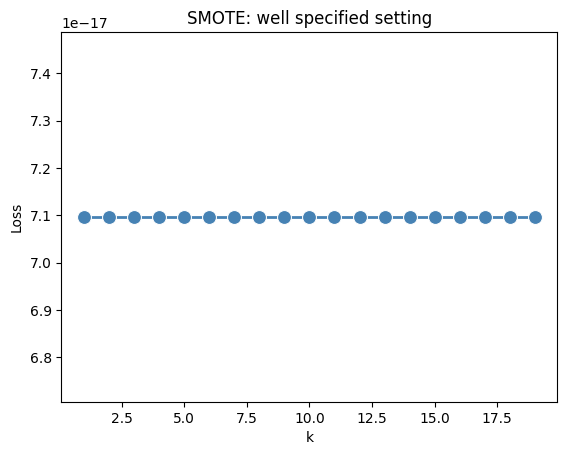

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011974529471481305
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has 

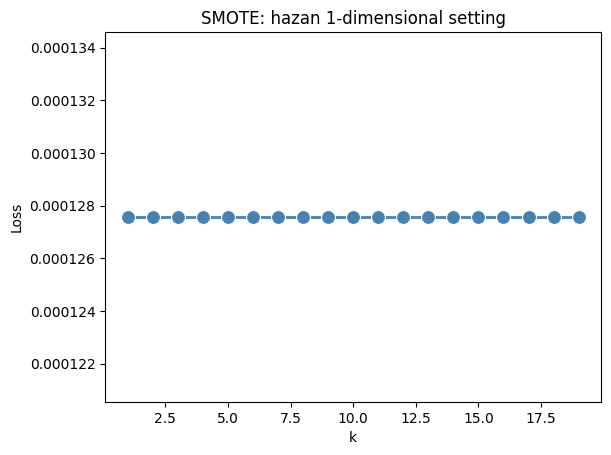

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regressi

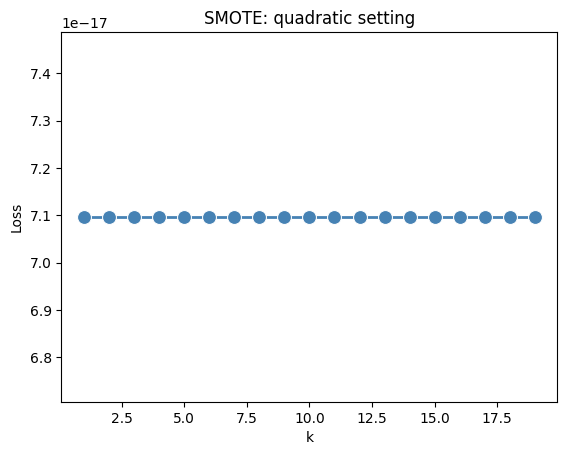

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.503


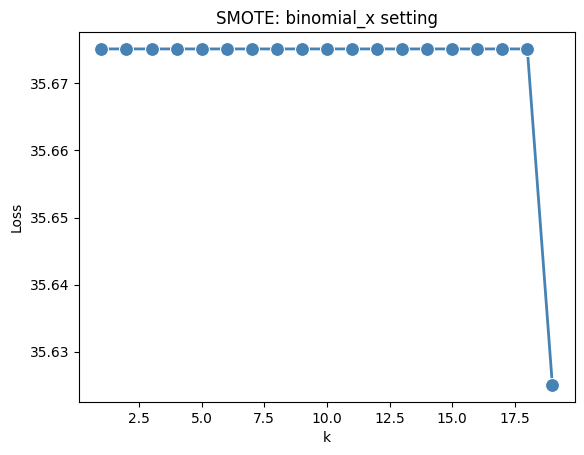

In [213]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "k", n = 100, x_means = alt_xmeans_unbalanced_2)

# Functions for simulations

## Data class for specifying simulation configuration

In [144]:
default_X = 1
default_B_Adagrad = 1.5
@dataclass
class SimulationConfig:
    sim_betas: list =  None,
    # Default is well specified
    sim_setting: str =  "well specified"
    sim_balanced: bool = True
    runs: int = default_runs
    n: int = default_n
    d: int = 3
    data_seed: int = 40
    # betas: list = field(default_factory=lambda: [2,0.1,-4.2]) # This is to create a new list every time.
    # x_means: list = field(default_factory=lambda: [2,2,1])
    # These values of betas and x_means guarantee a P(Y=1) = 0.5, hence balanced classes.
    test_ratio: float = default_test_ratio
    minimize_method: str = "l-bfgs-b"
    y_method: str = "sigmoid"
    X_hazan: int = 1

## Function to run simulations and get results

In [367]:
def run_simulation(cfg: SimulationConfig = None, B_hazan = None):
    runs = cfg.runs
    n = cfg.n
    d = cfg.d
    minimize_method = cfg.minimize_method
    data_seed = cfg.data_seed
    sim_setting = cfg.sim_setting
    sim_balanced = cfg.sim_balanced
    X_hazan = cfg.X_hazan
    sim_betas = cfg.sim_betas

    test_set_results = []
    time_results = []
    y_counts = []
    start_time = datetime.datetime.now()

    all_y_trains = {}
    all_y_tests = {}

    for i in range(runs):
        x_train, y_train, x_test, y_test = generate_data(setting = sim_setting,
                                                             balanced = sim_balanced,
                                                             n = n,
                                                             seed = data_seed + i,
                                                             d = d,
                                                             X_hazan = X_hazan,
                                                             betas = sim_betas,
                                                            B_hazan = B_hazan)

        y_counts.append({
            "count_1": int(np.sum(y_train == 1)),
            "count_minus1": int(np.sum(y_train == -1))
        })

        all_y_trains[f"run_{i+1}"] = y_train.copy()
        all_y_tests[f"run_{i+1}"] = y_test.copy()

        sm = SMOTE(data_x = x_train, data_y = y_train, S = 100)
        smote_x, smote_y = sm.apply_smote()

        def time_it(fn):
            """Runs fn(), returns (result, elapsed_seconds)."""
            t0 = datetime.datetime.now()
            result = fn()
            return result, (datetime.datetime.now() - t0).total_seconds()

        # ── Fit ──────────────────────────────────────────────────────────────
        ogd,           t_ogd_fit        = time_it(lambda: online_gd(data_y=y_train, data_x=x_train))
        adagrad,       t_adagrad_fit    = time_it(lambda: online_AdaGrad(data_y=y_train, data_x=x_train, B_vector=np.repeat(default_B_Adagrad, d)))
        aioli_model                     = AIOLI()
        ai,            t_aioli_fit      = time_it(lambda: aioli_model.fit(data_y=y_train, data_x=x_train, X=default_X, B=np.log(n), minimize_method=minimize_method))
        classic_LR,    t_clr_fit        = time_it(lambda: classic_logistic_regression(data_x=x_train, data_y=y_train))
        ridge_LR,      t_ridge_fit      = time_it(lambda: ridge_logistic_regression(data_x=x_train, data_y=y_train))
        lasso_LR,      t_lasso_fit      = time_it(lambda: lasso_logistic_regression(data_x=x_train, data_y=y_train))
        smp,           t_smp_fit        = time_it(lambda: sample_minmax_predictor(x_train, y_train))
        ridge_smp,     t_ridge_smp_fit  = time_it(lambda: ridge_sample_minmax_predictor(x_train, y_train))
        classic_LR_smote, t_smote_fit   = time_it(lambda: classic_logistic_regression(data_x=smote_x, data_y=smote_y))

        # ── OTB averaging (counts toward OGD / AdaGrad time) ─────────────────
        OGD_OTB_uniform, t_ogd_u   = time_it(lambda: calculate_OTB(ogd["All_Betas"], "uniform"))
        OGD_OTB_Suffix,  t_ogd_s   = time_it(lambda: calculate_OTB(ogd["All_Betas"], "suffix_averaging"))
        OGD_OTB_lastit,  t_ogd_l   = time_it(lambda: calculate_OTB(ogd["All_Betas"], "last_iterate"))

        adagrad_OTB_uniform, t_ada_u = time_it(lambda: calculate_OTB(adagrad["All_Betas"], "uniform"))
        adagrad_OTB_Suffix,  t_ada_s = time_it(lambda: calculate_OTB(adagrad["All_Betas"], "suffix_averaging"))
        adagrad_OTB_lastit,  t_ada_l = time_it(lambda: calculate_OTB(adagrad["All_Betas"], "last_iterate"))

        # ── Loss on test set ──────────────────────────────────────────────────
        loss_OGD_uniform_test,  t_ogd_u_loss  = time_it(lambda: log_loss(OGD_OTB_uniform, x_test, y_test))
        loss_OGD_Suffix_test,   t_ogd_s_loss  = time_it(lambda: log_loss(OGD_OTB_Suffix,  x_test, y_test))
        loss_OGD_lastit_test,   t_ogd_l_loss  = time_it(lambda: log_loss(OGD_OTB_lastit,  x_test, y_test))

        loss_adagrad_uniform_test, t_ada_u_loss = time_it(lambda: log_loss(adagrad_OTB_uniform, x_test, y_test))
        loss_adagrad_Suffix_test,  t_ada_s_loss = time_it(lambda: log_loss(adagrad_OTB_Suffix,  x_test, y_test))
        loss_adagrad_lastit_test,  t_ada_l_loss = time_it(lambda: log_loss(adagrad_OTB_lastit,  x_test, y_test))

        loss_AIOLI_uniform_test, t_aioli_u_loss = time_it(lambda: aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"])
        loss_AIOLI_Suffix_test,  t_aioli_s_loss = time_it(lambda: aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="suffix_averaging")["loss"])
        loss_AIOLI_lastit_test,  t_aioli_l_loss = time_it(lambda: aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="last_iterate")["loss"])

        loss_LR_test,       t_clr_loss       = time_it(lambda: log_loss(classic_LR["Batch_estimate"],       x_test, y_test))
        loss_LR_smote_test, t_smote_loss     = time_it(lambda: log_loss(classic_LR_smote["Batch_estimate"], x_test, y_test))
        loss_LR_Ridge_test, t_ridge_loss     = time_it(lambda: log_loss(ridge_LR["Batch_estimate"],         x_test, y_test))
        loss_LR_Lasso_test, t_lasso_loss     = time_it(lambda: log_loss(lasso_LR["Batch_estimate"],         x_test, y_test))

        smp_result,       t_smp_loss      = time_it(lambda: smp.get_new_loss(x_test, y_test))
        ridge_smp_result, t_ridge_smp_loss = time_it(lambda: ridge_smp.get_new_loss(x_test, y_test))

        # ── Collate results ───────────────────────────────────────────────────
        algorithms_test = {
            "Classical_LR":         {"loss": loss_LR_test,              "time_fit": t_clr_fit,       "time_loss": t_clr_loss},
            "Classical_LR_SMOTE":   {"loss": loss_LR_smote_test,        "time_fit": t_smote_fit,     "time_loss": t_smote_loss},
            "Ridge_LR":             {"loss": loss_LR_Ridge_test,         "time_fit": t_ridge_fit,     "time_loss": t_ridge_loss},
            "Lasso_LR":             {"loss": loss_LR_Lasso_test,         "time_fit": t_lasso_fit,     "time_loss": t_lasso_loss},
            "OGD_uniform":          {"loss": loss_OGD_uniform_test,      "time_fit": t_ogd_fit,       "time_loss": t_ogd_u + t_ogd_u_loss},
            "OGD_Suffix":           {"loss": loss_OGD_Suffix_test,       "time_fit": t_ogd_fit,       "time_loss": t_ogd_s + t_ogd_s_loss},
            "OGD_Last_iterate":     {"loss": loss_OGD_lastit_test,       "time_fit": t_ogd_fit,       "time_loss": t_ogd_l + t_ogd_l_loss},
            "AdaGrad_uniform":      {"loss": loss_adagrad_uniform_test,  "time_fit": t_adagrad_fit,   "time_loss": t_ada_u + t_ada_u_loss},
            "AdaGrad_Suffix":       {"loss": loss_adagrad_Suffix_test,   "time_fit": t_adagrad_fit,   "time_loss": t_ada_s + t_ada_s_loss},
            "AdaGrad_Last_iterate": {"loss": loss_adagrad_lastit_test,   "time_fit": t_adagrad_fit,   "time_loss": t_ada_l + t_ada_l_loss},
            "AIOLI_uniform":        {"loss": loss_AIOLI_uniform_test,    "time_fit": t_aioli_fit,     "time_loss": t_aioli_u_loss},
            "AIOLI_Suffix":         {"loss": loss_AIOLI_Suffix_test,     "time_fit": t_aioli_fit,     "time_loss": t_aioli_s_loss},
            "AIOLI_lastit":         {"loss": loss_AIOLI_lastit_test,     "time_fit": t_aioli_fit,     "time_loss": t_aioli_l_loss},
            "SMP":                  {"loss": smp_result["loss"],         "time_fit": t_smp_fit,       "time_loss": t_smp_loss},
            "Ridge_SMP":            {"loss": ridge_smp_result["loss"],   "time_fit": t_ridge_smp_fit, "time_loss": t_ridge_smp_loss},
        }

        for name, metrics in algorithms_test.items():
            row = {"run": i + 1, "algorithm": name, **metrics}
            row["time_total"] = row["time_fit"] + row["time_loss"]
            test_set_results.append(row)

        print(f"Run {i+1} finished")

    endtime = datetime.datetime.now()
    total_time = (endtime - start_time).total_seconds()

    results_df = pd.DataFrame(test_set_results)

    return {
        "test_results":    results_df[["run", "algorithm", "loss"]],
        "time_results":    results_df[["run", "algorithm", "time_fit", "time_loss", "time_total"]],
        "y_counts_train":  pd.DataFrame(y_counts),
        "y_train_df":      pd.DataFrame(all_y_trains),
        "y_test_df":       pd.DataFrame(all_y_tests),
        "total_time":      total_time,
    }

## Simulations changing n

In [366]:
def simulations_changing_n(n_values: list, base_config: SimulationConfig, filename, B_hazan = None) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Run simulations for multiple sample sizes and aggregate results.

    Args:
        n_values: List of sample sizes to simulate
        base_config: Base SimulationConfig object (will copy and modify n for each run)

    Returns:
        summary_df: DataFrame with columns: n, algorithm, avg_loss, std_loss, num_runs
        raw_df: DataFrame with columns: n, algorithm, loss (one row per run)
    """
    all_summaries = []
    all_raw = []
    total_time = 0

    for n in n_values:
        print(f"="*50)
        print(f"Running simulations for n = {n}\n")
        print(f"="*50)
        # Create a copy of the config with the new n value
        config = base_config
        config.n = n  # Modify n in place

        # Run the simulation
        results_dict = run_simulation(config, B_hazan = B_hazan)

        # Extract test results
        test_results_df = results_dict["test_results"]
        total_time += results_dict["total_time"]

        # Add n column to raw data
        raw_with_n = test_results_df.copy()
        raw_with_n['n'] = n
        all_raw.append(raw_with_n)

        # Calculate average loss and standard deviation for each algorithm
        summary = test_results_df.groupby('algorithm').agg({
            'loss': ['mean', 'std', 'count']
        }).reset_index()

        # Flatten column names
        summary.columns = ['algorithm', 'avg_loss', 'std_loss', 'num_runs']

        # Add n value
        summary['n'] = n

        # Reorder columns
        summary = summary[['n', 'algorithm', 'avg_loss', 'std_loss', 'num_runs']]

        all_summaries.append(summary)

        print(f"Completed simulations for n = {n}")

        # Save to csv
        temp_summary_df = pd.concat(all_summaries, ignore_index=True)
        temp_summary_df.to_csv(f"{filename}.csv")

    # Combine all results
    summary_df = pd.concat(all_summaries, ignore_index=True)
    raw_df = pd.concat(all_raw, ignore_index=True)
    print(f"Total time: {total_time} seconds")
    return summary_df, raw_df

In [335]:
def plot_simulation_results(
    raw_data: pd.DataFrame,
    algorithms: list = None,
    figsize: tuple = (12, 8),
    title: str = 'Algorithm Performance vs Sample Size',
    xlabel: str = 'Sample Size (n)',
    ylabel: str = 'Expected Risk',
    box_alpha: float = 0.6,
    show_plot: bool = True
) -> plt.Figure:
    """
    Plot box plots of loss distributions per algorithm across different sample sizes.

    Args:
        raw_data: DataFrame with columns: algorithm, n, loss (one row per run)
        algorithms: List of algorithm names to plot (None = all)
        figsize: Figure size (width, height)
        title: Plot title
        xlabel: X-axis label
        ylabel: Y-axis label
        box_alpha: Transparency of box fill (0 = transparent, 1 = opaque)
        show_plot: Whether to display the plot

    Returns:
        None
    """
    # Filter algorithms if specified
    raw_plot = raw_data.copy()
    if algorithms is not None:
        raw_plot = raw_plot[raw_plot['algorithm'].isin(algorithms)]

    if raw_plot.empty:
        print("No data to plot.")
        return None

    # Ensure n is treated as a categorical axis so boxes are evenly spaced
    raw_plot["n"] = raw_plot["n"].astype(str)

    fig, ax = plt.subplots(figsize=figsize)
    sns.set_style("whitegrid")

    sns.boxplot(
        data=raw_plot,
        x="n",
        y="loss",
        hue="algorithm",
        palette="bright",
        linewidth=1.2,
        flierprops=dict(marker='o', markersize=4, alpha=0.5, linestyle='none'),
        ax=ax
    )

    # Apply alpha to box fills post-hoc
    for patch in ax.patches:
        r, g, b, _ = patch.get_facecolor()
        patch.set_facecolor((r, g, b, box_alpha))

    # Formatting
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.legend(title="Algorithm", loc='best', prop={'size': 10})
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    if show_plot:
        plt.show()

    return None

In [111]:
def get_variable_name(var, namespace=None):
    if namespace is None:
        namespace = globals()
    for name, value in namespace.items():
        if value is var:
            return name
    return None

In [291]:
default_runs

10

## Function for printing results

In [385]:
def print_results(results, n=default_n, plot=False, selected_algorithms=None, runs=default_runs, box_alpha=0.6):
    # Save to csv
    df_name = get_variable_name(results)
    results["test_results"].to_csv(f"{df_name}.csv")

    # ── Loss summary ──────────────────────────────────────────────────────────
    summary_test_average = results["test_results"].groupby("algorithm")[["loss"]].mean()
    summary_test_se      = results["test_results"].groupby("algorithm")[["loss"]].std() / np.sqrt(runs)

    summary = pd.concat([summary_test_average, summary_test_se], axis=1)
    summary.columns = ["Average_Loss", "SE_Loss"]

    # ── Time summary ──────────────────────────────────────────────────────────
    time_avg = results["time_results"].groupby("algorithm")[["time_fit", "time_loss", "time_total"]].mean()
    time_se  = results["time_results"].groupby("algorithm")[["time_total"]].std() / np.sqrt(runs)

    time_summary = pd.concat([time_avg, time_se], axis=1)
    time_summary.columns = [
        "Avg_Time_Fit", "Avg_Time_Loss", "Avg_Time_Total", "SE_Time_Total"
    ]

    # ── Print ─────────────────────────────────────────────────────────────────
    print(f"Total time: {str(datetime.timedelta(seconds=results['total_time']))}")

    print("\n── Loss Results ──")
    display(summary)

    print("\n── Time Results (seconds) ──")
    display(time_summary)

    # ── Boxplot ───────────────────────────────────────────────────────────────
    if not plot:
        return

    raw_data = results["test_results"].copy()
    if selected_algorithms is not None:
        raw_data = raw_data[raw_data["algorithm"].isin(selected_algorithms)]

    if raw_data.empty:
        print("No data to plot.")
        return

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.set_style("whitegrid")

    sns.boxplot(
        data=raw_data,
        x="algorithm",
        y="loss",
        palette="bright",
        linewidth=1.2,
        flierprops=dict(marker='o', markersize=4, alpha=0.5, linestyle='none'),
        ax=ax
    )

    # Apply alpha to box fills post-hoc
    for patch in ax.patches:
        r, g, b, _ = patch.get_facecolor()
        patch.set_facecolor((r, g, b, box_alpha))

    # Aesthetics
    ax.set_xlabel("Algorithm", fontsize=12, fontweight="bold")
    ax.set_ylabel("Risk", fontsize=12, fontweight="bold")
    ax.set_title("Expected Risk distribution across runs", fontsize=14, fontweight="bold")
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## Function for graphing loss and Y=1 counts over runs

In [148]:
def plot_results(results, n = default_n):
    test_results = results["test_results"]

    # Boxplots of y counts
    sns.boxplot(data=results["y_counts_train"][["count_1", "count_minus1"]])
    plt.title("Distribution of Y counts across runs")
    plt.ylim(-10, n)
    plt.show()

    # Distribution of y values
    print("Train set")
    print(results["y_train_df"].apply(pd.Series.value_counts))
    print("Test set")
    print(results["y_test_df"].apply(pd.Series.value_counts))

    # Line plot of Loss over rounds
    sns.lineplot(x = test_results["run"], y = test_results["loss"], hue = test_results["algorithm"]).set_title("Loss over rounds")
    plt.show()


## Compare settings

In [114]:
def compare_settings(
    settings_dict: dict,
    selected_algorithms: list = None,
    figsize: tuple = (12, 6),
    title: str = 'Algorithm Performance Across Balanced Settings',
    xlabel: str = 'Setting',
    ylabel: str = 'Expected Risk',
    marker_alpha: float = 0.6,
    marker_size: int = 18,
    show_plot: bool = True,
    return_data: bool = False
):
    """
    Combine results from multiple settings and create a point plot of average loss
    per algorithm (no error bars, no connecting lines) with custom square markers.

    Parameters:
        settings_dict : dict
            Keys are setting names (str), values are results dictionaries from run_simulation.
        selected_algorithms : list, optional
            List of algorithm names to include. If None, all are plotted.
        figsize : tuple
            Figure size.
        title, xlabel, ylabel : str
            Plot labels.
        marker_alpha : float
            Transparency of the marker fill (0 = transparent, 1 = opaque).
        marker_size : int
            Size of the marker (area in points^2).
        show_plot : bool
            Whether to display the plot.
        return_data : bool
            If True, return the combined raw DataFrame.

    Returns:
        raw_df : pd.DataFrame (optional)
            Combined raw data with columns: setting, algorithm, loss.
    """
    # Collect raw data from all settings
    all_raw = []
    for setting, res in settings_dict.items():
        df = res["test_results"].copy()
        df["setting"] = setting
        all_raw.append(df)
    combined_raw = pd.concat(all_raw, ignore_index=True)

    # Filter algorithms if needed
    if selected_algorithms is not None:
        combined_raw = combined_raw[combined_raw["algorithm"].isin(selected_algorithms)]

    if combined_raw.empty:
        print("No data to plot.")
        return

    # Create pointplot this handles dodging automatically
    plt.figure(figsize=figsize)
    sns.set_style("whitegrid")

    ax = sns.pointplot(
        data=combined_raw,
        x="setting",
        y="loss",
        hue="algorithm",
        estimator=np.mean,
        errorbar=None,
        dodge=0.05,
        palette="bright",
        marker="s",          # square markers
        markersize=marker_size,
        linestyle="none",    # remove connecting lines if not needed
    )

    # Apply alpha and edgecolor post-hoc (pointplot doesn't forward these)
    for line in ax.get_lines():
        line.set_alpha(marker_alpha)
        line.set_markeredgecolor("black")
        line.set_markeredgewidth(0.8)  # adjust edge thickness as needed

    # Remove the connecting lines that pointplot draws by default
    for line in ax.lines:
        line.set_linewidth(0)

    # Customise the markers: transparent squares with black border
    for collection in ax.collections:
        collection.set_marker('s')          # square marker
        collection.set_sizes([marker_size]) # size in points^2
        collection.set_alpha(marker_alpha)  # fill transparency
        collection.set_edgecolor('black')   # border colour
        collection.set_linewidth(1)         # border thickness

    # Formatting
    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=14, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
    ax.legend(title="Algorithm", loc="best", markerscale=0.5, prop={'size': 10})

    # Keep x-axis labels horizontal
    plt.xticks(rotation=0)
    plt.tight_layout()

    if show_plot:
        plt.show()

    if return_data:
        return combined_raw
    else:
        return None

In [325]:
def compare_settings(
    settings_dict: dict,
    selected_algorithms: list = None,
    x_labels: dict = None,
    figsize: tuple = (12, 6),
    title: str = 'Algorithm Performance Across Balanced Settings',
    xlabel: str = 'Setting',
    ylabel: str = 'Expected Risk',
    box_alpha: float = 0.6,
    show_plot: bool = True,
    return_data: bool = False
):
    """
    Combine results from multiple settings and create a box plot of loss
    per algorithm across runs.

    Parameters:
        settings_dict : dict
            Keys are setting names (str), values are results dictionaries from run_simulation.
        selected_algorithms : list, optional
            List of algorithm names to include. If None, all are plotted.
        x_labels : dict, optional
            Mapping from setting key to display label on the x-axis.
            e.g. {"s1": "Well Specified", "s2": "High Dimensional"}
            If None, the setting keys are used as-is.
        figsize : tuple
            Figure size.
        title, xlabel, ylabel : str
            Plot labels.
        box_alpha : float
            Transparency of the box fill (0 = transparent, 1 = opaque).
        show_plot : bool
            Whether to display the plot.
        return_data : bool
            If True, return the combined raw DataFrame.

    Returns:
        raw_df : pd.DataFrame (optional)
            Combined raw data with columns: setting, algorithm, loss.
    """
    # Collect raw data from all settings
    all_raw = []
    for setting, res in settings_dict.items():
        df = res["test_results"].copy()
        df["setting"] = setting
        all_raw.append(df)
    combined_raw = pd.concat(all_raw, ignore_index=True)

    # Remap setting keys to display labels if provided
    if x_labels is not None:
        combined_raw["setting"] = combined_raw["setting"].map(x_labels).fillna(combined_raw["setting"])

    # Filter algorithms if needed
    if selected_algorithms is not None:
        combined_raw = combined_raw[combined_raw["algorithm"].isin(selected_algorithms)]

    if combined_raw.empty:
        print("No data to plot.")
        return

    plt.figure(figsize=figsize)
    sns.set_style("whitegrid")

    ax = sns.boxplot(
        data=combined_raw,
        x="setting",
        y="loss",
        hue="algorithm",
        palette="bright",
        linewidth=1.2,
        flierprops=dict(marker='o', markersize=4, alpha=0.5, linestyle='none'),
    )

    # Apply alpha to box fills post-hoc
    for patch in ax.patches:
        r, g, b, _ = patch.get_facecolor()
        patch.set_facecolor((r, g, b, box_alpha))

    # Formatting
    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=14, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
    ax.legend(title="Algorithm", loc="best", prop={'size': 10})

    plt.xticks(rotation=0)
    plt.tight_layout()

    if show_plot:
        plt.show()

    if return_data:
        return combined_raw
    else:
        return None

# Experiments

## Hazan setting

In [289]:
hazan = SimulationConfig(
    sim_setting = "hazan 1-dimensional",
    n = 100,
    runs = 10
)

hazan_result = run_simulation(hazan)
print_results(hazan_result)

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011974529471481305
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 1 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011974529471481305
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 2 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011974529471481305
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011974529471481305
Lasso LR was fit ma

,Average_Loss,SE
algorithm,,
AIOLI_Suffix,32.588602,0.068610
AIOLI_lastit,32.276090,0.102366
AIOLI_uniform,33.312447,0.052509
AdaGrad_Last_iterate,30.789805,0.266737
AdaGrad_Suffix,31.095531,0.231516
AdaGrad_uniform,31.792847,0.175384
Classical_LR,80.768735,8.801847
Classical_LR_SMOTE,81.312150,8.795390
Lasso_LR,34.657359,0.000000


Total time: 0:00:38.644674

── Loss Results ──


,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,32.588602,0.485149
AIOLI_lastit,32.276090,0.723838
AIOLI_uniform,33.312447,0.371296
AdaGrad_Last_iterate,30.789805,1.886117
AdaGrad_Suffix,31.095531,1.637065
AdaGrad_uniform,31.792847,1.240152
Classical_LR,80.768735,62.238457
Classical_LR_SMOTE,81.312150,62.192798
Lasso_LR,34.657359,0.000000



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.026386,1.192207,1.218593,0.008994
AIOLI_lastit,0.026386,1.215173,1.241559,0.030776
AIOLI_uniform,0.026386,1.238831,1.265217,0.012529
AdaGrad_Last_iterate,0.000735,0.000005,0.000740,0.000053
AdaGrad_Suffix,0.000735,0.000008,0.000744,0.000053
AdaGrad_uniform,0.000735,0.000010,0.000745,0.000053
Classical_LR,0.003154,0.000014,0.003168,0.000933
Classical_LR_SMOTE,0.001588,0.000006,0.001593,0.000285
Lasso_LR,0.008676,0.000005,0.008681,0.000482


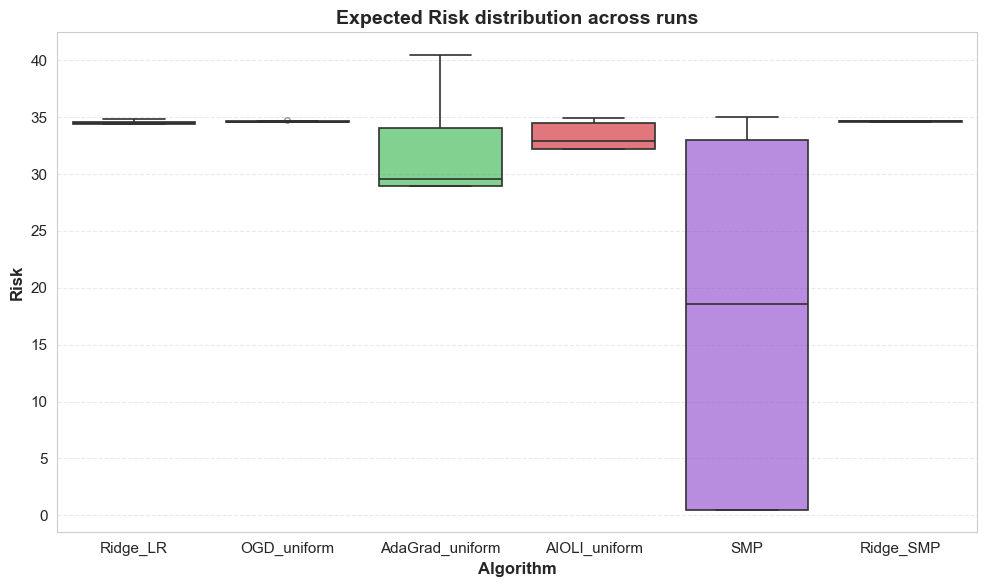

In [387]:
print_results(hazan_result, selected_algorithms = ["Classical_LR","SMP","AIOLI_uniform", "Ridge_LR","OGD_uniform","AdaGrad_uniform", "Ridge_SMP"], plot = True)

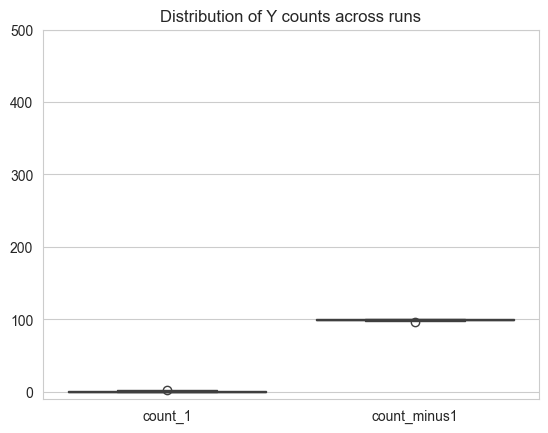

Train set
      run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1.0  100.0  100.0     99     98  100.0     99  100.0  100.0     97      99
 1.0    NaN    NaN      1      2    NaN      1    NaN    NaN      3       1
Test set
      run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1.0   50.0   50.0   50.0     49   50.0   50.0     49   50.0   50.0    50.0
 1.0    NaN    NaN    NaN      1    NaN    NaN      1    NaN    NaN     NaN


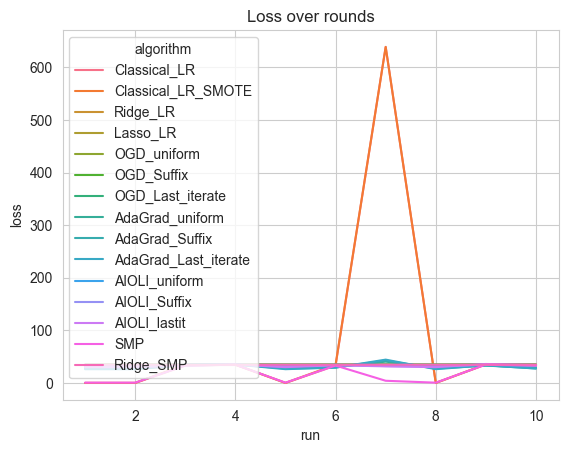

In [126]:
plot_results(hazan_result)

In [127]:
hazan_result["test_results"]

,run,algorithm,loss
0,1,Classical_LR,0.000128
1,1,Classical_LR_SMOTE,0.000128
2,1,Ridge_LR,34.410266
3,1,Lasso_LR,34.657359
4,1,OGD_uniform,34.598310
...,...,...,...
145,10,AIOLI_uniform,32.999314
146,10,AIOLI_Suffix,32.594096
147,10,AIOLI_lastit,33.909893
148,10,SMP,33.017581


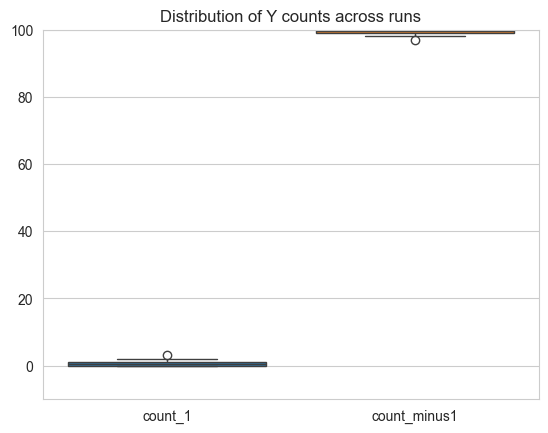

Train set
      run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1.0  100.0  100.0     99     98  100.0     99  100.0  100.0     97      99
 1.0    NaN    NaN      1      2    NaN      1    NaN    NaN      3       1
Test set
      run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1.0   50.0   50.0   50.0     49   50.0   50.0     49   50.0   50.0    50.0
 1.0    NaN    NaN    NaN      1    NaN    NaN      1    NaN    NaN     NaN


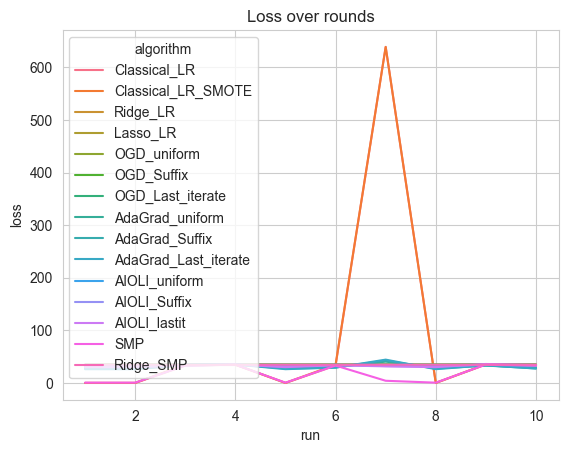

In [128]:
plot_results(hazan_result, n = 100)

In [120]:
hazan_Xminus1 = SimulationConfig(
    sim_setting = "hazan 1-dimensional",
    n = 100,
    runs = 10,
    X_hazan = -1
)

hazan_Xminus1_result = run_simulation(hazan_Xminus1)
print_results(hazan_Xminus1_result)

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.007983019647654204
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 1 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.007983019647654204
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 2 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.007983019647654204
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.007983019647654204
Lasso LR was fit ma

,Average_Loss,SE
algorithm,,
AIOLI_Suffix,32.324998,0.059627
AIOLI_lastit,32.116322,0.094471
AIOLI_uniform,33.080012,0.044749
AdaGrad_Last_iterate,30.208291,0.268513
AdaGrad_Suffix,30.540808,0.234950
AdaGrad_uniform,31.384576,0.178162
Classical_LR,80.835406,8.801082
Classical_LR_SMOTE,81.271760,8.795861
Lasso_LR,34.657359,0.000000


Total time: 0:00:54.037518


,Average_Loss,SE
algorithm,,
AIOLI_Suffix,32.324998,0.059627
AIOLI_lastit,32.116322,0.094471
AIOLI_uniform,33.080012,0.044749
AdaGrad_Last_iterate,30.208291,0.268513
AdaGrad_Suffix,30.540808,0.234950
AdaGrad_uniform,31.384576,0.178162
Classical_LR,80.835406,8.801082
Classical_LR_SMOTE,81.271760,8.795861
Lasso_LR,34.657359,0.000000


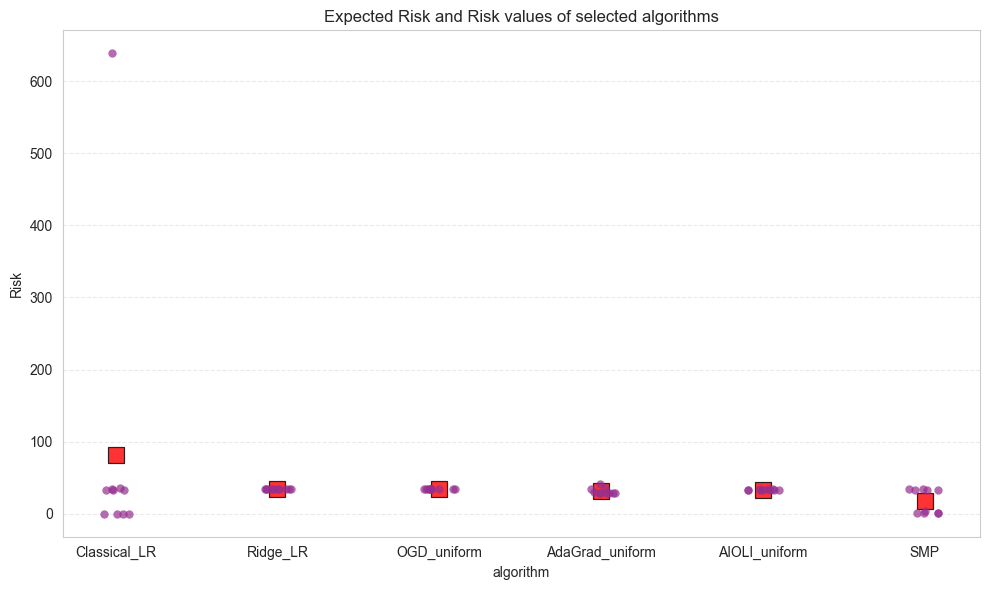

In [121]:
print_results(hazan_Xminus1_result, selected_algorithms = ["Classical_LR","SMP","AIOLI_uniform", "Ridge_LR","OGD_uniform","AdaGrad_uniform"], plot = True)

In [383]:
settings_results = {
    "Hazan": hazan_result,
    # "Hazan_Xminus1": hazan_Xminus1_result
}

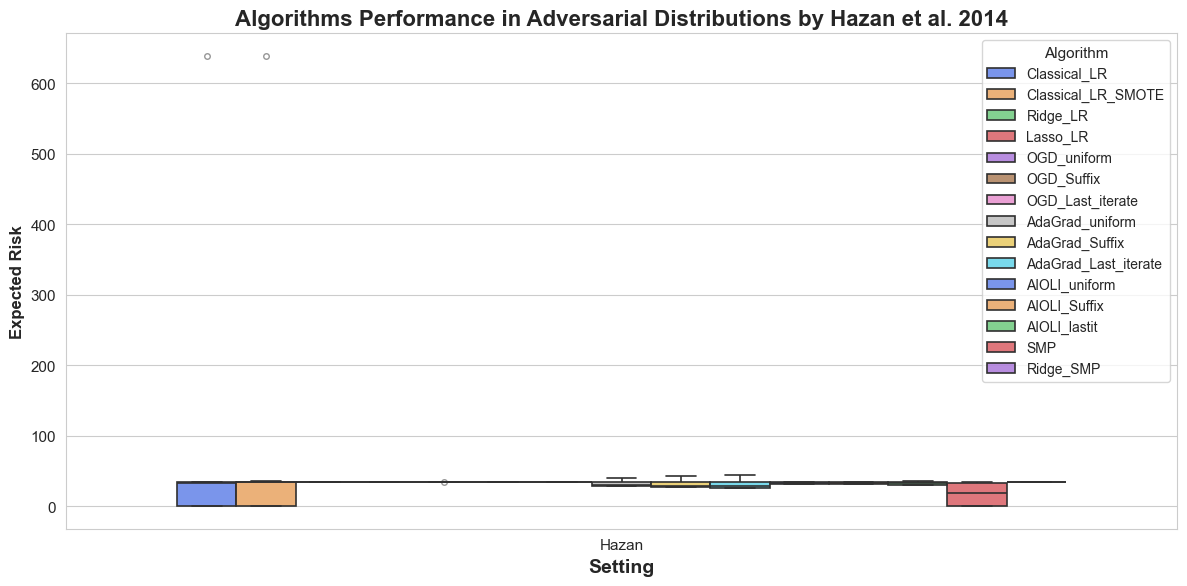

In [384]:
compare_settings(settings_results, title = "Algorithms Performance in Adversarial Distributions by Hazan et al. 2014")

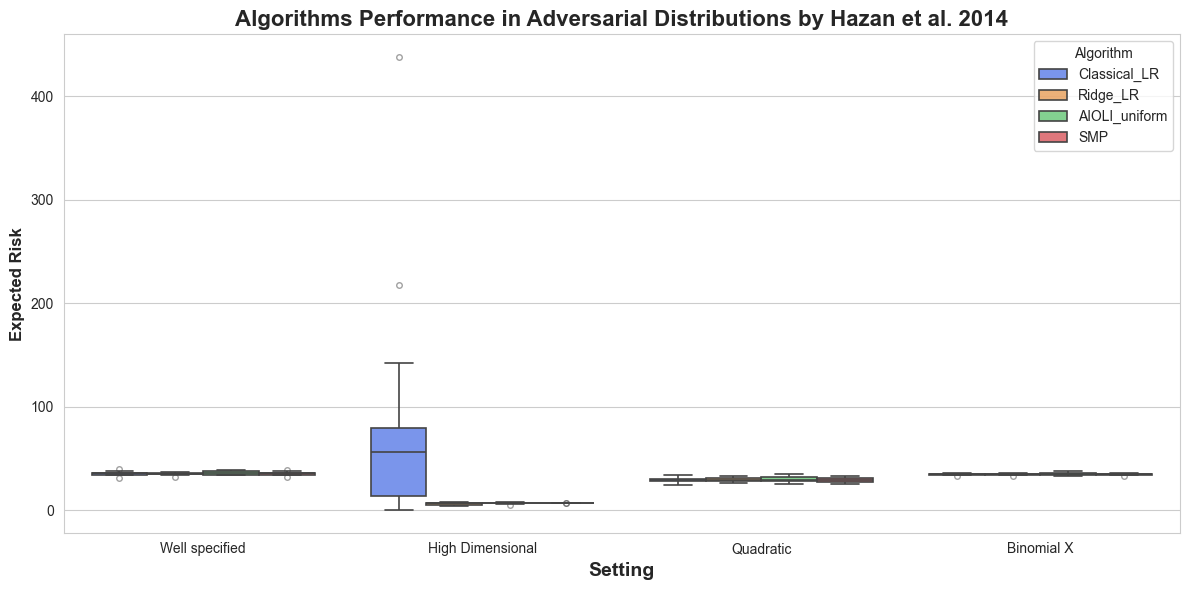

In [316]:

compare_settings(
    settings_results,
    selected_algorithms=["Classical_LR", "SMP", "AIOLI_uniform", "Ridge_LR"], title = "Algorithms Performance in Adversarial Distributions by Hazan et al. 2014"
)

## Balanced

In [300]:
binomial = SimulationConfig(
    sim_setting = "binomial_x",
    n = 100
)

binomial_result = run_simulation(binomial)
print_results(binomial_result)

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.529
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.471
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.492
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.42
Dataset is balanced
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.467
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.539
Lasso LR was f

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,35.922999,1.291762
AIOLI_lastit,35.057473,0.841739
AIOLI_uniform,34.861533,0.480805
AdaGrad_Last_iterate,34.942942,0.678975
AdaGrad_Suffix,35.941287,1.319562
AdaGrad_uniform,34.874934,0.408370
Classical_LR,34.617248,0.280144
Classical_LR_SMOTE,35.109492,0.536621
Lasso_LR,34.608315,0.231773



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.085199,3.809068,3.894267,0.492720
AIOLI_lastit,0.085199,3.898718,3.983917,0.626881
AIOLI_uniform,0.085199,3.830654,3.915853,0.529758
AdaGrad_Last_iterate,0.001280,0.000015,0.001296,0.000306
AdaGrad_Suffix,0.001280,0.000026,0.001306,0.000307
AdaGrad_uniform,0.001280,0.000028,0.001309,0.000307
Classical_LR,0.001496,0.000026,0.001522,0.000187
Classical_LR_SMOTE,0.001160,0.000015,0.001174,0.000166
Lasso_LR,0.002066,0.000011,0.002077,0.000312


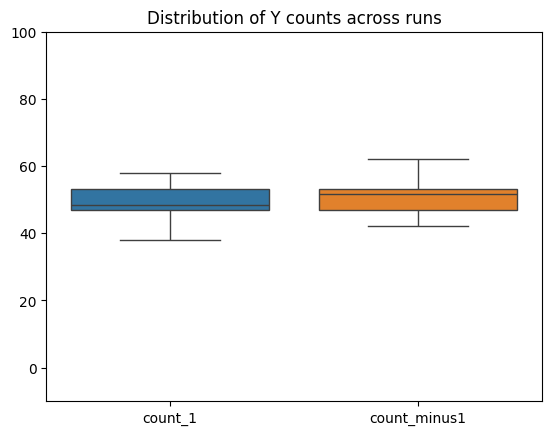

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     44     53     53     50     42     46     53     54     50      62
 1     56     47     47     50     58     54     47     46     50      38
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     21     22     27     32     27     34     26     34     21      27
 1     29     28     23     18     23     16     24     16     29      23


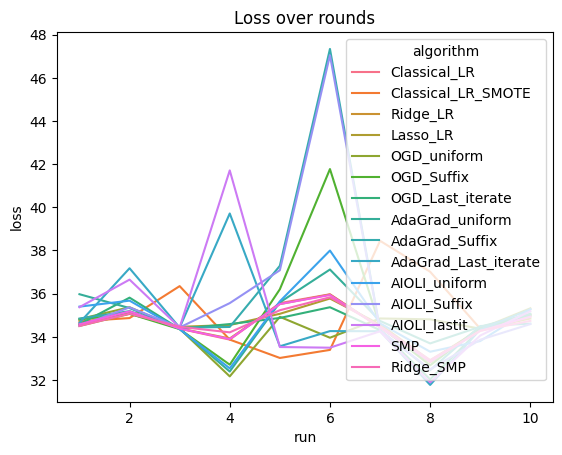

In [286]:
plot_results(binomial_result, n = 100)

In [141]:
# binomial_d3 = SimulationConfig(
#     sim_setting = "binomial_x",
#     n = 50,
#     runs = 10,
#     d = 3
# )
#
# binomial_d3_result = run_simulation(binomial_d3)
# print_results(binomial_d3_result)

In [146]:
well_specified = SimulationConfig(
    sim_setting = "well specified",
    d = 3
)

well_specified_result = run_simulation(well_specified)
print_results(well_specified_result)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.507
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.507
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.499
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.497
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.499
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.493
Lasso LR 

,Average_Loss,SE
algorithm,,
AIOLI_Suffix,35.653271,0.150527
AIOLI_lastit,35.387320,0.141810
AIOLI_uniform,35.907619,0.086008
AdaGrad_Last_iterate,36.835109,0.162216
AdaGrad_Suffix,35.068946,0.077316
AdaGrad_uniform,35.006536,0.039842
Classical_LR,35.573033,0.101320
Classical_LR_SMOTE,37.718318,0.185912
Lasso_LR,34.860149,0.041566


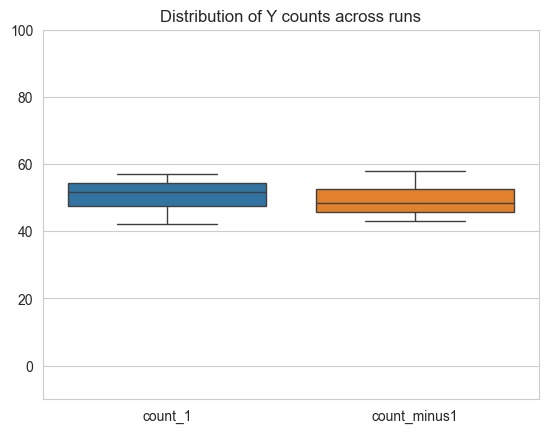

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     48     53     43     58     51     45     45     55     49      48
 1     52     47     57     42     49     55     55     45     51      52
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     18     29     27     21     27     31     25     30     22      27
 1     32     21     23     29     23     19     25     20     28      23


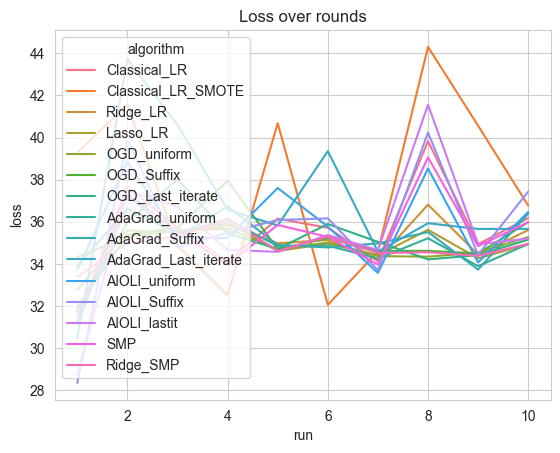

In [149]:
plot_results(well_specified_result)

In [ ]:
# well_specified_largebetas = SimulationConfig(
#     sim_betas = [4.4,-0.4,-6.2],
#     sim_setting = "well specified",
#     d = 3,
#     n = 100,
#     runs = 5
# )
#
# well_specified_largebetas_result = run_simulation(well_specified_largebetas)
# print_results(well_specified_largebetas_result)

In [ ]:
# plot_results(well_specified_largebetas_result, n = 100)

In [318]:
high_dimensional = SimulationConfig(
    sim_setting = "high dimensional",
    n = 20,
    d = 25,
    runs = 20
)

In [319]:

high_dimensional_result = run_simulation(high_dimensional)
print_results(high_dimensional_result)

20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.533
Lasso LR was fit manually
Run 1 finished
20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.526
Lasso LR was fit manually
Run 2 finished
20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.63
Lasso LR was fit manually
Run 3 finished
20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.553
Lasso LR was fit manually
Run 4 finished
20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.552
Dataset is balanced
Lasso LR was fit manually
Run 5 finished
20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an av

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,6.388586,2.178681e-01
AIOLI_lastit,6.160540,2.670541e-01
AIOLI_uniform,6.549780,1.663854e-01
AdaGrad_Last_iterate,60.728722,9.357486e+00
AdaGrad_Suffix,33.585508,8.082491e+00
AdaGrad_uniform,35.818833,1.078596e+01
Classical_LR,76.946138,3.183672e+01
Classical_LR_SMOTE,91.377065,3.547247e+01
Lasso_LR,6.785582,1.806855e-01



── Time Results (seconds) ──


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.514570,4.363728,4.878298,0.158458
AIOLI_lastit,0.514570,4.446910,4.961480,0.174524
AIOLI_uniform,0.514570,4.446894,4.961464,0.189471
AdaGrad_Last_iterate,0.001086,0.000009,0.001095,0.000155
AdaGrad_Suffix,0.001086,0.000058,0.001145,0.000166
AdaGrad_uniform,0.001086,0.000016,0.001102,0.000156
Classical_LR,0.003938,0.000018,0.003956,0.000384
Classical_LR_SMOTE,0.004151,0.000008,0.004160,0.000256
Lasso_LR,0.164714,0.000006,0.164720,0.031665


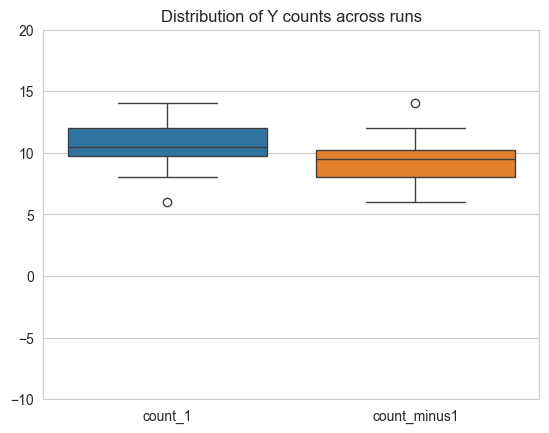

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10  \
-1      8      9      8     12     10      9     11     14     10      12   
 1     12     11     12      8     10     11      9      6     10       8   

    run_11  run_12  run_13  run_14  run_15  run_16  run_17  run_18  run_19  \
-1       8       6      10      11      10       8      10       9       9   
 1      12      14      10       9      10      12      10      11      11   

    run_20  
-1       8  
 1      12  
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10  \
-1      5      6      2      4      5      7      5      4      5       5   
 1      5      4      8      6      5      3      5      6      5       5   

    run_11  run_12  run_13  run_14  run_15  run_16  run_17  run_18  run_19  \
-1       2       6       5       6       5       3       4       5       4   
 1       8       4       5       4       5       7       6       5       6   

    run_

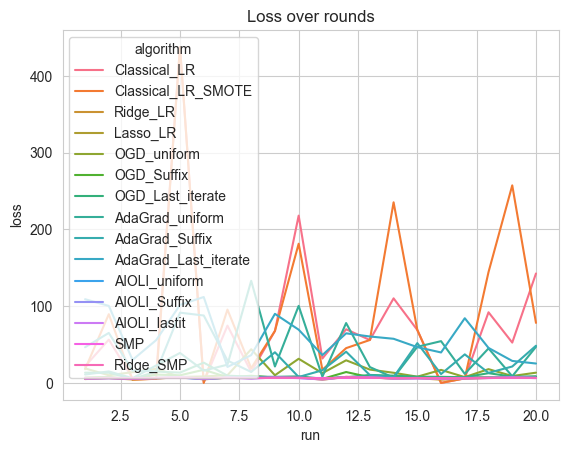

In [152]:
plot_results(high_dimensional_result, n = 20)

In [153]:
high_dimensionality = SimulationConfig(
    sim_setting = "high dimensional",
    runs = 20,
    n = 50,
    d = 25
)

high_dimensionality_result = run_simulation(high_dimensionality)
print_results(high_dimensionality_result)

50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.514
Lasso LR was fit manually
Run 1 finished
50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.441
Lasso LR was fit manually
Run 2 finished
50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.535
Lasso LR was fit manually
Run 3 finished
50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.582
Lasso LR was fit manually
Run 4 finished
50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.548
Lasso LR was fit manually
Run 5 finished
50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.4

,Average_Loss,SE
algorithm,,
AIOLI_Suffix,13.791506,0.101975
AIOLI_lastit,13.413619,0.128723
AIOLI_uniform,14.422207,0.073109
AdaGrad_Last_iterate,87.083061,1.371549
AdaGrad_Suffix,45.766713,0.900679
AdaGrad_uniform,53.981409,1.112085
Classical_LR,676.786587,48.205226
Classical_LR_SMOTE,1140.334977,80.967940
Lasso_LR,14.719613,0.118686


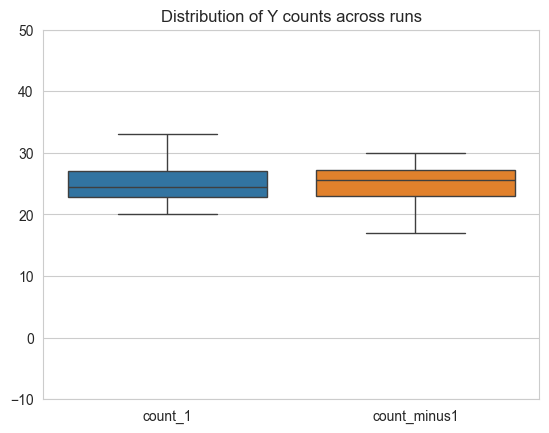

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10  \
-1     23     26     26     17     23     26     29     28     28      23   
 1     27     24     24     33     27     24     21     22     22      27   

    run_11  run_12  run_13  run_14  run_15  run_16  run_17  run_18  run_19  \
-1      26      24      29      22      23      22      27      30      25   
 1      24      26      21      28      27      28      23      20      25   

    run_20  
-1      21  
 1      29  
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10  \
-1     10     14      8     14     13     15     13     15     13      14   
 1     15     11     17     11     12     10     12     10     12      11   

    run_11  run_12  run_13  run_14  run_15  run_16  run_17  run_18  run_19  \
-1       8      10      11      14      12       8      11      11      11   
 1      17      15      14      11      13      17      14      14      14   

    run_

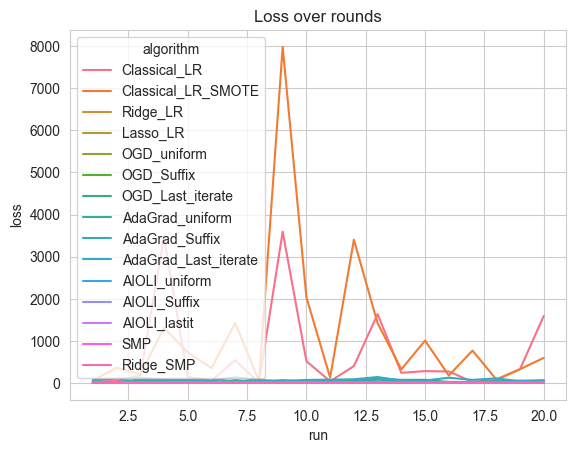

In [154]:
plot_results(high_dimensionality_result, n = 50)

In [ ]:
# sinusoidal = SimulationConfig(
#     sim_setting = "sinusoidal",
#     n = 100,
#     d = 3
# )
#
# sinusoidal_result = run_simulation(sinusoidal)
# print_results(sinusoidal_result)

In [ ]:
# plot_results(sinusoidal_result)

In [155]:
quadratic = SimulationConfig(
    sim_setting = "quadratic",
    d = 3
)

quadratic_result = run_simulation(quadratic)
print_results(quadratic_result)

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.053
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.05
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.053
Dataset is balanced
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.048
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.045
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.046
Lasso LR was fit man

,Average_Loss,SE
algorithm,,
AIOLI_Suffix,29.582092,0.153482
AIOLI_lastit,28.698127,0.133393
AIOLI_uniform,29.761501,0.126200
AdaGrad_Last_iterate,30.371513,0.100763
AdaGrad_Suffix,31.539523,0.102523
AdaGrad_uniform,32.143219,0.097921
Classical_LR,28.987478,0.119354
Classical_LR_SMOTE,30.840776,0.231025
Lasso_LR,29.677246,0.115929


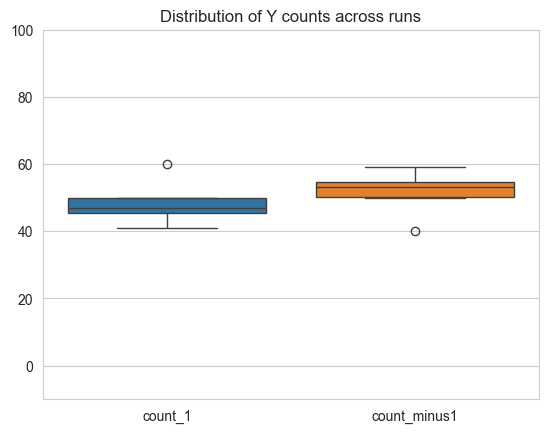

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     53     54     50     59     55     53     40     58     50      51
 1     47     46     50     41     45     47     60     42     50      49
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     21     34     25     20     30     27     28     30     25      30
 1     29     16     25     30     20     23     22     20     25      20


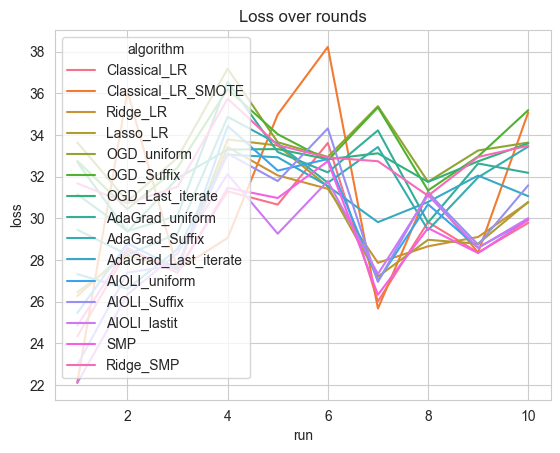

In [156]:
plot_results(quadratic_result)

In [331]:
settings_results1 = {
    # "Well specified": well_specified_result,
    # "High Dimensional": high_dimensional_result,
    "High Dimensionality": high_dimensionality_result,
    # "Quadratic": quadratic_result,
    # "Binomial X": binomial_result
}
settings_results = {
    "Well specified": well_specified_result,
    # "High Dimensional": high_dimensional_result,
    # "High Dimensionality": high_dimensionality_result,
    "Quadratic": quadratic_result,
    "Binomial X": binomial_result
}

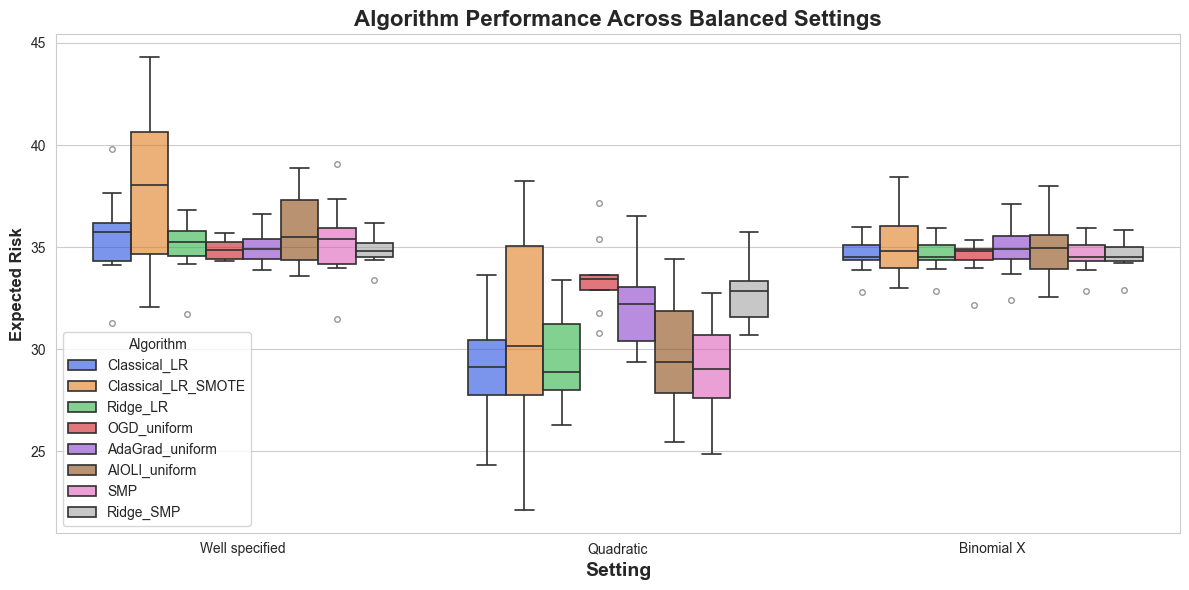

In [322]:
compare_settings(
    settings_results, selected_algorithms= [ "Classical_LR", "Classical_LR_SMOTE","Ridge_LR","OGD_uniform","AdaGrad_uniform","AIOLI_uniform","SMP","Ridge_SMP"]
)

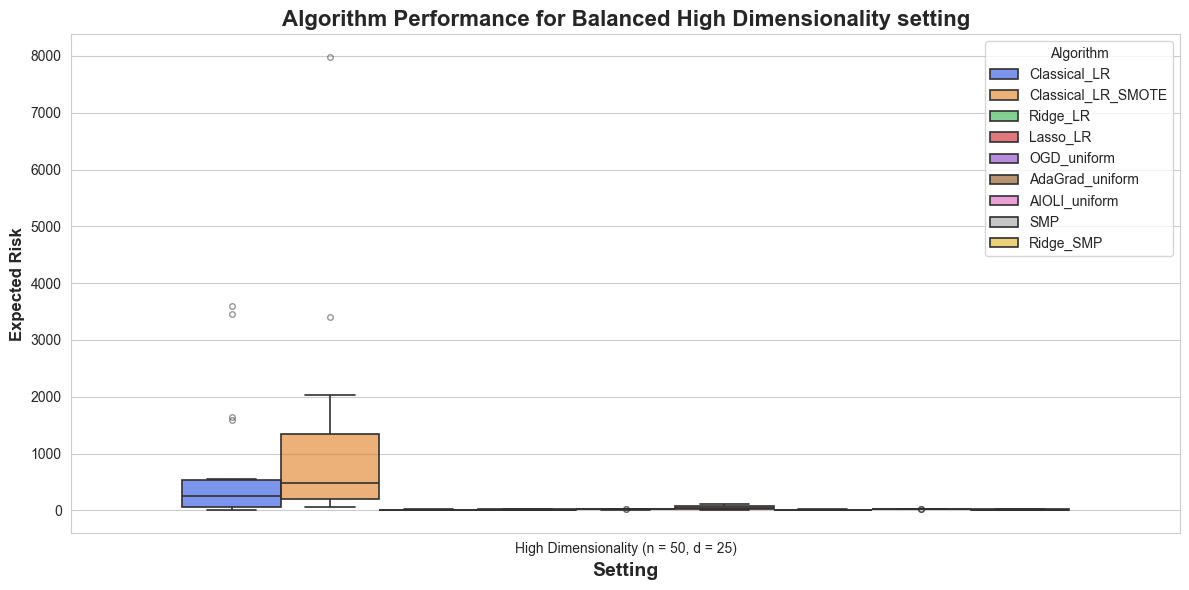

In [332]:
compare_settings(
    settings_results1,
    title = "Algorithm Performance for Balanced High Dimensionality setting", selected_algorithms= [ "Classical_LR", "Classical_LR_SMOTE","Ridge_LR","Lasso_LR","OGD_uniform","AdaGrad_uniform","AIOLI_uniform","SMP","Ridge_SMP"],
    x_labels={"High Dimensional": "High Dimensional (n = 20, d = 25)", "High Dimensionality": "High Dimensionality (n = 50, d = 25)"}
)

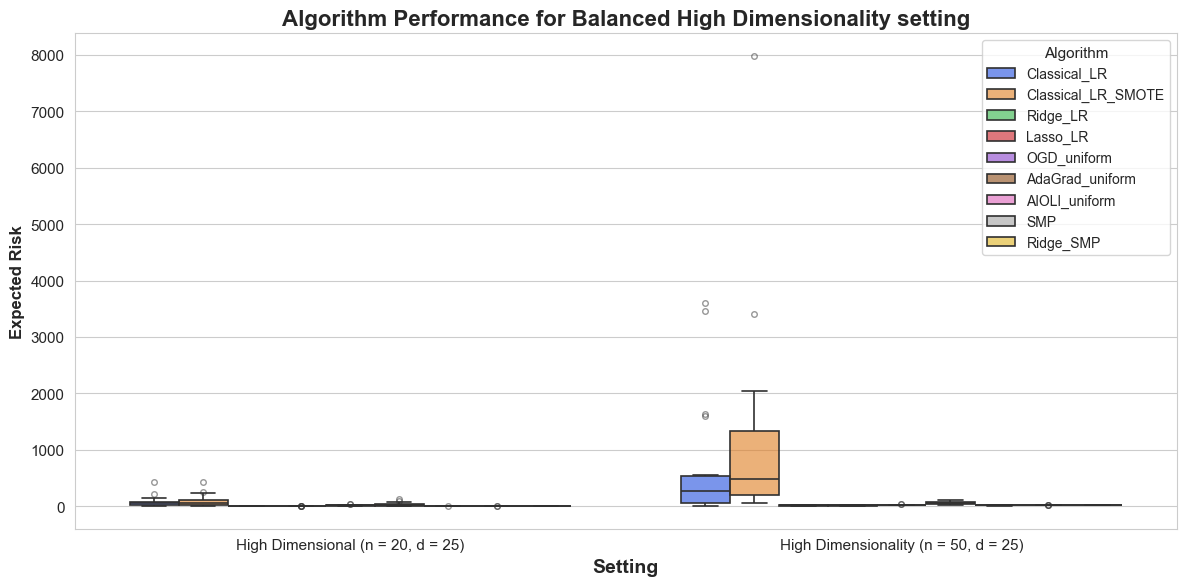

In [161]:
# FOR AVERAGING STRATEGIES PART

settings_results_HD = {
    # "Well specified": well_specified_result,
    "High Dimensional": high_dimensional_result,
    "High Dimensionality": high_dimensionality_result,
    # "Quadratic": quadratic_result,
    # "Binomial X": binomial_result
}

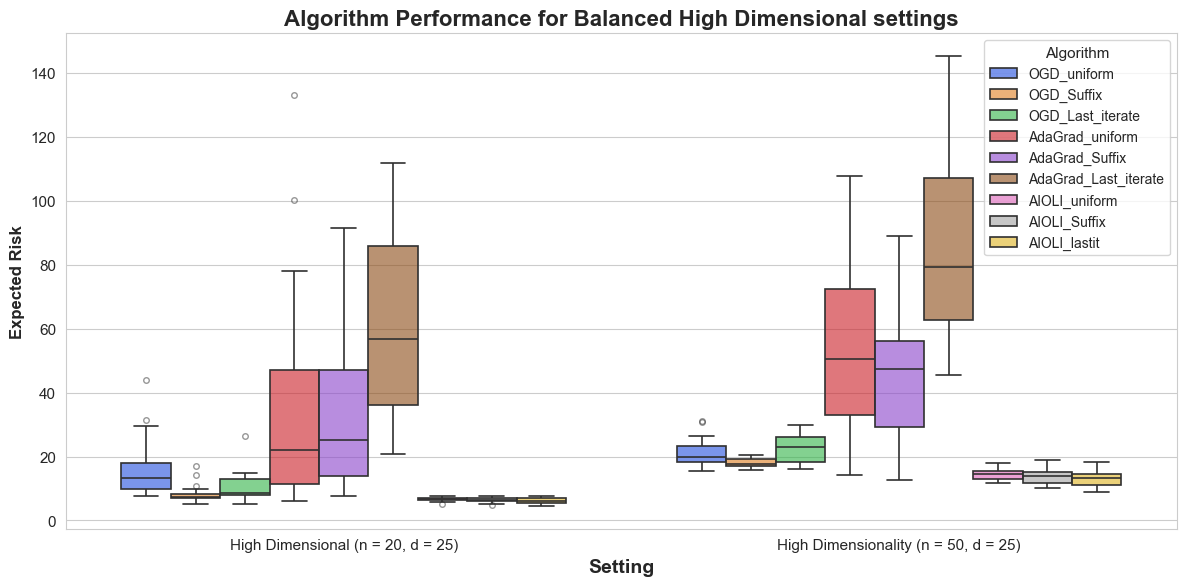

In [360]:
compare_settings(
    settings_results_HD,
    title = "Algorithm Performance for Balanced High Dimensional settings", selected_algorithms= [ "OGD_uniform","AdaGrad_uniform","AIOLI_uniform",
                                                                                                     "OGD_Suffix","OGD_Last_iterate","AdaGrad_Suffix","AdaGrad_Last_iterate",
                                                                                                     "AIOLI_Suffix","AIOLI_lastit"],
    x_labels={"High Dimensional": "High Dimensional (n = 20, d = 25)", "High Dimensionality": "High Dimensionality (n = 50, d = 25)"}
)

In [163]:
highly_correlated_x = SimulationConfig(
    sim_setting = "highly correlated x",
    n = 100,
    d = 3
)

highly_correlated_x_result = run_simulation(highly_correlated_x)
print_results(highly_correlated_x_result)

100 (training) samples were generated in the highly correlated x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.547
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the highly correlated x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.496
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the highly correlated x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.237
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the highly correlated x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.532
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the highly correlated x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.637
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the highly correlated x balanced setting. Using 3 variable(s), with an ave

,Average_Loss,SE
algorithm,,
AIOLI_Suffix,33.703218,0.172553
AIOLI_lastit,32.963774,0.159397
AIOLI_uniform,33.305961,0.150371
AdaGrad_Last_iterate,38.625866,0.317445
AdaGrad_Suffix,33.678181,0.156005
AdaGrad_uniform,33.466542,0.140187
Classical_LR,32.996586,0.146724
Classical_LR_SMOTE,35.445022,0.180176
Lasso_LR,33.011967,0.139714


In [164]:
alternating = SimulationConfig(
    sim_setting = "alternating",
    n = 100,
    d = 3,
    runs = 4
)

alternating_result = run_simulation(alternating)
print_results(alternating_result)

100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.478
Dataset is balanced
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.468
Dataset is balanced
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.453
Dataset is balanced
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.442
Dataset is balanced
Lasso LR was fit manually
Run 4 finished
Total time: 0:01:29.748031


,Average_Loss,SE
algorithm,,
AIOLI_Suffix,35.768139,0.031929
AIOLI_lastit,34.845802,0.022339
AIOLI_uniform,36.014131,0.074039
AdaGrad_Last_iterate,35.706291,0.031965
AdaGrad_Suffix,35.466718,0.053082
AdaGrad_uniform,35.504495,0.053734
Classical_LR,35.369201,0.041825
Classical_LR_SMOTE,35.369201,0.041825
Lasso_LR,34.738284,0.007238


## Unbalanced

### Experiments

In [165]:
1 - (0.002 +0.002)

0.996

In [166]:
binomial_unbalanced = SimulationConfig(
    sim_setting = "binomial_x",
    n = 100,
    d = 1,
    sim_balanced= False
)

binomial_unbalanced_result = run_simulation(binomial_unbalanced)
print_results(binomial_unbalanced_result)

100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.994
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 1 finished
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.99
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.993
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 3 finished
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.994
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the binomial_x unbalanced 

,Average_Loss,SE
algorithm,,
AIOLI_Suffix,1.396501,0.089337
AIOLI_lastit,1.298265,0.092613
AIOLI_uniform,1.620131,0.081936
AdaGrad_Last_iterate,1.315917,0.119411
AdaGrad_Suffix,1.365502,0.117663
AdaGrad_uniform,1.349890,0.116176
Classical_LR,3.037080,0.315852
Classical_LR_SMOTE,3.403349,0.312598
Lasso_LR,1.439192,0.091816


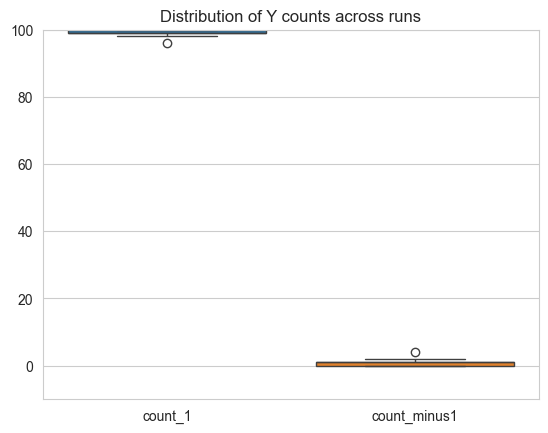

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1    NaN      1    NaN      1    NaN      2    NaN      4      1       1
 1  100.0     99  100.0     99  100.0     98  100.0     96     99      99
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1    NaN    NaN      1    NaN    NaN      1    NaN    NaN    NaN     NaN
 1   50.0   50.0     49   50.0   50.0     49   50.0   50.0   50.0    50.0


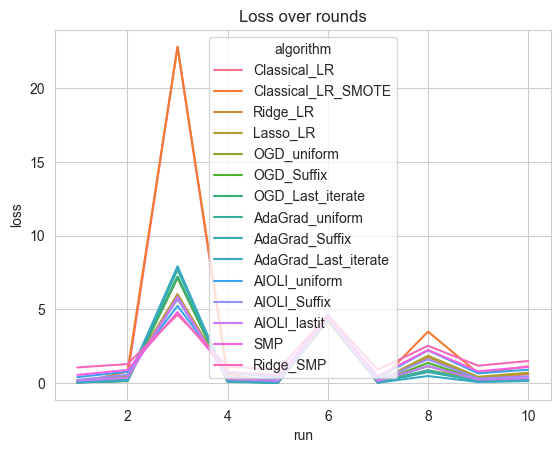

In [167]:
plot_results(binomial_unbalanced_result, n = 100)

In [168]:
well_specified_unbalanced = SimulationConfig(
    sim_setting = "well specified",
    sim_balanced= False
)

well_specified_unbalanced_result = run_simulation(well_specified_unbalanced)
print_results(well_specified_unbalanced_result)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.991
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.996
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 2 finished
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.995
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 3 finished
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.998
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
L

,Average_Loss,SE
algorithm,,
AIOLI_Suffix,1.065466,0.049596
AIOLI_lastit,0.932125,0.051749
AIOLI_uniform,1.399067,0.044630
AdaGrad_Last_iterate,1.522374,0.134202
AdaGrad_Suffix,1.506063,0.127369
AdaGrad_uniform,1.436494,0.114580
Classical_LR,4.293508,0.401559
Classical_LR_SMOTE,4.343716,0.400539
Lasso_LR,1.397457,0.077751


In [348]:
well_specified_unbalanced_result["test_results"]

,run,algorithm,loss
0,1,Classical_LR,0.399944
1,1,Classical_LR_SMOTE,0.902025
2,1,Ridge_LR,0.753958
3,1,Lasso_LR,0.783846
4,1,OGD_uniform,1.149101
...,...,...,...
145,10,AIOLI_uniform,3.244153
146,10,AIOLI_Suffix,3.410974
147,10,AIOLI_lastit,3.511104
148,10,SMP,4.340099


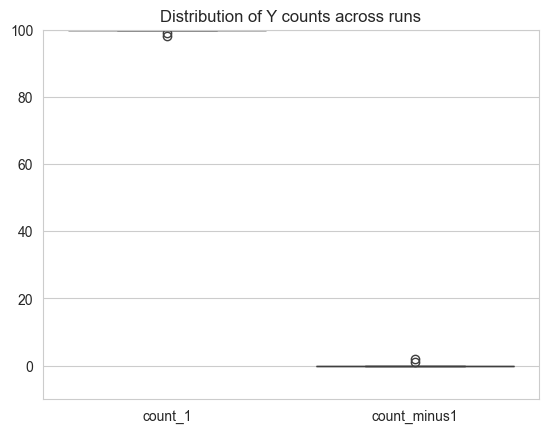

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1      1    NaN    NaN    NaN    NaN    NaN    NaN      2    NaN     NaN
 1     99  100.0  100.0  100.0  100.0  100.0  100.0     98  100.0   100.0
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1    NaN    NaN    NaN    NaN    NaN      1    NaN    NaN    NaN       1
 1   50.0   50.0   50.0   50.0   50.0     49   50.0   50.0   50.0      49


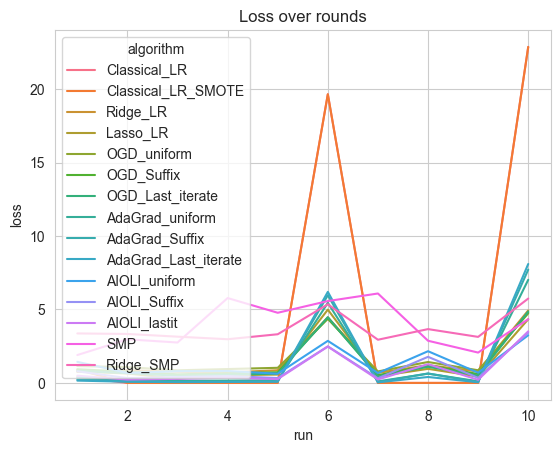

In [169]:
plot_results(well_specified_unbalanced_result)

In [357]:
well_specified_unbalanced_result["test_results"]

,run,algorithm,loss
0,1,Classical_LR,0.399944
1,1,Classical_LR_SMOTE,0.902025
2,1,Ridge_LR,0.753958
3,1,Lasso_LR,0.783846
4,1,OGD_uniform,1.149101
...,...,...,...
145,10,AIOLI_uniform,3.244153
146,10,AIOLI_Suffix,3.410974
147,10,AIOLI_lastit,3.511104
148,10,SMP,4.340099


In [170]:
high_dimensional_unbalanced = SimulationConfig(
    sim_setting = "high dimensional",
    n = 20,
    d = 25,
    runs = 20,
    sim_balanced= False
)

high_dimensional_unbalanced_result = run_simulation(high_dimensional_unbalanced)
print_results(high_dimensional_unbalanced_result)


20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.821
Lasso LR was fit manually
Run 1 finished
20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.835
Lasso LR was fit manually
Run 2 finished
20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.846
Lasso LR was fit manually
Run 3 finished
20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.764
Lasso LR was fit manually
Run 4 finished
20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.827
Lasso LR was fit manually
Run 5 finished
20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P

,Average_Loss,SE
algorithm,,
AIOLI_Suffix,4.984469,5.198707e-02
AIOLI_lastit,5.009709,5.168965e-02
AIOLI_uniform,5.268192,4.542593e-02
AdaGrad_Last_iterate,39.355966,2.833307e+00
AdaGrad_Suffix,21.595758,8.956640e-01
AdaGrad_uniform,36.459350,1.342090e+00
Classical_LR,46.680858,2.286884e+00
Classical_LR_SMOTE,33.925305,1.299250e+00
Lasso_LR,4.921841,1.052791e-01


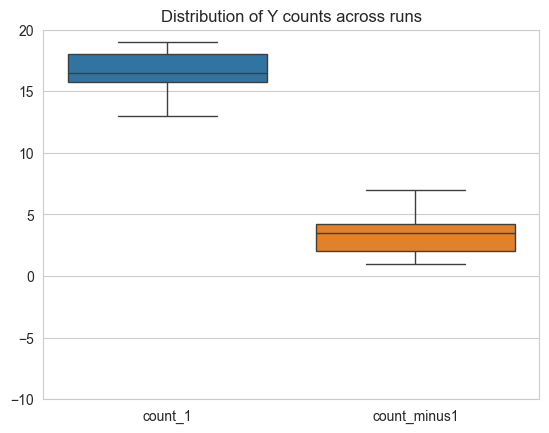

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10  \
 1     17     15     15     15     16     18     16     13     19      17   
-1      3      5      5      5      4      2      4      7      1       3   

    run_11  run_12  run_13  run_14  run_15  run_16  run_17  run_18  run_19  \
 1      18      19      18      18      16      18      14      16      16   
-1       2       1       2       2       4       2       6       4       4   

    run_20  
 1      17  
-1       3  
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10  \
-1      2    NaN      2      1      3      5      1      3      1       1   
 1      8   10.0      8      9      7      5      9      7      9       9   

    run_11  run_12  run_13  run_14  run_15  run_16  run_17  run_18  run_19  \
-1     NaN       3       1       3       2       2       1       1     NaN   
 1    10.0       7       9       7       8       8       9       9    10.0   

    run_

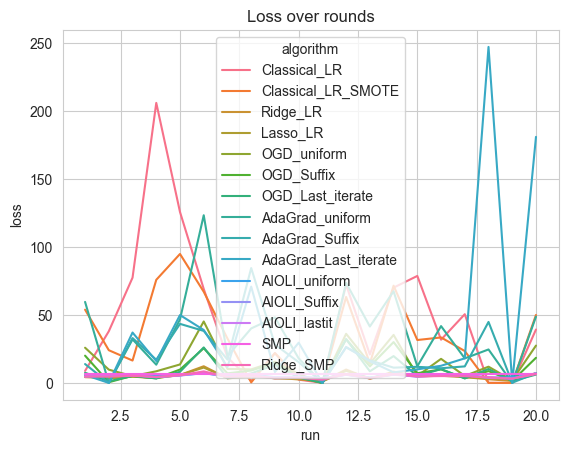

In [171]:
plot_results(high_dimensional_unbalanced_result, n = 20)

In [172]:
high_dimensionality_unbalanced = SimulationConfig(
    sim_setting = "high dimensional",
    runs = 20,
    n = 50,
    d = 25,
    sim_balanced = False
)

high_dimensionality_unbalanced_result = run_simulation(high_dimensionality_unbalanced)
print_results(high_dimensionality_unbalanced_result)


50 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.784
Lasso LR was fit manually
Run 1 finished
50 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.788
Lasso LR was fit manually
Run 2 finished
50 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.789
Lasso LR was fit manually
Run 3 finished
50 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.837
Lasso LR was fit manually
Run 4 finished
50 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.851
Lasso LR was fit manually
Run 5 finished
50 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P

,Average_Loss,SE
algorithm,,
AIOLI_Suffix,11.133631,0.057619
AIOLI_lastit,10.325865,0.070925
AIOLI_uniform,11.966364,0.049435
AdaGrad_Last_iterate,67.881885,3.245475
AdaGrad_Suffix,31.295564,0.954793
AdaGrad_uniform,44.807182,1.014223
Classical_LR,288.041657,9.907980
Classical_LR_SMOTE,253.844579,9.068596
Lasso_LR,10.542342,0.088183


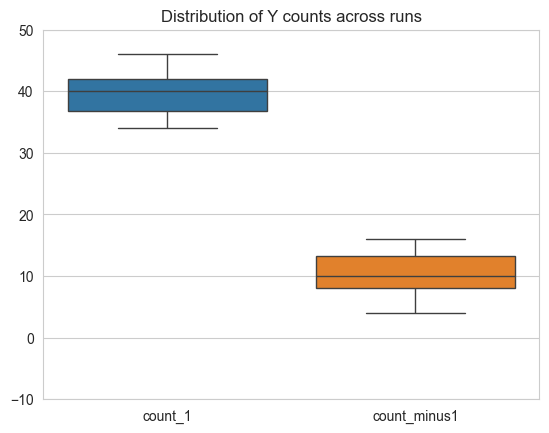

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10  \
 1     38     38     39     46     42     40     44     34     35      45   
-1     12     12     11      4      8     10      6     16     15       5   

    run_11  run_12  run_13  run_14  run_15  run_16  run_17  run_18  run_19  \
 1      36      40      43      41      37      41      35      34      42   
-1      14      10       7       9      13       9      15      16       8   

    run_20  
 1      41  
-1       9  
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10  \
 1     22     21     20     20     19     18     22     18     23      22   
-1      3      4      5      5      6      7      3      7      2       3   

    run_11  run_12  run_13  run_14  run_15  run_16  run_17  run_18  run_19  \
 1      24      21      23      21      21      21      20      23      22   
-1       1       4       2       4       4       4       5       2       3   

    run_

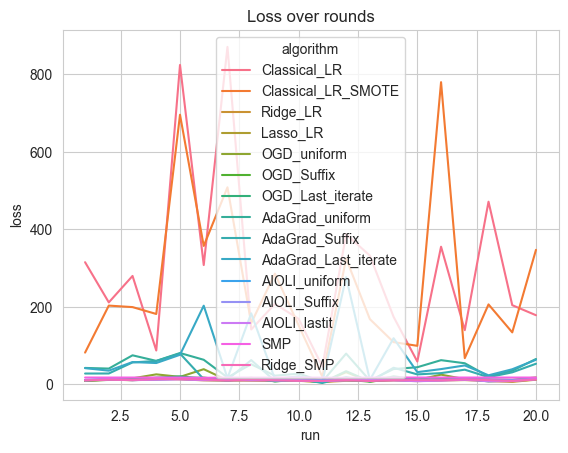

In [173]:
plot_results(high_dimensionality_unbalanced_result, n =50)

In [174]:
# sinusoidal_unbalanced = SimulationConfig(
#     sim_setting = "sinusoidal",
#     n = 100,
#     d = 3,
#     sim_balanced=False
# )
#
# sinusoidal_unbalanced_result = run_simulation(sinusoidal_unbalanced)
# print_results(sinusoidal_unbalanced_result)

In [175]:
# plot_results(sinusoidal_unbalanced_result, n = 100)

In [176]:
quadratic_unbalanced = SimulationConfig(
    sim_setting = "quadratic",
    d = 3,
    sim_balanced= False
)

quadratic_unbalanced_result = run_simulation(quadratic_unbalanced)
print_results(quadratic_unbalanced_result)

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.086
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.078
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.076
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.065
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 4 finished
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.07
Dataset only has one class
Logistic regression was fit manually
Ridge 

,Average_Loss,SE
algorithm,,
AIOLI_Suffix,4.210881,0.105384
AIOLI_lastit,4.250870,0.097343
AIOLI_uniform,4.127819,0.092798
AdaGrad_Last_iterate,5.222755,0.142636
AdaGrad_Suffix,5.721607,0.175135
AdaGrad_uniform,5.330125,0.166164
Classical_LR,8.061203,0.343075
Classical_LR_SMOTE,8.203852,0.344276
Lasso_LR,4.123288,0.100152


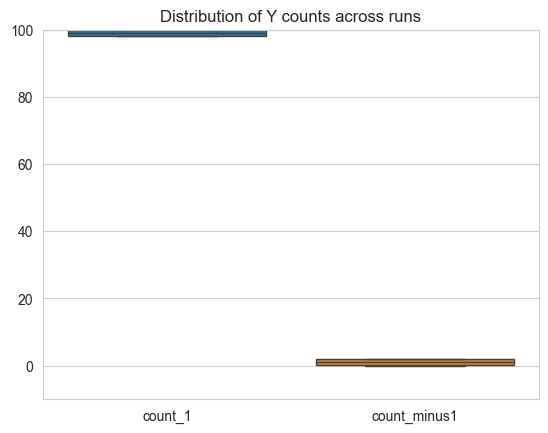

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1      1      1      2    NaN    NaN      2    NaN      2      2       1
 1     99     99     98  100.0  100.0     98  100.0     98     98      99
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1    NaN      1    NaN      1      1      1      1      1      1       2
 1   50.0     49   50.0     49     49     49     49     49     49      48


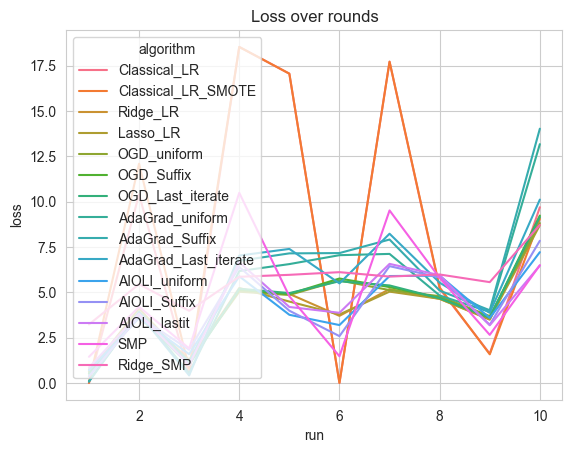

In [177]:
plot_results(quadratic_unbalanced_result)

In [349]:
settings_unbalanced_results = {
    "Well specified": well_specified_unbalanced_result,
    # "High Dimensional": high_dimensional_unbalanced_result,
    # "High Dimensionality": high_dimensionality_unbalanced_result,
    "Quadratic": quadratic_unbalanced_result,
    "Binomial X": binomial_unbalanced_result
}

settings_unbalanced_results1 = {
    # "Well specified": well_specified_unbalanced_result,
    "High Dimensional": high_dimensional_unbalanced_result,
    "High Dimensionality": high_dimensionality_unbalanced_result,
    # "Quadratic": quadratic_unbalanced_result,
    # "Binomial X": binomial_unbalanced_result
}

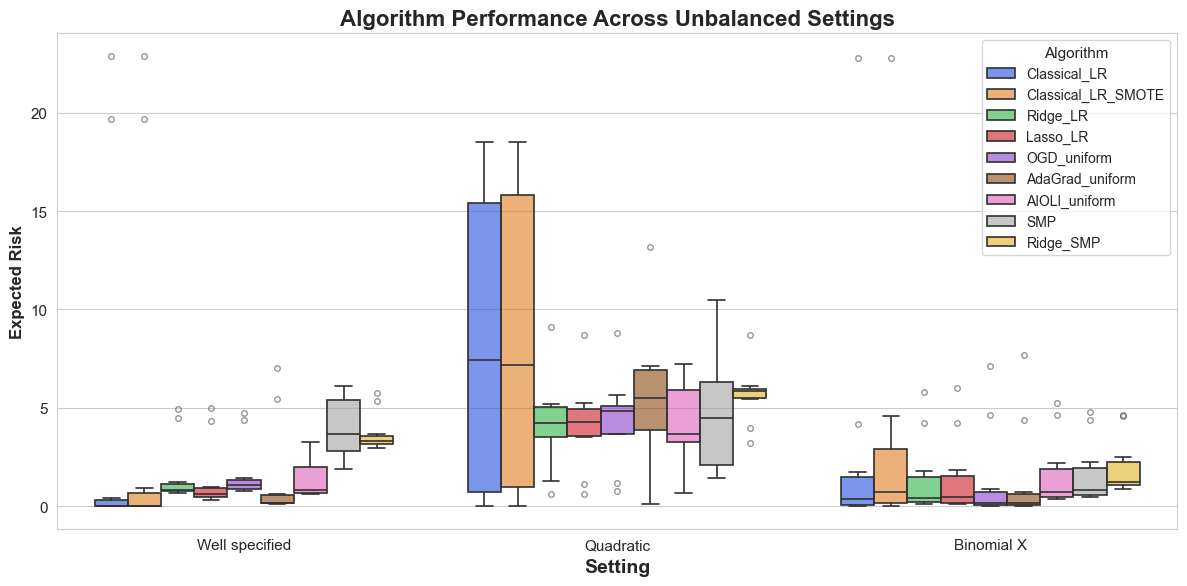

In [346]:
compare_settings(
    settings_unbalanced_results,
    title = "Algorithm Performance Across Unbalanced Settings", selected_algorithms= [ "Classical_LR", "Classical_LR_SMOTE","Lasso_LR","Ridge_LR","OGD_uniform","AIOLI_uniform","SMP","Ridge_SMP", "AdaGrad_uniform"]
)

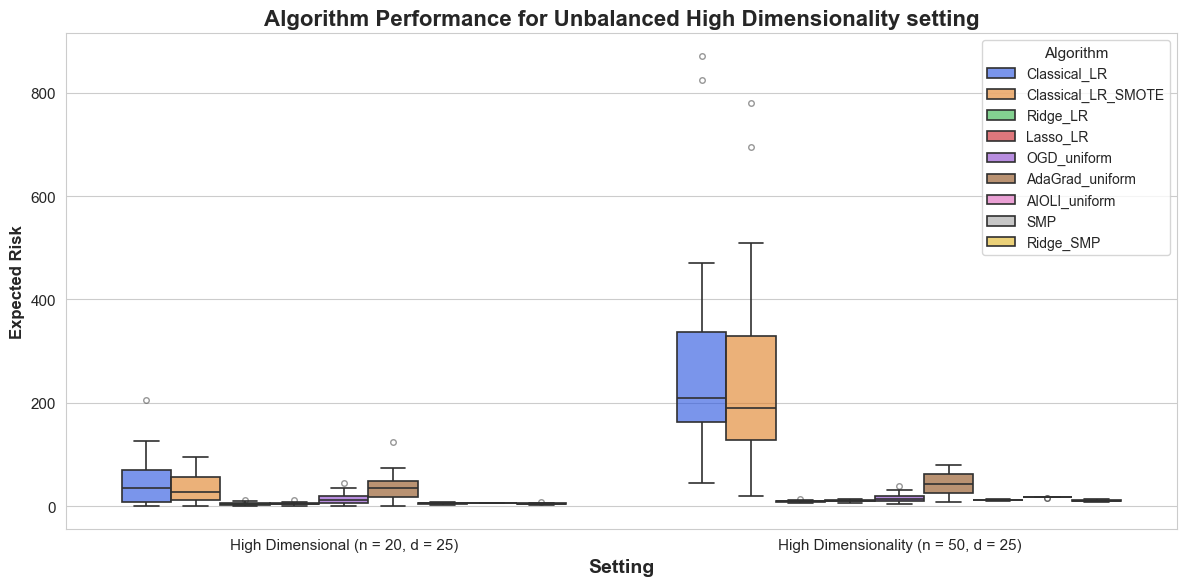

In [355]:
compare_settings(
    settings_unbalanced_results1,
    title = "Algorithm Performance for Unbalanced High Dimensionality setting", selected_algorithms= [ "Classical_LR", "Classical_LR_SMOTE","Ridge_LR","Lasso_LR","OGD_uniform","AdaGrad_uniform","AIOLI_uniform","SMP","Ridge_SMP"],
    x_labels={"High Dimensional": "High Dimensional (n = 20, d = 25)", "High Dimensionality": "High Dimensionality (n = 50, d = 25)"}
)

## Changing n

In [376]:
hazan_small_n = simulations_changing_n([10,20,40,60], hazan, filename = "hazan_small_n", B_hazan = 9)

Running simulations for n = 10

10 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.006666666666666667
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 1 finished
10 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.006666666666666667
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 2 finished
10 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.006666666666666667
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 3 finished
10 (training) 

In [379]:
hazan_small_n[1]

,run,algorithm,loss,n
0,1,Classical_LR,0.000335,10
1,1,Classical_LR_SMOTE,0.000335,10
2,1,Ridge_LR,3.464964,10
3,1,Lasso_LR,3.465736,10
4,1,OGD_uniform,3.465308,10
...,...,...,...,...
595,10,AIOLI_uniform,20.567821,60
596,10,AIOLI_Suffix,20.453606,60
597,10,AIOLI_lastit,20.344284,60
598,10,SMP,0.487836,60


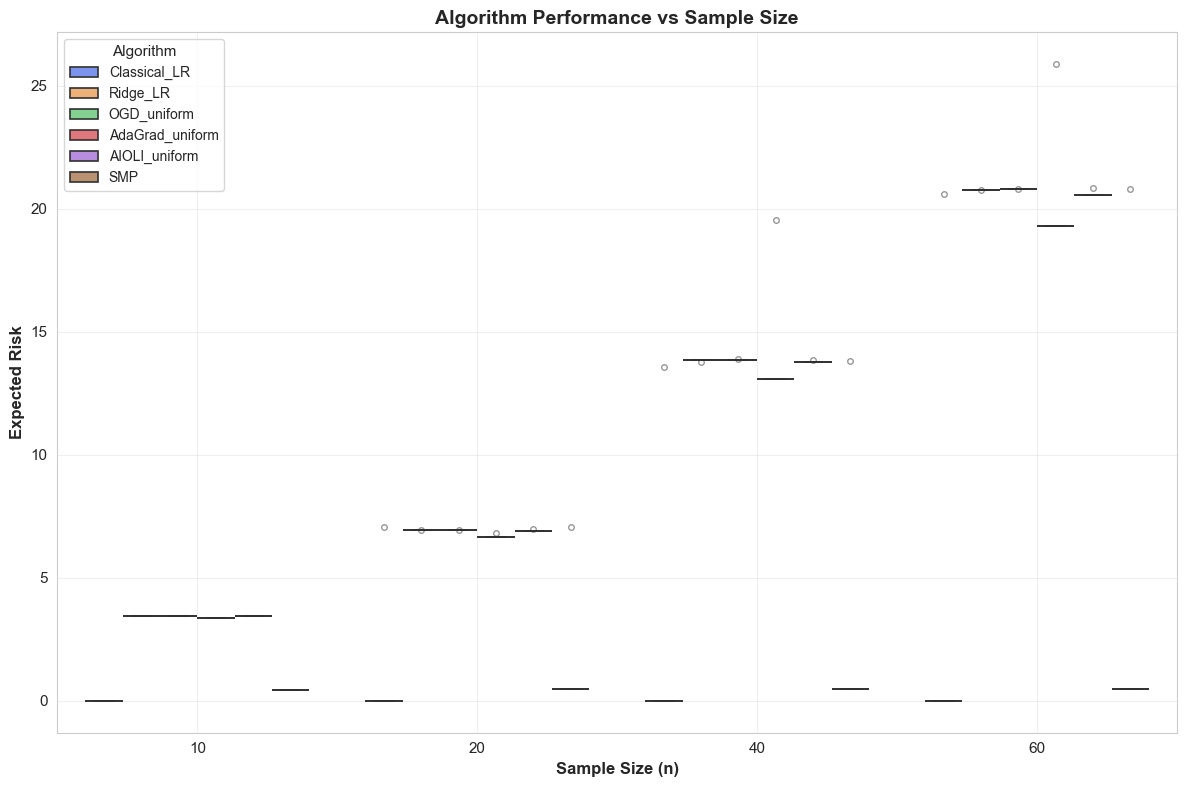

In [378]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP", "Ridge_LR","OGD_uniform","AdaGrad_uniform", "Classical_LR"] ,raw_data= hazan_small_n[1])

In [361]:
hazan_changing_n = simulations_changing_n([20,100,200,300], hazan, filename = "hazan_changing_n")

Running simulations for n = 20

20 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.017640846227712365
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 1 finished
20 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.017640846227712365
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 2 finished
20 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.017640846227712365
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 3 finished
20 (training) 

In [362]:
hazan_changing_n[1]

,run,algorithm,loss,n
0,1,Classical_LR,0.000134,20
1,1,Classical_LR_SMOTE,0.000134,20
2,1,Ridge_LR,6.909931,20
3,1,Lasso_LR,6.931472,20
4,1,OGD_uniform,6.921731,20
...,...,...,...,...
595,10,AIOLI_uniform,89.391936,300
596,10,AIOLI_Suffix,85.602167,300
597,10,AIOLI_lastit,86.395258,300
598,10,SMP,57.345582,300


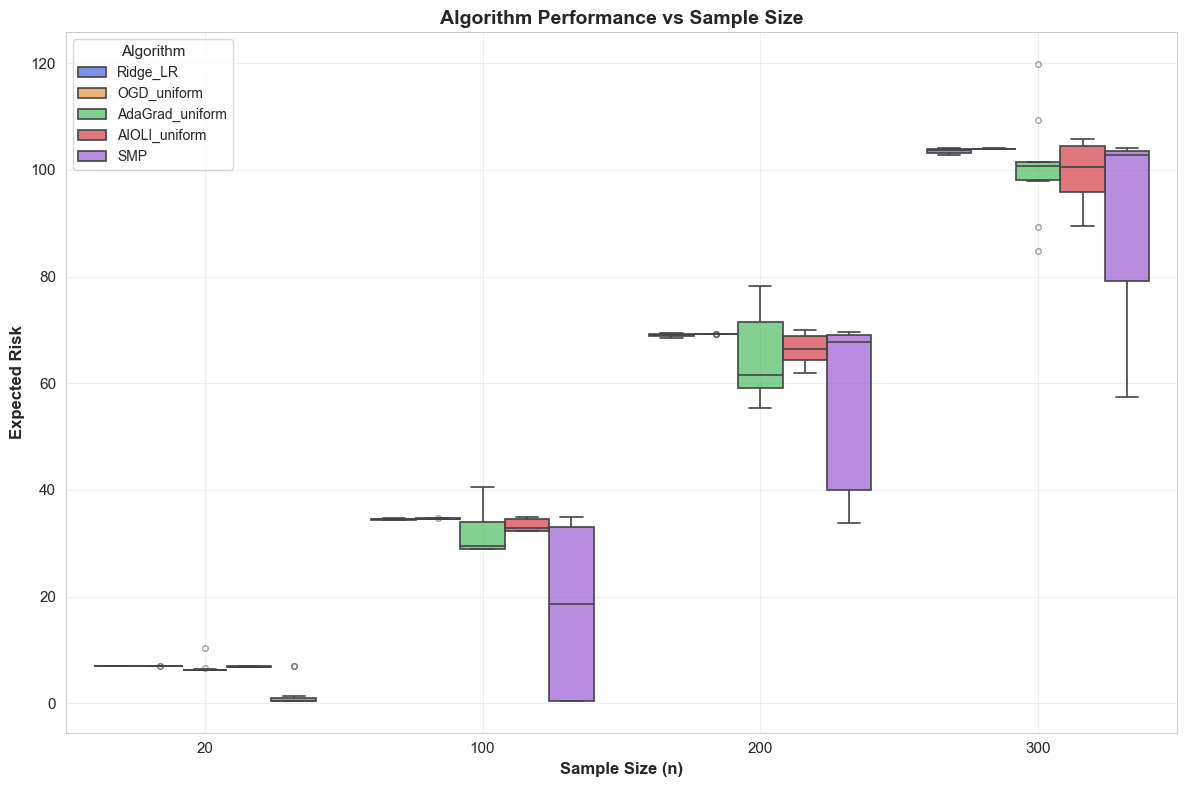

In [364]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP", "Ridge_LR","OGD_uniform","AdaGrad_uniform"] ,raw_data= hazan_changing_n[1])

In [375]:
hazan_changing_n[0]

,n,algorithm,avg_loss,std_loss,num_runs
0,20,AIOLI_Suffix,6.862820,0.115932,10
1,20,AIOLI_lastit,6.837333,0.140487,10
2,20,AIOLI_uniform,6.883563,0.073988,10
3,20,AdaGrad_Last_iterate,6.671635,2.170189,10
4,20,AdaGrad_Suffix,6.676796,1.817305,10
5,20,AdaGrad_uniform,6.709306,1.260318,10
6,20,Classical_LR,39.022516,118.469331,10
7,20,Classical_LR_SMOTE,39.048639,118.461515,10
8,20,Lasso_LR,6.931472,0.000000,10
9,20,OGD_Last_iterate,6.926461,0.019491,10


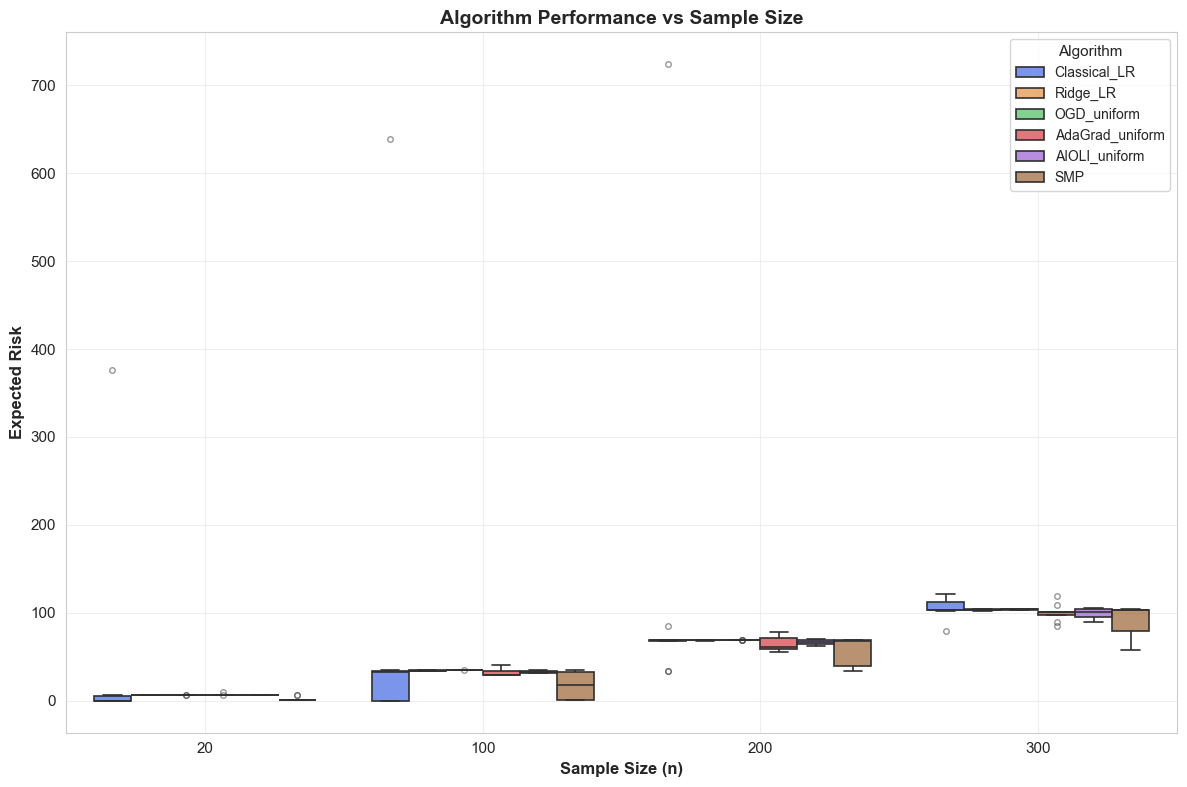

In [373]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP", "Ridge_LR","OGD_uniform","AdaGrad_uniform", "Classical_LR"] ,raw_data= hazan_changing_n[1])

In [189]:
high_dimensional_changing_n = simulations_changing_n([10,30,50,100], high_dimensional, filename = "high_dimensional_changing_n")

Running simulations for n = 10

10 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.525
Lasso LR was fit manually
Run 1 finished
10 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.541
Lasso LR was fit manually
Run 2 finished
10 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.705
Lasso LR was fit manually
Run 3 finished
10 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.547
Lasso LR was fit manually
Run 4 finished
10 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.505
Lasso LR was fit manually
Run 5 finished
10 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s

In [283]:
# high_dimensional_changing_n

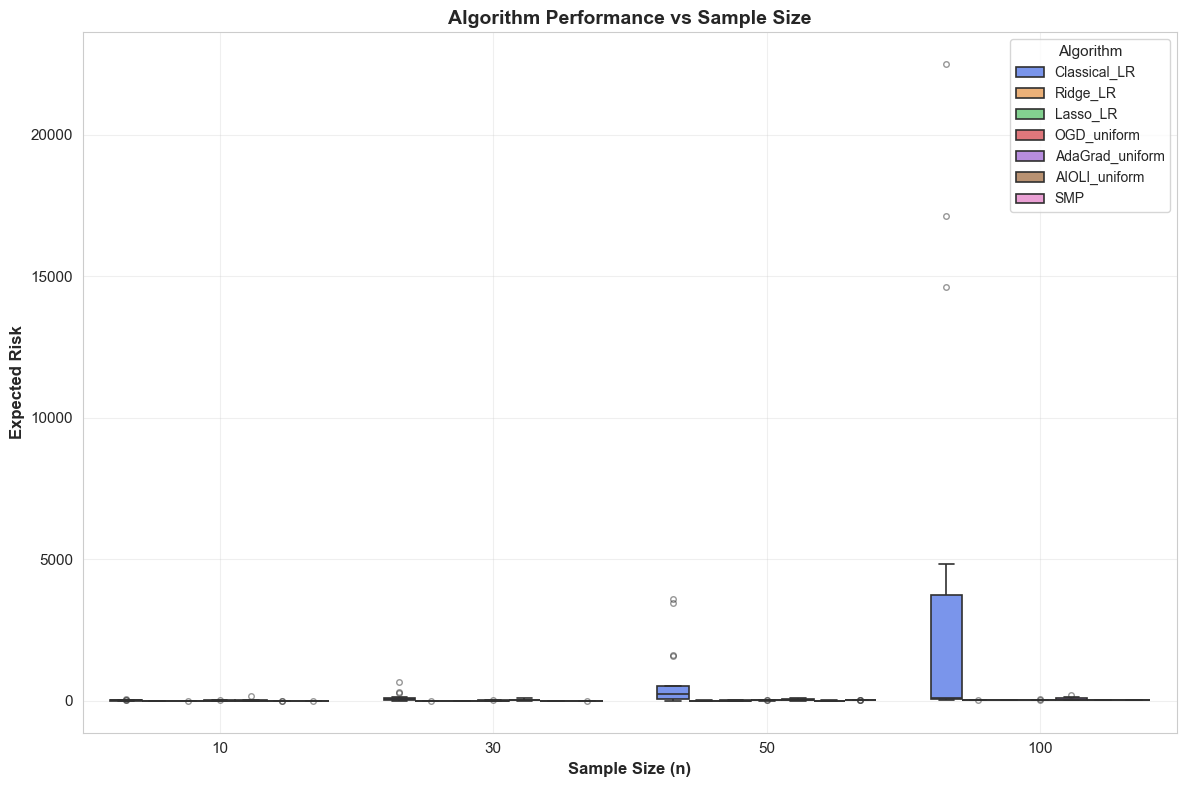

In [342]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP","Lasso_LR", "Ridge_LR","AdaGrad_uniform","OGD_uniform", "Classical_LR"] ,raw_data= high_dimensional_changing_n[1])

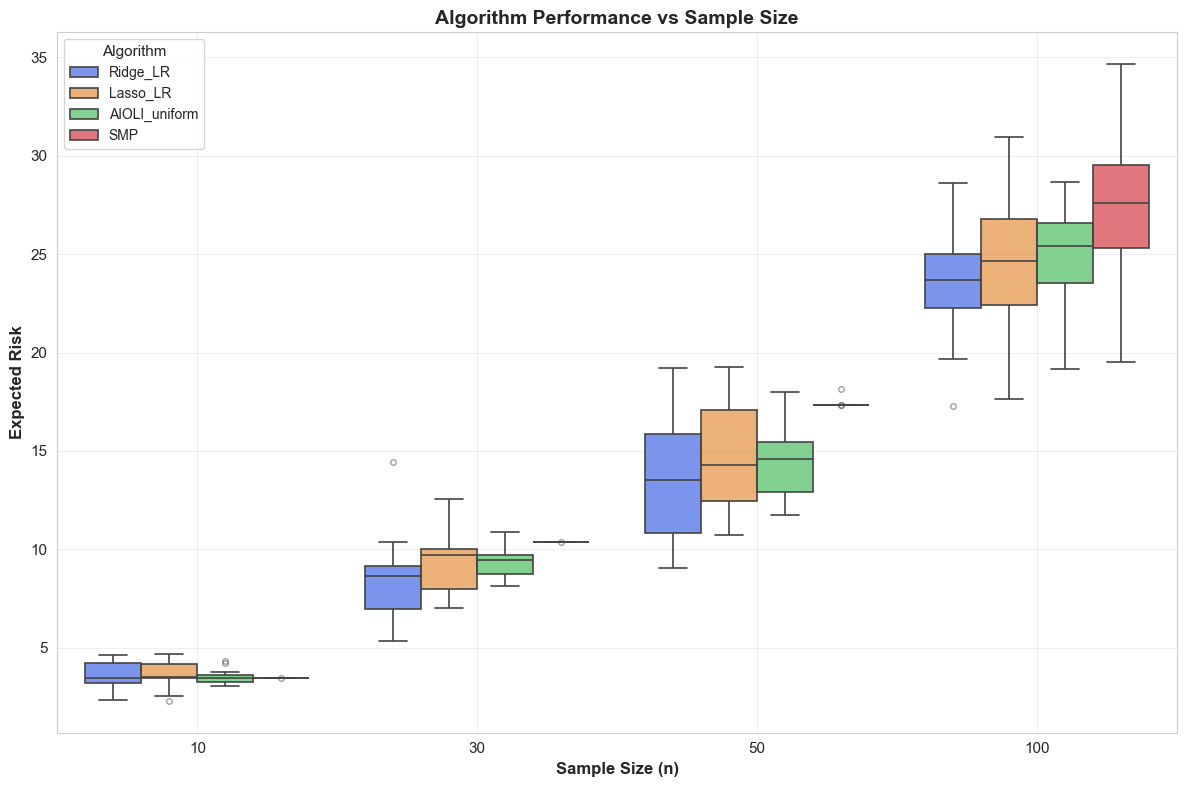

In [339]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP","Lasso_LR", "Ridge_LR"] ,raw_data= high_dimensional_changing_n[1])

In [341]:
high_dimensional_changing_n[1]

,run,algorithm,loss,n
0,1,Classical_LR,8.082003,10
1,1,Classical_LR_SMOTE,5.044143,10
2,1,Ridge_LR,3.219058,10
3,1,Lasso_LR,3.383215,10
4,1,OGD_uniform,6.684806,10
...,...,...,...,...
1195,20,AIOLI_uniform,25.287975,100
1196,20,AIOLI_Suffix,23.100459,100
1197,20,AIOLI_lastit,24.894366,100
1198,20,SMP,29.307800,100


# RUN HERE

In [395]:
high_dimensional_large_n = SimulationConfig(
    sim_setting = "high dimensional",
    n = 20,
    d = 25,
    runs = 10
)

In [396]:
high_dimensional_large_n = simulations_changing_n([150,200], high_dimensional_large_n, filename = "high_dimensional_large_n")

Running simulations for n = 150

150 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.481
Lasso LR was fit manually
Run 1 finished
150 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.489
Lasso LR was fit manually
Run 2 finished
150 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.507
Lasso LR was fit manually
Run 3 finished
150 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.537
Lasso LR was fit manually
Run 4 finished
150 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.546
Lasso LR was fit manually
Run 5 finished
150 (training) samples were generated in the high dimensional balanced setting. Using 25 var

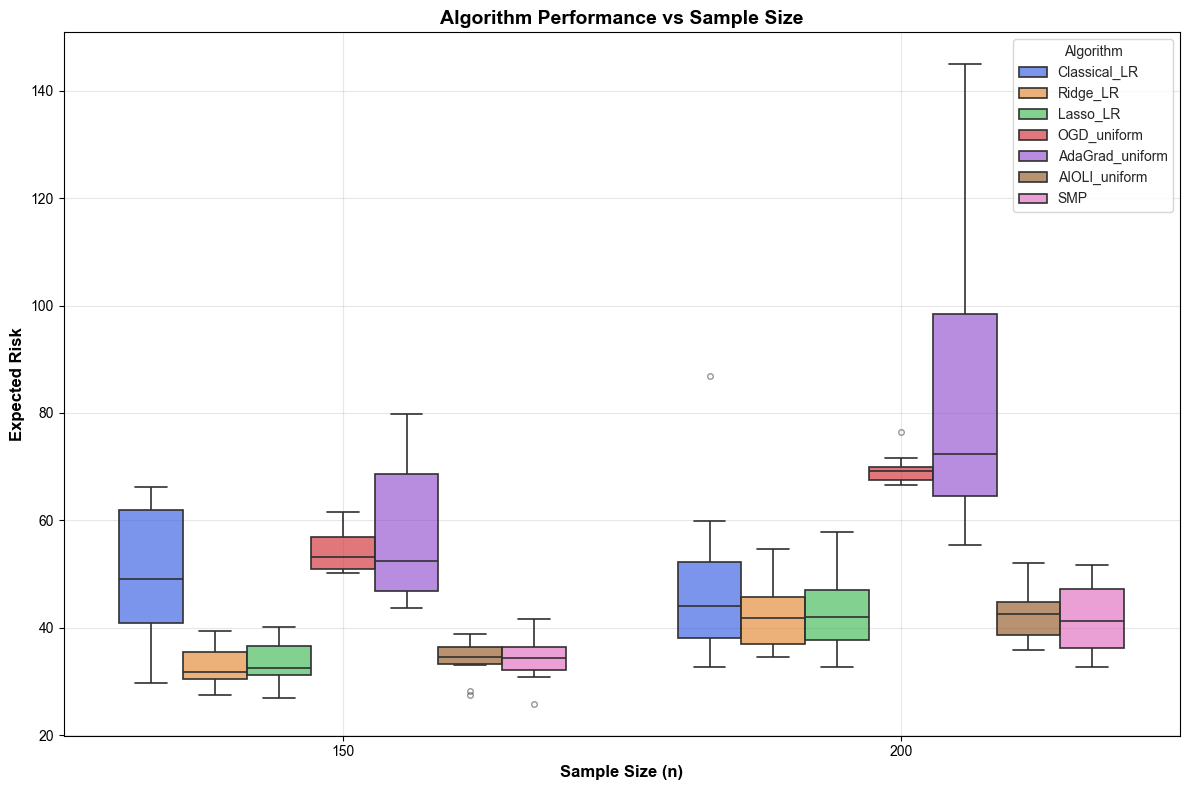

In [399]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP","Lasso_LR", "Ridge_LR","AdaGrad_uniform","OGD_uniform", "Classical_LR"] ,raw_data= high_dimensional_large_n[1])

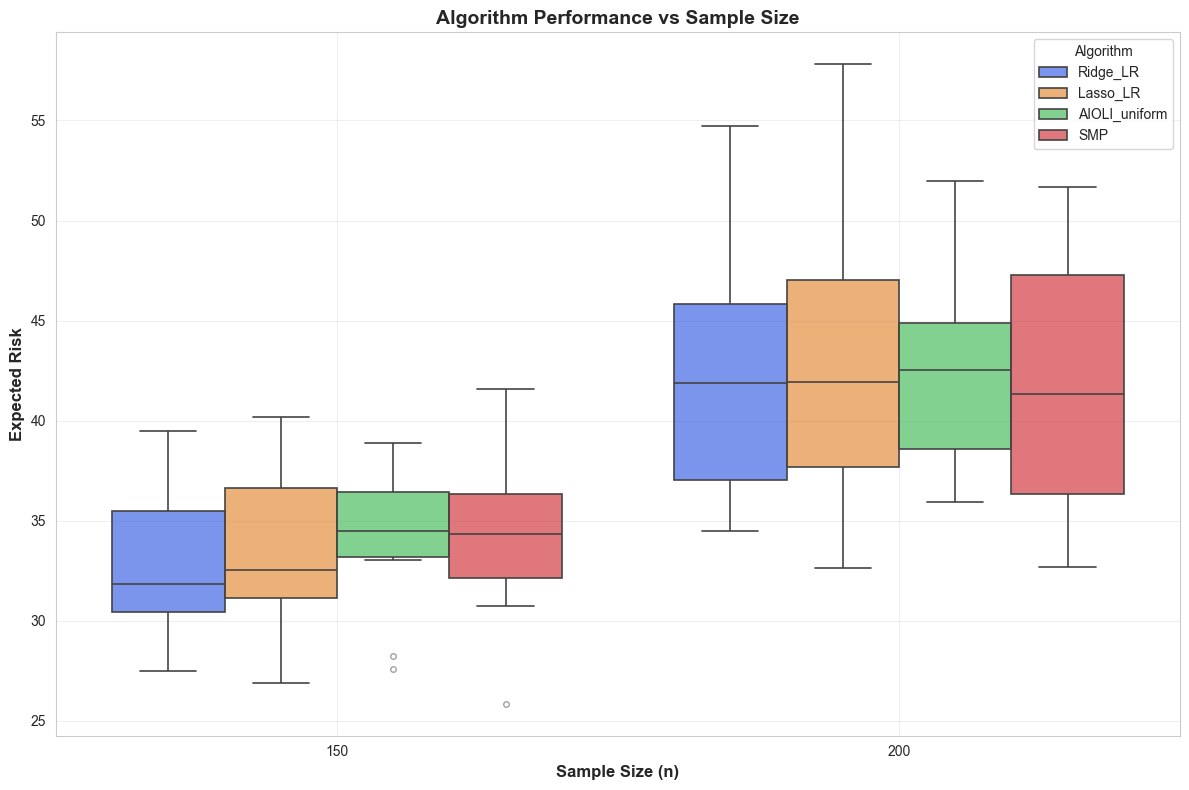

In [398]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP","Lasso_LR", "Ridge_LR"] ,raw_data= high_dimensional_large_n[1])

In [187]:
well_specified_changing_n = simulations_changing_n([10,20,30,50,100], well_specified, filename = "well_specified_changing_n")

Running simulations for n = 10

10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.503
Dataset is balanced
Lasso LR was fit manually
Run 1 finished
10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.498
Dataset is balanced
Lasso LR was fit manually
Run 2 finished
10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.501
Lasso LR was fit manually
Run 3 finished
10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.511
Lasso LR was fit manually
Run 4 finished
10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.51
Lasso LR was fit manually
Run 5 finished
10 (training) samples were generated in the well specified balanced settin

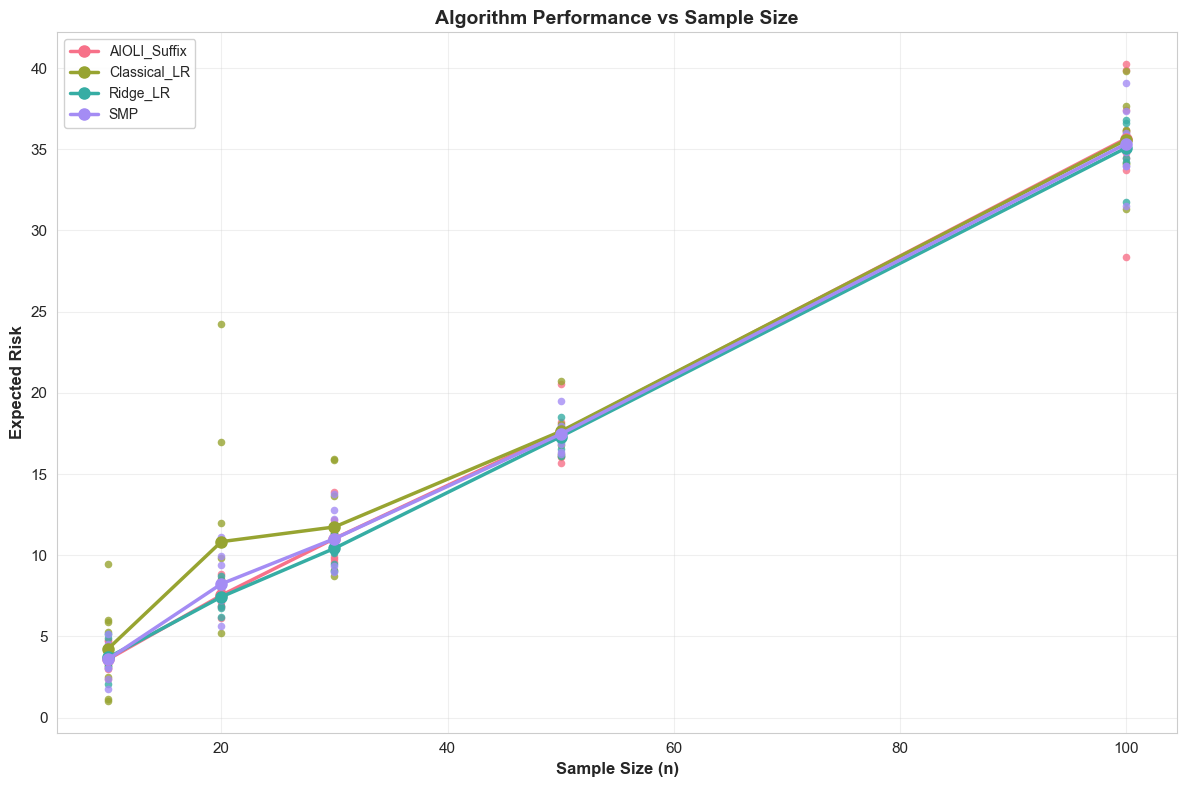

In [188]:
plot_simulation_results(summary_df= well_specified_changing_n[0],algorithms = ["AIOLI_Suffix","Classical_LR", "SMP", "Ridge_LR"] ,raw_data= well_specified_changing_n[1])

# Datasets

In [ ]:
# to push

In [289]:

import kagglehub
import os

# Set cache to current directory
os.environ['KAGGLEHUB_CACHE'] = os.getcwd()

# Download latest version — returns the local path to the dataset folder
path = kagglehub.dataset_download("ashrafkhan94/oil-spill")
print("Dataset downloaded to:", path)
print("Files:", os.listdir(path)[0])  # inspect actual filename(s)
filename = os.listdir(path)[0]

Dataset downloaded to: C:\Users\marie\PycharmProjects\Thesis_Online-to-batch_Logistic-Regression\datasets\ashrafkhan94\oil-spill\versions\1
Files: oil-spill.csv


In [290]:
csv_file = os.path.join(path, filename)  # adjust name based on os.listdir(path) output
df = pd.read_csv(csv_file, header = None)

In [291]:
df = df.drop(df.columns[0],axis=1) # Remove first column because its for analysis based on the image number and its not one of the predictive variables.

In [292]:
df

,1,2,3,4,5,6,7,8,9,10,...,40,41,42,43,44,45,46,47,48,49
0,2558,1506.09,456.63,90,6395000.0,40.88,7.89,29780.0,0.19,214.7,...,2850.00,1000.00,763.16,135.46,3.73,0,33243.19,65.74,7.95,1
1,22325,79.11,841.03,180,55812500.0,51.11,1.21,61900.0,0.02,901.7,...,5750.00,11500.00,9593.48,1648.80,0.60,0,51572.04,65.73,6.26,0
2,115,1449.85,608.43,88,287500.0,40.42,7.34,3340.0,0.18,86.1,...,1400.00,250.00,150.00,45.13,9.33,1,31692.84,65.81,7.84,1
3,1201,1562.53,295.65,66,3002500.0,42.40,7.97,18030.0,0.19,166.5,...,6041.52,761.58,453.21,144.97,13.33,1,37696.21,65.67,8.07,1
4,312,950.27,440.86,37,780000.0,41.43,7.03,3350.0,0.17,232.8,...,1320.04,710.63,512.54,109.16,2.58,0,29038.17,65.66,7.35,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
932,12,92.42,364.42,135,97200.0,59.42,10.34,884.0,0.17,110.0,...,381.84,254.56,84.85,146.97,4.50,0,2593.50,65.85,6.39,0
933,11,98.82,248.64,159,89100.0,59.64,10.18,831.0,0.17,107.2,...,284.60,180.00,150.00,51.96,1.90,0,4361.25,65.70,6.53,0
934,14,25.14,428.86,24,113400.0,60.14,17.94,847.0,0.30,133.9,...,402.49,180.00,180.00,0.00,2.24,0,2153.05,65.91,6.12,0
935,10,96.00,451.30,68,81000.0,59.90,15.01,831.0,0.25,97.5,...,402.49,180.00,90.00,73.48,4.47,0,2421.43,65.97,6.32,0


In [293]:
trialdata = generate_data("well specified")

500 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.499


In [294]:
oil_x = df[df.columns[:-1]]

In [295]:
oil_y = df[df.columns[-1]]
oil_y.replace(0, -1, inplace=True)
oil_y

0      1
1     -1
2      1
3      1
4     -1
      ..
932   -1
933   -1
934   -1
935   -1
936   -1
Name: 49, Length: 937, dtype: int64

In [296]:
test_size = round(default_test_ratio*df.shape[0])
oil_x_train = oil_x[test_size:]
oil_y_train = oil_y[test_size:]
oil_x_test = oil_x[:test_size]
oil_y_test = oil_y[:test_size]

In [297]:
def evaluate_on_data(data_x,data_y):

    # Separate test and train
    test_size = round(default_test_ratio*data_x.shape[0])
    x_train = np.array(data_x[test_size:])
    y_train = np.array(data_y[test_size:])
    x_test = np.array(data_x[:test_size])
    y_test = np.array(data_y[:test_size])

    d = data_x.shape[1]

    # Run algorithms
    ## Get SMOTE dataset for unbalanced cases
    sm = SMOTE(data_x = x_train, data_y = y_train, S = 100)
    smote_x, smote_y = sm.apply_smote()

    ogd = online_gd(data_y=y_train, data_x=x_train, B=default_B)
    adagrad = online_AdaGrad(data_y=y_train, data_x=x_train, B_vector = np.repeat(5,d))
    aioli_model = AIOLI()
    ai = aioli_model.fit(data_y=y_train, data_x=x_train, X=default_X, B=default_B/13)
    classic_LR = classic_logistic_regression(data_x=x_train, data_y=y_train)
    ridge_LR = ridge_logistic_regression(data_x=x_train, data_y=y_train)
    lasso_LR = lasso_logistic_regression(data_x=x_train, data_y=y_train)
    smp = sample_minmax_predictor(x_train, y_train)
    ridge_smp = ridge_sample_minmax_predictor(x_train, y_train)
    classic_LR_smote = classic_logistic_regression(data_x=smote_x, data_y=smote_y)

    # OTB estimates
    # OGD
    OGD_OTB_uniform = calculate_OTB(ogd["All_Betas"], "uniform")
    OGD_OTB_Suffix  = calculate_OTB(ogd["All_Betas"], "suffix_averaging")
    OGD_OTB_lastit  = calculate_OTB(ogd["All_Betas"], "last_iterate")
    # AdaGrad
    adagrad_OTB_uniform = calculate_OTB(adagrad["All_Betas"], "uniform")
    adagrad_OTB_Suffix  = calculate_OTB(adagrad["All_Betas"], "suffix_averaging")
    adagrad_OTB_lastit  = calculate_OTB(adagrad["All_Betas"], "last_iterate")

    ############################## TEST RESULTS ##############################
    # OGD
    loss_OGD_uniform_test = log_loss(OGD_OTB_uniform, x_test, y_test)
    loss_OGD_Suffix_test  = log_loss(OGD_OTB_Suffix,  x_test, y_test)
    loss_OGD_lastit_test  = log_loss(OGD_OTB_lastit,  x_test, y_test)

    # Adagrad
    loss_adagrad_uniform_test = log_loss(adagrad_OTB_uniform, x_test, y_test)
    loss_adagrad_Suffix_test  = log_loss(adagrad_OTB_Suffix,  x_test, y_test)
    loss_adagrad_lastit_test  = log_loss(adagrad_OTB_lastit,  x_test, y_test)

    # AIOLI
    loss_AIOLI_uniform_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]
    loss_AIOLI_Suffix_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="suffix_averaging")["loss"]
    loss_AIOLI_lastit_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="last_iterate")["loss"]

    # Logistic Regression
    loss_LR_test = log_loss(classic_LR["Batch_estimate"], x_test, y_test)
    loss_LR_smote_test = log_loss(classic_LR_smote["Batch_estimate"], x_test, y_test)
    loss_LR_Ridge_test = log_loss(ridge_LR["Batch_estimate"],   x_test, y_test)
    loss_LR_Lasso_test = log_loss(lasso_LR["Batch_estimate"],   x_test, y_test)

    # SMP
    smp_result = smp.get_new_loss(x_test, y_test)
    ridge_smp_result = ridge_smp.get_new_loss(x_test, y_test)

    algorithms_test = {
        "Classical_LR":  {"loss": loss_LR_test},
        "Classical_LR_SMOTE":      {"loss": loss_LR_smote_test},
        "Ridge_LR":      {"loss": loss_LR_Ridge_test},
        "Lasso_LR":      {"loss": loss_LR_Lasso_test},
        "OGD_uniform": {"loss": loss_OGD_uniform_test},
        "OGD_Suffix":  {"loss": loss_OGD_Suffix_test},
        "OGD_Last_iterate": {"loss": loss_OGD_lastit_test},
        "AdaGrad_uniform": {"loss": loss_adagrad_uniform_test},
        "AdaGrad_Suffix":  {"loss": loss_adagrad_Suffix_test},
        "AdaGrad_Last_iterate": {"loss": loss_adagrad_lastit_test},
        "AIOLI_uniform": {"loss": loss_AIOLI_uniform_test},
        "AIOLI_Suffix":  {"loss": loss_AIOLI_Suffix_test},
        "AIOLI_lastit":  {"loss": loss_AIOLI_lastit_test},
        "SMP":      {"loss": smp_result["loss"]},
        "Ridge_SMP":      {"loss": ridge_smp_result["loss"]}
    }

    test_set_results = []
    for name, metrics in algorithms_test.items():
         test_set_results.append({
            "algorithm": name,
            **metrics
        })

    return {
            "test_results": pd.DataFrame(test_set_results)
        }


In [298]:
type(np.array(oil_x))

numpy.ndarray

In [299]:
# evaluate_on_data(oil_x,oil_y)

# Ignore from here on, it's simply code to test some functions/debugging

## AIOLI averaging outside sigmoid

In [ ]:
# class AIOLI:
#     def __init__(self):
#         self.first_sum  = []
#         self.etas_gradients = []
#         self.x0 = [] # Initializer for minimizing algorithm
#         self.reg_lambda = 0
#         self.train_size = 0
#         self.d = 0
#         self.n = 0
#
#     # Define function to minimize for AIOLI
#     @staticmethod # Because I dont use the self
#     def parameter_function_AIOLI(b, xt, reg_lambda, first_sum, etas_gradients):
#         l_hat = np.inner(b,first_sum) + b @ etas_gradients @ b #  @ to do matrix-vector multiplication
#         # Use function np.logaddexp = log(exp(x1) + exp(x2)) to ensure numerical stability, not sure how it works
#         result = l_hat + np.logaddexp(0,np.inner(b,xt)) + np.logaddexp(0,np.inner(-b,xt)) + reg_lambda*np.linalg.norm(b)**2
#         return result
#
#     def new_point_loss(self,X,Y, OTB_method):
#         convergence_new = 0
#         beta_hat = np.zeros((self.train_size,self.d))
#         first_sum  = np.zeros(self.d)
#         etas_gradients = np.zeros((self.d,self.d))
#         for t in range(self.train_size):
#             # Minimize using data up until t-1
#             result = minimize(self.parameter_function_AIOLI, self.x0, method = "l-bfgs-b", args=(X, self.reg_lambda,first_sum, etas_gradients))
#             beta_hat[t] = result.x
#             convergence_new += result.success
#             # Update minimization elements for next round
#             first_sum += self.first_sum[t]
#             etas_gradients += self.etas_gradients[t]
#
#         # Get OTB
#         big_beta = calculate_OTB(beta_hat, OTB_method)
#
#         # Suffer loss
#         loss_point = (1/self.n)*np.sum(np.logaddexp(0,-Y*np.inner(X,beta_hat)))
#
#         return loss_point
#
#     def new_data_loss(self,new_data_x,new_data_y, OTB_method: Literal["suffix_averaging", "uniform", "last_iterate"] | None = None):
#         start_time = datetime.datetime.now()
#         new_losses = [ self.new_point_loss(X,Y, OTB_method) for (X,Y) in zip(new_data_x,new_data_y) ] # Zip pairs the rows of x and y
#         end_time = datetime.datetime.now()
#         return{
#                 "runtime" : (end_time - start_time).total_seconds(),
#                 "loss" : sum(new_losses)
#             }
#
#
#     def fit(self, data_y, data_x, B, X, OTB_method = None, OTB_average_proportion = None, minimize_method = "l-bfgs-b", dynamic_B = False):
#         """AIOLI
#         This is the function to run AIOLI.
#
#         Parameters
#         ---------
#         data_y : ndarray
#             Vector with outcome(y) values. Dimensions: n x 1
#         data_x: ndarray
#             Array with independent variables. Dimensions: n x d
#         B: float
#             Radius of the L2 ball constraint for the parameter vector beta
#         X: float
#             Radius of the L2 ball constraint for the feature vector x"""
#         # Record start time
#         start_time = datetime.datetime.now()
#
#         # Get data dimensions
#         self.n = data_x.shape[0]
#         n = self.n
#         self.d = data_x.shape[1]
#         d = self.d
#         self.x0 = np.zeros(d) # Initializer for minimizing algorithm
#         self.train_size = n
#         # Initialize vectors for storage
#         betas = np.zeros((n, d))
#         ys = np.zeros(n)
#         y_hats = np.zeros(n)
#         loss = np.zeros(n)
#         etas = np.zeros(n)
#         gradients = np.zeros((n, d))
#         self.reg_lambda = 1 / (B**2)
#
#         # Keep sums for loss functions
#         self.first_sum  = np.zeros((n, d))
#         self.etas_gradients = np.zeros((n,d,d))
#         first_sum  = np.zeros(d)
#         etas_gradients = np.zeros((d,d))
#
#         # Track convergence
#         convergence = 0
#         minimizer_gradient = 0
#
#         # Run Algorithm
#         for t in range(n):
#             # Get context vector
#             xt = data_x[t]
#
#             # Update beta parameter
#             # noinspection PyTypeChecker # This is to avoid the underlining which
#             if t == 0: # Initialize to 0 for first round
#                 betas[t] = np.zeros(d)
#             else:
#                 result = minimize(self.parameter_function_AIOLI,
#                                   np.zeros(d),
#                                   method = minimize_method,
#                                   args=(xt, self.reg_lambda,first_sum, etas_gradients),
#                                   options = {"maxiter":100000}
#                                   )
#                 betas[t] = result.x
#                 convergence += result.success
#                 minimizer_gradient += np.linalg.norm(result.jac)
#
#             # # Project beta onto set
#             # betas[t] = project_onto_l2_ball(beta_tilde,B)
#             # betas[t] = self.x0
#
#             # Generate prediction
#             y_hats[t] = np.inner(xt,betas[t])
#
#             # Observe true y from data
#             ys[t] = data_y[t]
#
#              # Compute gradient
#             gradients[t] = -ys[t]*xt*sig(-ys[t]*np.inner(xt,betas[t]))
#
#             # Estimate eta
#             etas[t] = np.exp(ys[t]*y_hats[t])/(1+B*X)
#
#             # Suffer loss
#             loss[t] = np.logaddexp(0,-ys[t]*np.inner(xt,betas[t]))
#
#             # Compute elements for AIOLI loss function
#
#             fs = gradients[t]*(1 - etas[t]*np.inner(betas[t],gradients[t]))
#             eg = (etas[t] / 2) * np.outer(gradients[t], gradients[t])
#             self.first_sum[t] = fs
#             self.etas_gradients[t] = eg
#             first_sum += fs
#             etas_gradients += eg
#             # Here this is separated and a bit reiterative because else the way the vector is stored messes up with the function. I tried multiple ways and this seemed the best one.
#
#             # Dynamic Hyperparameter tuning
#             if dynamic_B:
#                 B = max(B, np.linalg.norm(betas[t]))
#
#         # for loop ends
#
#         # Get Batch estimate
#         betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)
#
#         # Get Batch estimate loss
#         loss_OTB = log_loss(betas_OTB,data_x, data_y)
#
#         end_time = datetime.datetime.now()
#
#         return{
#             "runtime" : (end_time - start_time).total_seconds(),
#             "Total_Loss" : loss_OTB,
#             "Online_Loss" : sum(loss),
#             "Batch_estimate": betas_OTB,
#             "All_Betas": betas,
#             "convergence" : convergence,
#             "minimizer_gradient" : minimizer_gradient
#         }
#


## Tests

In [300]:
#etas = np.array([1/np.sqrt(3),1/np.sqrt(3),1/np.sqrt(3)])
#xt = np.array([1,2,3])
#betas = np.array([[2,2,5],[1,1,3],[4,5,6]])
#reg_lambda = 0.3
#gradients = np.array([[2,2,5],[1,1,3],[4,5,6]])
#b = np.array([1,2,3])
#sum_loss = 5


#(sum(etas)/2)*np.inner((b-betas[2]),gradients[2])*np.inner(gradients[2],(b-betas[2]))
#np.linalg.norm(etas)


In [301]:
#diff = b - betas
#inner_prod = np.sum(gradients * diff,axis = 1)
#np.sum(np.sum(etas)/2 * inner_prod**2)

In [302]:
# x0 = np.array([0,0,0])

#res = minimize(parameter_function_AIOLI, x0, method = "L-BFGS-B", args=(xt, reg_lambda, sum_loss,first_sum, etas_gradients))
#parameter_function_AIOLI(x0, xt, betas, etas, reg_lambda, sum_loss,gradients)
#res.x

In [303]:
# diff = b - betas
# gs_bs = np.sum(gradients * diff,axis = 1)
# quadratic = np.sum(np.sum(etas)/2 * gs_bs**2)
#
# l_hat = sum_loss + np.sum(gs_bs) + quadratic
#
# l_hat + np.log(1+np.exp(np.inner(b,xt))) + np.log(1+np.exp(np.inner(-b,xt))) + reg_lambda*np.linalg.norm(b)

## Generate data

In [304]:
# n = 1000
#
# mean = [20, 5, 2]
# cov = [[1, 0, 0], [0, 3, 0], [0,0,2]]  # diagonal covariance
# d = np.shape(cov)[1]
# y = np.random.binomial(n=1, p=0.3, size=n)
#
# x1, x2, x3 = np.random.multivariate_normal(mean, cov, size = n).T
# plt.plot(x1, x2, 'x')
# plt.axis('equal')
# plt.show()
#
# plt.plot(x1, x3, 'x')
# plt.axis('equal')
# plt.show()


In [305]:
# x = np.random.multivariate_normal(mean, cov, size = n)
# sns.countplot(x=y)
# plt.show()


In [306]:
# np.log(1000)

## OTB conversion proof tests

In [307]:
# weights = np.array([0.3,0.7])
# values = np.array([2,3])
#
# print(np.sum(values))
# print(np.sum(weights*values))